# Industrial Site Grouping

This notebook groups individual building footprints belonging to the same industrial site and assigns a representative industrial subtype to each parent site. Industrial land-use polygons, building-level classifications, man-made features, and supplementary OSM tags are combined to resolve the function of grouped and standalone industrial buildings.

**Input**
- Final building classifications.
- Cleaned industrial land-use and man-made features.
- Supplementary OSM information relevant to industrial activities.

**Output**
- Industrial parent sites linking multiple building footprints to a common site identifier.
- Resolved industrial subtypes and supporting classification evidence for grouped and standalone industrial sites.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import warnings
import sys
import json
from collections import Counter

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Directory config ──────────────────────────────────────────────────────────
ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR  = os.path.join(ROOT_DIR, 'data')
OUT_DIR   = os.path.join(DATA_DIR, 'final')
PROC_DIR  = os.path.join(DATA_DIR, 'processed')
SCRIPTS   = os.path.join(ROOT_DIR, 'scripts')

if SCRIPTS not in sys.path:
    sys.path.insert(0, SCRIPTS)

# building file needed to validate that all building IDs are present in the final output
UNTAGGED_BUILDING_FILE = os.path.join(PROC_DIR, 'germany_buildings_feature_engineered.parquet')
LANDUSE_FILE = os.path.join(PROC_DIR, 'germany_landuse_mapped.parquet')
MANMADE_FILE = os.path.join(PROC_DIR, 'germany_manmade_mapped.parquet')

CLASSIFIED_BUILDING_FILE = os.path.join(OUT_DIR, 'germany_buildings_classified_semi_comm.parquet')

print(f"Untagged building file : {UNTAGGED_BUILDING_FILE}")
print(f"Classified building file   : {CLASSIFIED_BUILDING_FILE}")

Untagged building file : /fast/home/o-olajuyigbe/osm_project/data/processed/germany_buildings_feature_engineered.parquet
Classified building file   : /fast/home/o-olajuyigbe/osm_project/data/final/germany_buildings_classified_semi_comm.parquet


In [2]:
import importlib
import ind_grouping_map

importlib.reload(ind_grouping_map)

from ind_grouping_map import IND_MAP


Counter({'food_processing': 37, 'engineering': 33, 'water_utilities': 25, 'grid_infrastructure': 22, 'construction_materials': 22, 'chemical_industry': 17, 'logistics': 17, 'wood_processing': 14, 'light_manufacturing': 13, 'mining_quarry': 11, 'waste_management': 11, 'energy_generation': 10, 'metal_industry': 10, 'pharmaceutical_industry': 9, 'manufacturing': 8, 'petroleum_industry': 8, 'hightech_manufacturing': 8, 'storage': 6, 'biogas': 4, 'warehouse': 4, 'heating_supply': 3, 'cold_storage': 2, 'silo': 2})
Counter({'food_processing': 37, 'engineering': 33, 'water_utilities': 25, 'grid_infrastructure': 22, 'construction_materials': 22, 'chemical_industry': 17, 'logistics': 17, 'wood_processing': 14, 'light_manufacturing': 13, 'mining_quarry': 11, 'waste_management': 11, 'energy_generation': 10, 'metal_industry': 10, 'pharmaceutical_industry': 9, 'manufacturing': 8, 'petroleum_industry': 8, 'hightech_manufacturing': 8, 'storage': 6, 'biogas': 4, 'warehouse': 4, 'heating_supply': 3, 'co

In [3]:
gdf_untagged = gpd.read_parquet(
     UNTAGGED_BUILDING_FILE,
     columns=['id', 'geometry', 'raw_label', 'landuse_l1', 'landuse_l2', 'landuse_osm_id', 'landuse_used', 'area', 'is_abandoned',]   
 )

gdf_classified = pd.read_parquet(CLASSIFIED_BUILDING_FILE)

gdf_bldg = gdf_classified.merge(gdf_untagged.set_index('id'), left_index=True, right_index=True, how='left')
gdf_bldg = gpd.GeoDataFrame(gdf_bldg, geometry='geometry', crs=gdf_untagged.crs
)

### Manmade Analysis

In [4]:
# ── man_made site polygons (separate from landuse zones) ───────────────────
# These are hand-drawn polygons like man_made=works that often sit ON TOP of
# or straddle individual buildings, rather than being the landuse zone itself.

gdf_manmade = gpd.read_parquet(MANMADE_FILE)


gdf_manmade_ind = gdf_manmade.rename(columns={'id': 'manmade_osm_id', 'geometry': 'manmade_geometry'})

print(f"man_made polygons with a resolved category: {len(gdf_manmade_ind):,}")
print(gdf_manmade_ind['manmade_category'].value_counts())

man_made polygons with a resolved category: 152,830
manmade_category
water_utilities           68116
silo                      67696
manufacturing             14816
grid_infrastructure        1176
mining_quarry               290
hightech_manufacturing      192
chemical                    129
storage                      96
biogas                       75
petroleum                    74
waste_management             70
logistics                    53
construction_materials       15
engineering                  11
wood_processing               7
energy_generation             7
heating_supply                5
warehouse                     2
Name: count, dtype: int64


In [5]:
# ── attach man_made tag to each building via spatial join ──────────────────
if 'id' not in gdf_bldg.columns:
    gdf_bldg = gdf_bldg.reset_index().rename(columns={'index': 'id'})
                                             
# Use centroids, not full building polygons: a building that only partially
# overlaps a man_made polygon's edge shouldn't be ambiguously split between
# "inside" and "outside" -- the centroid gives a clean single answer.
bldg_centroids = gdf_bldg[['id', 'geometry']].copy()
bldg_centroids['geometry'] = bldg_centroids.geometry.centroid

manmade_join = gpd.sjoin(
    bldg_centroids.set_geometry('geometry'),
    gdf_manmade_ind.set_geometry('manmade_geometry').to_crs(bldg_centroids.crs),
    how='left',
    predicate='within'
)

# a centroid could in theory fall inside more than one man_made polygon
# (overlapping/nested tagging) -- keep only the first match per building
manmade_join = manmade_join.drop_duplicates(subset='id', keep='first')

manmade_lookup = manmade_join.set_index('id')[['manmade_osm_id', 'man_made', 'manmade_category']]
gdf_bldg = gdf_bldg.merge(manmade_lookup, left_on='id', right_index=True, how='left')

print(f"Buildings matched to a man_made polygon: {gdf_bldg['manmade_category'].notna().sum():,}")
print(gdf_bldg['manmade_category'].value_counts())

Buildings matched to a man_made polygon: 139,978
manmade_category
manufacturing             59784
water_utilities           59637
silo                      18933
grid_infrastructure         895
hightech_manufacturing      190
logistics                   116
waste_management            113
storage                      83
mining_quarry                83
engineering                  61
energy_generation            30
biogas                       19
wood_processing              15
petroleum                    10
heating_supply                5
warehouse                     4
Name: count, dtype: int64


In [6]:
gdf_bldg['manmade_osm_id'] = gdf_bldg['manmade_osm_id'].astype('Int64')  # capital I = nullable

In [7]:
gdf_bldg[gdf_bldg['manmade_category']=='manufacturing'].sample(5)

,id,final_l1,final_l2,l1_confidence,l2_confidence,label_source,geometry,raw_label,landuse_l1,landuse_l2,landuse_osm_id,landuse_used,area,is_abandoned,manmade_osm_id,man_made,manmade_category
22629676,192238353,industrial,storage,NaN,0.977014,ml_predicted_subtype,"POLYGON ((11.01081 51.02207, 11.01163 51.02223...",industrial,industrial,None,191247844.0,industrial,734.486771,False,191247844,works,manufacturing
22704712,490506932,industrial,storage,NaN,0.582678,ml_predicted_subtype,"POLYGON ((12.76828 49.29775, 12.7686 49.29765,...",industrial,industrial,None,490506927.0,industrial,384.350681,False,490506927,works,manufacturing
1910166,131746201,industrial,utilities,0.996703,0.881064,ml_predicted,"POLYGON ((8.32929 49.05766, 8.32921 49.05758, ...",None,None,None,NaN,None,51.747304,False,162004514,works,manufacturing
22674600,316560760,industrial,storage,NaN,0.923522,ml_predicted_subtype,"POLYGON ((12.61741 48.67231, 12.61787 48.6715,...",industrial,commercial,None,264453864.0,commercial,29169.456213,False,916705053,works,manufacturing
22635328,204037390,industrial,storage,NaN,0.506401,ml_predicted_subtype,"POLYGON ((9.2725 49.70594, 9.27261 49.70549, 9...",industrial,industrial,None,746180728.0,industrial,1375.313472,False,746180728,works,manufacturing


In [8]:
gdf_landuse = gpd.read_parquet(LANDUSE_FILE)

gdf_landuse_ind = gdf_landuse[['id', 'geometry']].rename(
    columns={'id': 'landuse_osm_id', 'geometry': 'landuse_geometry'}
)
gdf_landuse_ind['landuse_osm_id'] = gdf_landuse_ind['landuse_osm_id'].astype(gdf_bldg['landuse_osm_id'].dtype)

ind_landuse = gdf_landuse[gdf_landuse['zone_l1']=='industrial']

In [9]:
def parse_tags(t):
    if pd.isna(t) or t is None:
        return {}
    try:
        return json.loads(t)
    except (json.JSONDecodeError, TypeError):
        return {}
        

In [10]:
ind_landuse = ind_landuse.copy()
ind_landuse['tags_parsed'] = ind_landuse['tags'].apply(parse_tags)

key_counts = Counter()
for d in ind_landuse['tags_parsed']:
    key_counts.update(d.keys())


key_counts_df = pd.DataFrame(key_counts.most_common(), columns=['key', 'count'])

key_counts_df['pct_ind_rows'] = (key_counts_df['count'] / len(ind_landuse) * 100).round(2)
print(key_counts_df.head(60))

                             key  count  pct_ind_rows
0                        visible  65670        100.00
1                           name  21999         33.50
2                       operator   6200          9.44
3                    addr:street   4464          6.80
4                      addr:city   4335          6.60
5                  addr:postcode   4306          6.56
6               addr:housenumber   4264          6.49
7                        barrier   4095          6.24
8                       man_made   3621          5.51
9                        website   3297          5.02
10                         power   2921          4.45
11                  addr:country   2560          3.90
12                        source   2493          3.80
13                  plant:source   2178          3.32
14                      resource   1754          2.67
15                  plant:method   1752          2.67
16      plant:output:electricity   1718          2.62
17                         p

In [11]:
for key in ['man_made', 'product', 'utility', 'power', 'pipeline', 'resource', 'industrial']: 
    if key in key_counts_df['key'].values:
        vals = ind_landuse['tags_parsed'].apply(lambda d: d.get(key)).dropna()
        print(f"\n--- {key} ({len(vals)} non-null) ---")
        print(vals.value_counts().head(50))


--- man_made (3621 non-null) ---
tags_parsed
wastewater_plant          1574
works                     1204
water_works                289
pumping_station            111
gas_cavern                  82
water_well                  60
reservoir_covered           41
petroleum_well              35
composting_plant            34
container_terminal          31
gas_well                    15
embankment                  14
pipeline                    14
pump                        11
pumping_rig                  9
storage_tank                 9
monitoring_station           8
maintenance_yard             6
rig                          6
clearance_cairn              5
waste_processing_plant       5
gasometer                    5
bunker_silo                  4
mineshaft                    3
watermill                    3
surveillance                 3
pusher station               3
distribution_station         3
oil_well                     2
cooling                      2
asphalt_mixing_plant    

In [12]:
USEFUL_IND_TAG_KEYS = ['man_made', 'product', 'utility', 'power', 'pipeline', 'resource']

_parsed = gdf_landuse['tags'].apply(parse_tags)
for key in USEFUL_IND_TAG_KEYS:
    gdf_landuse[f'tag_{key}'] = _parsed.apply(lambda d: d.get(key))

gdf_landuse['num_industrial_subtag'] = (
    gdf_landuse[[f'tag_{k}' for k in USEFUL_IND_TAG_KEYS] + ['industrial']]
    .notna().sum(axis=1)
)

In [13]:
if 'id' not in gdf_bldg.columns:
    gdf_bldg = gdf_bldg.reset_index().rename(columns={'index': 'id'})

In [14]:
# define group membership and parent assignement
gdf_bldg['parent_id'] = pd.Series(pd.NA, index=gdf_bldg.index, dtype='object')

# Mask 1: part of an industrial landuse zone (any final_l1)
in_industrial_zone = (
    (gdf_bldg['landuse_l1'] == 'industrial') &
    gdf_bldg['landuse_osm_id'].notna()
)

# Mask 2: standalone industrial buildings, not part of any landuse zone
standalone_industrial = (
    (gdf_bldg['final_l1'] == 'industrial') &
    (~in_industrial_zone)
)

# Standalone: self-referencing parent and subpolygon id
gdf_bldg.loc[standalone_industrial, 'parent_id'] = gdf_bldg.loc[standalone_industrial, 'id']

print(f"In industrial landuse zones : {in_industrial_zone.sum():,}")
print(f"Standalone industrial       : {standalone_industrial.sum():,}")
print(f"Unique industrial landuse_osm_ids : {gdf_bldg.loc[in_industrial_zone, 'landuse_osm_id'].nunique():,}")

In industrial landuse zones : 660,189
Standalone industrial       : 515,077
Unique industrial landuse_osm_ids : 50,480


In [15]:

print(f"Buildings inside an industrial land-use polygon: {in_industrial_zone.sum():,}")
print(f"  of which classified as industrial themselves : {(in_industrial_zone & (gdf_bldg['final_l1']=='industrial')).sum():,}")

Buildings inside an industrial land-use polygon: 660,189
  of which classified as industrial themselves : 450,863


In [16]:
def clean_id_str(series):
    return pd.to_numeric(series, errors='coerce').astype('Int64').astype(str)


In [17]:
gdf_bldg.loc[in_industrial_zone, 'parent_id'] = 'IND_' + clean_id_str(gdf_bldg.loc[in_industrial_zone, 'landuse_osm_id'])


In [18]:
print(f"  non-industrial, no parent: {gdf_bldg['parent_id'].isna().sum():,}")


  non-industrial, no parent: 37,627,106


In [19]:
gdf_bldg['ind_mapped_subtype'] = gdf_bldg['raw_label'].map(IND_MAP)

In [20]:

POWER_MAP = {
    'plant': 'energy_generation',
    'generator': 'energy_generation',
    'substation': 'grid_infrastructure',
    'converter': 'grid_infrastructure',
    'transformer': 'grid_infrastructure',
}

PIPELINE_MAP = {
    'substation': 'grid_infrastructure',
    'valve_group': 'grid_infrastructure',
    'valve': 'grid_infrastructure',
}

UTILITY_MAP = {
    'gas': 'grid_infrastructure',
    'water': 'water_utilities',
    'power': 'grid_infrastructure',
    'oil': 'grid_infrastructure',
    'heating': 'heating_supply',
    'sewerage': 'water_utilities',
}
LANDUSE_OVERRIDE = {
    'quarry': 'mining_quarry',
    'storage': 'storage',
    'storage_depot': 'storage',
    'warehouse': 'warehouse',
    'water_storage': 'water_utilities',
}

POWER_MAP = {k.lower(): v for k, v in POWER_MAP.items()}

PIPELINE_MAP = {k.lower(): v for k, v in PIPELINE_MAP.items()}

UTILITY_MAP = {k.lower(): v for k, v in UTILITY_MAP.items()}

PIPELINE_MAP = {k.lower(): v for k, v in PIPELINE_MAP.items()}

IND_MAP = {k.lower(): v for k, v in IND_MAP.items()}


CORE_SUBTYPE_PRIORITY = [
     'metal_industry', 'petroleum_industry', 'chemical_industry', 'food_processing',
     'pharmaceutical_industry', 'wood_processing', 'construction_materials','engineering',
    'mining_quarry', 'hightech_manufacturing', 'logistics',
    'light_manufacturing', 'manufacturing', 
]

SUPPORT_SUBTYPE_PRIORITY =[
      'energy_generation','grid_infrastructure', 'waste_management', 'heating_supply',
     'water_utilities', 'cold_storage', 'warehouse', 'silo', 'storage', 'utilities',
    ]

CORE_SUBTYPES = set(CORE_SUBTYPE_PRIORITY)
SUPPORT_SUBTYPES = set(SUPPORT_SUBTYPE_PRIORITY)

def priority_rank(subtype):
    """Lower = higher priority. Core ranks always beat support ranks."""
    if subtype in CORE_SUBTYPE_PRIORITY:
        return (0, CORE_SUBTYPE_PRIORITY.index(subtype))
    if subtype in SUPPORT_SUBTYPE_PRIORITY:
        return (1, SUPPORT_SUBTYPE_PRIORITY.index(subtype))
    return (2, 0)  # unknown subtype, lowest priority


In [21]:
ZONE_TAG_KEY_PRECEDENCE = ['resource', 'power', 'pipeline', 'product', 'industrial', 'man_made', 'utility']

ZONE_TAG_MAPS = {
    'resource': None,  # special-cased: any non-null value -> quarry
    'power': POWER_MAP,
    'pipeline': PIPELINE_MAP,
    'product': IND_MAP,
    'industrial': IND_MAP,
    'man_made': IND_MAP,
    'utility': UTILITY_MAP,
}

def resolve_zone_tags(zone_tags, verbose=False):
    """
    Tier 1: resolve subtype from zone-level OSM tags.
    Conflict resolution = key precedence order (only one landuse zone, so
    'conflicts' just means multiple keys present with mappable values).
    Returns (subtype, source_key) or (None, None).
    """
    if verbose:
        print("  --- TIER 1: zone tags ---")

    candidates = []
    for key in ZONE_TAG_KEY_PRECEDENCE:
        raw_val = zone_tags.get(key)
        if raw_val is None:
            continue
        raw_val = raw_val.lower()

        if key == 'resource':
            subtype = 'mining_quarry'
        else:
            subtype = ZONE_TAG_MAPS[key].get(raw_val)

        if subtype is not None:
            candidates.append((key, raw_val, subtype))

    if verbose:
        if candidates:
            print(f"  Tags with mappable values (in precedence order checked): {ZONE_TAG_KEY_PRECEDENCE}")
            for key, raw_val, subtype in candidates:
                print(f"    key='{key}' raw_value='{raw_val}' -> subtype='{subtype}'")
        else:
            print("  No zone tags mapped to a subtype.")

    if not candidates:
        return None, None, None

    chosen_key, chosen_raw, chosen_subtype = candidates[0]  # first in precedence order wins
    if verbose:
        print(f"  -> TIER 1 RESULT: '{chosen_subtype}' (from key='{chosen_key}', value='{chosen_raw}')")
    return chosen_subtype, chosen_key, chosen_raw


def resolve_landuse_used(landuse_used_val, verbose=False):
    if verbose:
        print("  --- TIER 2: landuse_used ---")
    if landuse_used_val is None:
        if verbose:
            print("  landuse_used is null. No result.")
        return None, None
    subtype = LANDUSE_OVERRIDE.get(landuse_used_val)
    if verbose:
        if subtype:
            print(f"  (from key='landuse_used', value='{landuse_used_val}') -> subtype='{subtype}'")
            print(f"  -> TIER 2 RESULT: '{subtype}' (from key='landuse_used', value='{landuse_used_val}')")
        else:
            print(f"  landuse_used='{landuse_used_val}' -> no mapping found")
    return subtype, landuse_used_val if subtype else None

In [22]:
def resolve_building_votes(voters, value_col, total_building_count, verbose=False,
                            tier_label='', bypass_if_weak_support=False,
                            min_core_votes_to_skip_count_check=3):
    """
    Core resolution rule (updated):
      - Among core candidates, the one with the HIGHEST VOTE COUNT wins.
      - Priority order is used ONLY to break ties when two+ core candidates
        have the same (max) vote count.
      - min_core_votes_to_skip_count_check: if the leading core candidate has
        fewer votes than this, and a support candidate has more votes than it,
        flag it clearly in verbose output (still returns the core winner per
        your "core always beats support" rule, but makes the weak signal visible).
    """
    if verbose:
        print(f"  --- {tier_label} ---")

    votes = voters[value_col].dropna()
    source_vals = voters.loc[votes.index, 'raw_label'] if value_col == 'ind_mapped_subtype' else votes

    if len(votes) == 0:
        if verbose:
            print(f"  No non-null '{value_col}' votes among {len(voters)} industrial voters.")
        return None, None

    vc = votes.value_counts()
    vc = vc[vc > 0]

    if verbose:
        print(f"  Votes cast: {len(votes)} (out of {len(voters)} industrial voters, {total_building_count} total buildings)")
        print(f"  Vote breakdown (only categories with votes):")
        for subtype, n in vc.items():
            kind = 'CORE' if subtype in CORE_SUBTYPES else ('SUPPORT' if subtype in SUPPORT_SUBTYPES else 'UNKNOWN')
            # show a sample raw value behind this subtype, for traceability
            if value_col == 'ind_mapped_subtype':
                sample_raw = voters.loc[votes[votes == subtype].index, 'raw_label'].iloc[0]
                print(f"    {subtype:25s} : {n:5d} votes  [{kind}]  (e.g. from raw_label='{sample_raw}')")
            else:
                print(f"    {subtype:25s} : {n:5d} votes  [{kind}]  (from final_l2='{subtype}')")

    core_present = vc[[s for s in vc.index if s in CORE_SUBTYPES]]
    support_present = vc[[s for s in vc.index if s in SUPPORT_SUBTYPES]]
    
    if len(core_present) == 0 and len(support_present) == 0:
        if verbose:
            unknown = vc[[s for s in vc.index if s not in CORE_SUBTYPES and s not in SUPPORT_SUBTYPES]]
            print(f"  Votes cast but none are in CORE_SUBTYPES or SUPPORT_SUBTYPES: {unknown.to_dict()}")
            print(f"  -> {tier_label}: no resolvable votes. Falling through.")
        return None, None
    
    if len(core_present) > 0:
        max_core_count = core_present.max()
        top_core = core_present[core_present == max_core_count].index.tolist()

        if verbose:
            print(f"  Core candidates present: {core_present.to_dict()}")

        if len(top_core) == 1:
            winner = top_core[0]
            if verbose:
                strongest_support = support_present.max() if len(support_present) > 0 else 0
                if max_core_count < min_core_votes_to_skip_count_check and strongest_support > max_core_count:
                    print(f"  NOTE: core winner '{winner}' has only {max_core_count} votes, "
                          f"weaker than top support count ({strongest_support}). "
                          f"Still wins per core-beats-support rule.")
                print(f"  -> {tier_label} RESULT: '{winner}' (core, highest vote count: {max_core_count})")
        else:
            top_core_sorted = sorted(top_core, key=priority_rank)
            winner = top_core_sorted[0]
            if verbose:
                print(f"  Tie among core candidates (each {max_core_count} votes): {top_core}")
                print(f"  Resolved by priority order -> '{winner}'")
                print(f"  -> {tier_label} RESULT: '{winner}' (core, priority tie-break)")

        return winner, 'core'

    # support-only
    turnout_pct = len(votes) / total_building_count * 100 if total_building_count > 0 else 0
    if verbose:
        print(f"  No core votes. Support-only. Turnout: {len(votes)}/{total_building_count} = {turnout_pct:.1f}%")

    if bypass_if_weak_support and turnout_pct < 50:
        if verbose:
            print(f"  Turnout < 50% and support-only -> BYPASSING to next tier.")
        return None, None
    
    if len(support_present) == 0:
        if verbose:
            print(f"  No support candidates either (only unknown categories). Falling through.")
        return None, None

    max_support_count = support_present.max()
    top_support = support_present[support_present == max_support_count].index.tolist()
    if len(top_support) == 1:
        winner = top_support[0]
        if verbose:
            print(f"  -> {tier_label} RESULT: '{winner}' (support, highest vote count: {max_support_count})")
    else:
        top_support_sorted = sorted(top_support, key=priority_rank)
        winner = top_support_sorted[0]
        if verbose:
            print(f"  Tie among support candidates (each {max_support_count} votes): {top_support}")
            print(f"  Resolved by priority order -> '{winner}'")
            print(f"  -> {tier_label} RESULT: '{winner}' (support, priority tie-break)")

    return winner, 'support'

def resolve_no_votes_fallback(group, verbose=False):
    if verbose:
        print("  --- TIER 5: no votes fallback ---")
        print(f"  final_l1 values in group: {group['final_l1'].value_counts().to_dict()}")

    # 1. Determine the predominant final_l1 for the group
    l1_labels = group['final_l1'].dropna()
    l1_winner = l1_labels.mode().iloc[0] if len(l1_labels) > 0 else None

    # 2. If final_l1 is 'filter', use 'low_demand_infrastructure'
    if l1_winner == 'filter':
        if verbose:
            print("  -> TIER 5 RESULT: 'low_demand_infrastructure' (final_l1 is filter)")
        return 'low_demand_infrastructure', 'filter_fallback'

    
    # 3. If not filter, fall back to final_l1
    if l1_winner is not None:
        if verbose:
            print("  No final_l2 available. Using final_l1 fallback.")
            print(f"  -> TIER 5 RESULT: '{l1_winner}' (from final_l1 mode)")
        return l1_winner, 'final_l1_fallback'

    # Absolute safety net (if a group somehow has completely null final_l1 and final_l2)
    if verbose:
        print("  No final_l1 or final_l2 available either.")
        print("  -> TIER 5 RESULT: 'unclassified' (generic fallback)")
    return 'unclassified', 'generic_fallback'

In [23]:
def resolve_group_subtype(group, zone_tags_lookup, verbose=False):
    pid = group['parent_id'].iloc[0]
    landuse_osm_id = group['landuse_osm_id'].iloc[0]
    total_buildings = len(group)

    if verbose:
        print(f"\n{'='*70}\nResolving parent_id: {pid}  ({total_buildings} buildings)")

    # Tier 1: landuse zone's own OSM tags
    zone_tags = zone_tags_lookup.get(str(int(landuse_osm_id)) if pd.notna(landuse_osm_id) else '', {})
    subtype, source_key, source_val = resolve_zone_tags(zone_tags, verbose=verbose)
    if subtype is not None:
        return subtype, f'zone_tag_{source_key}', source_val

    # Tier 2: landuse_used override
    landuse_vals = group['landuse_used'].dropna().unique()
    landuse_used_val = landuse_vals[0] if len(landuse_vals) > 0 else None
    subtype, source_val = resolve_landuse_used(landuse_used_val, verbose=verbose)
    if subtype is not None:
        return subtype, 'landuse_override', source_val

    voters = group[group['final_l1'] == 'industrial']

    # ── Tier 3a: raw_label (building's own OSM tags), CORE-only pass ──────
    # Deliberately don't accept a SUPPORT-only winner yet -- man_made (3b)
    # still gets a chance to supply a CORE answer before we fall back.
    subtype, kind = resolve_building_votes(
        voters, 'ind_mapped_subtype', total_buildings, verbose=verbose,
        tier_label='TIER 3a: raw_label votes', bypass_if_weak_support=True
    )
    if subtype is not None and kind == 'core':
        return subtype, 'ind_map_vote', f'{kind}, n_voters={len(voters)}'

    # stash raw_label's result (SUPPORT winner, or None if bypassed for
    # weak turnout) as a fallback candidate for Tier 3c
    raw_label_result = (subtype, kind)

    # ── Tier 3b: man_made site-polygon votes, CORE-only pass ──────────────
    # bypass_if_weak_support=False: unlike raw_label turnout, a man_made
    # polygon is a deliberate human-drawn boundary, so even a small number
    # of matching buildings is a meaningful signal, not noise. Revisit this
    # if it turns out to over-trigger on sparse/mis-drawn polygons.
    subtype, kind = resolve_building_votes(
        voters, 'manmade_category', total_buildings, verbose=verbose,
        tier_label='TIER 3b: man_made votes', bypass_if_weak_support=False
    )
    if subtype is not None and kind == 'core':
        return subtype, 'manmade_vote', f'{kind}, n_voters={len(voters)}'

    # ── Tier 3c: neither source gave a CORE winner. Accept whichever
    # SUPPORT winner exists, preferring raw_label (direct building tag)
    # over man_made (inherited site-polygon tag). ──
    if raw_label_result[0] is not None:
        r_subtype, r_kind = raw_label_result
        return r_subtype, 'ind_map_vote', f'{r_kind}, n_voters={len(voters)}'
    if subtype is not None:
        return subtype, 'manmade_vote', f'{kind}, n_voters={len(voters)}'

    # Tier 4: ML final_l2 votes -- weakest signal
    subtype, kind = resolve_building_votes(
        voters, 'final_l2', total_buildings, verbose=verbose,
        tier_label='TIER 4: final_l2 votes', bypass_if_weak_support=False
    )
    if subtype is not None:
        return subtype, 'final_l2_vote', f'{kind}, n_voters={len(voters)}'

    # Tier 5
    subtype, source = resolve_no_votes_fallback(group, verbose=verbose)
    return subtype, source, None

In [24]:
def build_zone_tags(row):
    d = parse_tags(row['tags'])

    if pd.notna(row['industrial']):
        d['industrial'] = row['industrial']

    return d

zone_tags_lookup = (
    gdf_landuse
    .assign(tags_parsed=gdf_landuse.apply(build_zone_tags, axis=1))
    .assign(id_key=lambda df: df['id'].astype(str))
    .set_index('id_key')['tags_parsed']
    .to_dict()
)

In [25]:
grouped_mask = gdf_bldg['parent_id'].astype(str).str.startswith('IND_')
grouped = gdf_bldg[grouped_mask]

results = []


In [26]:
test_pids = (
    grouped['parent_id'].value_counts().head(50).index.tolist()  # 3 largest groups
    + grouped['parent_id'].value_counts().tail(5).index.tolist()  # 3 smallest groups
)
for pid in test_pids:
    g = grouped[grouped['parent_id'] == pid]

    subtype, source, source_val= resolve_group_subtype(
        g,
        zone_tags_lookup,
        verbose=True
    )

    print(f"Result: {subtype} ({source})")


Resolving parent_id: IND_157307959  (2357 buildings)
  --- TIER 1: zone tags ---
  Tags with mappable values (in precedence order checked): ['resource', 'power', 'pipeline', 'product', 'industrial', 'man_made', 'utility']
    key='product' raw_value='chemical' -> subtype='chemical_industry'
    key='industrial' raw_value='chemical' -> subtype='chemical_industry'
    key='man_made' raw_value='works' -> subtype='manufacturing'
  -> TIER 1 RESULT: 'chemical_industry' (from key='product', value='chemical')
Result: chemical_industry (zone_tag_product)

Resolving parent_id: IND_147204151  (1291 buildings)
  --- TIER 1: zone tags ---
  No zone tags mapped to a subtype.
  --- TIER 2: landuse_used ---
  landuse_used='industrial' -> no mapping found
  --- TIER 3a: raw_label votes ---
  Votes cast: 4 (out of 630 industrial voters, 1291 total buildings)
  Vote breakdown (only categories with votes):
    warehouse                 :     3 votes  [SUPPORT]  (e.g. from raw_label='warehouse')
    wate

In [27]:
results = []
for parent_id, group in grouped.groupby('parent_id'):
    subtype, source, source_val = resolve_group_subtype(group, zone_tags_lookup, verbose=False)
    results.append({
        'parent_id': parent_id,
        'landuse_osm_id': group['landuse_osm_id'].iloc[0],
        'subtype': subtype,
        'subtype_source': source,
        'subtype_evidence': source_val,
        'n_buildings': len(group),
        'n_industrial_buildings': (group['final_l1'] == 'industrial').sum(),
        'total_area': group['area'].sum(),
    })

parent_subtypes = pd.DataFrame(results)
print(f"Total grouped parents resolved: {len(parent_subtypes):,}")
print(parent_subtypes['subtype_source'].value_counts())

Total grouped parents resolved: 50,480
subtype_source
final_l2_vote          32462
zone_tag_industrial     3108
ind_map_vote            2901
zone_tag_man_made       2399
manmade_vote            2210
final_l1_fallback       2013
zone_tag_power          1873
landuse_override        1215
filter_fallback         1067
zone_tag_pipeline        533
zone_tag_resource        397
zone_tag_product         225
zone_tag_utility          77
Name: count, dtype: int64


In [28]:
# ============================================================
# RESOLVE STANDALONE INDUSTRIAL SUBTYPES
# ============================================================

standalone_gdf = gdf_bldg.loc[standalone_industrial].copy()

building_id_col = "id"  

# Create an explicit standalone parent ID
standalone_gdf["parent_id"] = "BLDG_" + clean_id_str(standalone_gdf[building_id_col])

assert standalone_gdf["parent_id"].notna().all(), "Missing standalone parent IDs"
assert standalone_gdf["parent_id"].is_unique, "Duplicate standalone parent IDs"

gdf_bldg.loc[standalone_gdf.index, "parent_id"] = standalone_gdf["parent_id"]
gdf_bldg["parent_id"] = gdf_bldg["parent_id"].astype("string")

raw = standalone_gdf["ind_mapped_subtype"].astype("object")
manmade = standalone_gdf["manmade_category"].astype("object")

# Use object dtype so new detailed subtype values can be assigned
standalone_gdf["resolved_subtype"] = standalone_gdf["final_l2"].astype("object")
standalone_gdf["resolved_source"] = "standalone_final_l2"
standalone_gdf["resolved_evidence"] = standalone_gdf["final_l2"].astype("object")


# Inherited man_made evidence
mask = manmade.notna()
standalone_gdf.loc[mask, "resolved_subtype"] = manmade.loc[mask]
standalone_gdf.loc[mask, "resolved_source"] = "standalone_manmade"
standalone_gdf.loc[mask, "resolved_evidence"] = standalone_gdf.loc[mask, "man_made"].astype("object")

# Direct building raw-label evidence
mask = raw.notna()
standalone_gdf.loc[mask, "resolved_subtype"] = raw.loc[mask]
standalone_gdf.loc[mask, "resolved_source"] = "standalone_ind_map"
standalone_gdf.loc[mask, "resolved_evidence"] = standalone_gdf.loc[mask, "raw_label"].astype("object")


standalone_parents = pd.DataFrame({
    "parent_id": standalone_gdf["parent_id"],
    "landuse_osm_id": pd.array([pd.NA] * len(standalone_gdf), dtype="Int64"),
    "subtype": standalone_gdf["resolved_subtype"],
    "subtype_source": standalone_gdf["resolved_source"],
    "subtype_evidence": standalone_gdf["resolved_evidence"],
    "n_buildings": 1,
    "n_industrial_buildings": 1,
    "total_area": standalone_gdf["area"],
    "parent_type": "standalone_building"
}).reset_index(drop=True)

print("\nStandalone subtype resolution")
print("=" * 70)
print(standalone_gdf["resolved_source"].value_counts())

print("\nDetailed standalone subtype distribution")
print("=" * 70)
print(standalone_gdf["resolved_subtype"].value_counts())

zone_geom_lookup = (
    ind_landuse.assign(parent_id="IND_" + clean_id_str(ind_landuse["id"]))
    [["parent_id", "geometry", "zone_area_sqm"]]
    .rename(columns={"geometry": "landuse_geometry"})
)

building_union = (
    grouped.groupby("parent_id")["geometry"]
    .apply(lambda geoms: gpd.GeoSeries(geoms).union_all())
    .rename("buildings_union_geometry")
    .reset_index()
)

parent_subtypes["parent_id"] = parent_subtypes["parent_id"].astype("string")
zone_geom_lookup["parent_id"] = zone_geom_lookup["parent_id"].astype("string")
building_union["parent_id"] = building_union["parent_id"].astype("string")

parent_gdf = parent_subtypes.merge(zone_geom_lookup, on="parent_id", how="left")
parent_gdf = parent_gdf.merge(building_union, on="parent_id", how="left")
parent_gdf["parent_type"] = "industrial_landuse_zone"
parent_gdf = gpd.GeoDataFrame(parent_gdf, geometry="landuse_geometry", crs=gdf_bldg.crs)

standalone_parents_gdf = gpd.GeoDataFrame(standalone_parents, geometry=standalone_gdf["geometry"].values, crs=gdf_bldg.crs)

standalone_parents_gdf["parent_id"] = standalone_parents_gdf["parent_id"].astype("string")
standalone_parents_gdf["landuse_geometry"] = standalone_parents_gdf["geometry"]
standalone_parents_gdf["buildings_union_geometry"] = standalone_parents_gdf["geometry"]
standalone_parents_gdf["zone_area_sqm"] = standalone_parents_gdf["total_area"]

print("\nStandalone subtype resolution:")
print(standalone_gdf["resolved_source"].value_counts())
print("\nDetailed standalone subtype distribution:")
print(standalone_gdf["resolved_subtype"].value_counts())

print("\nValidation")
print("=" * 70)
print("Standalone IDs without BLDG_ prefix:",
      (~standalone_parents_gdf["parent_id"].str.startswith("BLDG_")).sum())
print("Standalone parents with land-use ID:",
      standalone_parents_gdf["landuse_osm_id"].notna().sum())
print("Duplicate standalone parent IDs:",
      standalone_parents_gdf["parent_id"].duplicated().sum())


Standalone subtype resolution
resolved_source
standalone_final_l2    405639
standalone_ind_map      90353
standalone_manmade      19085
Name: count, dtype: int64

Detailed standalone subtype distribution
resolved_subtype
storage                    232733
utilities                  143378
manufacturing               40999
grid_infrastructure         37697
water_utilities             24737
warehouse                   20298
biogas                       7071
silo                         5518
logistics                    1173
energy_generation            1033
food_processing               196
engineering                    53
wood_processing                37
waste_management               31
heating_supply                 25
hightech_manufacturing         19
construction_materials         19
mining_quarry                  16
chemical_industry              15
light_manufacturing            10
metal_industry                  8
cold_storage                    6
pharmaceutical_industry       

In [29]:
final_parents = pd.concat([parent_gdf, standalone_parents_gdf], ignore_index=True)
final_parents = gpd.GeoDataFrame(final_parents,
    geometry="landuse_geometry", crs=gdf_bldg.crs)

assert final_parents['parent_id'].is_unique, "Duplicate parent_id values found"

parent_lookup = final_parents.set_index('parent_id')
gdf_bldg['parent_subtype'] = gdf_bldg['parent_id'].map(parent_lookup['subtype'])
gdf_bldg['parent_subtype_source'] = gdf_bldg['parent_id'].map(parent_lookup['subtype_source'])
gdf_bldg['parent_subtype_evidence'] = gdf_bldg['parent_id'].map(parent_lookup['subtype_evidence'])

linked = gdf_bldg['parent_id'].notna()
print(f"Linked buildings: {linked.sum():,}")
print(f"Linked buildings without parent subtype: {gdf_bldg.loc[linked, 'parent_subtype'].isna().sum():,}")


print(f"Total parent records      : {len(final_parents):,}")
print(f"Industrial-zone parents   : {(final_parents['parent_type'] == 'industrial_landuse_zone').sum():,}")
print(f"Standalone parents        : {(final_parents['parent_type'] == 'standalone_building').sum():,}")

print("\nSubtype distribution across all parents:")
print(final_parents["subtype"].value_counts())

print("\nSubtype source distribution:")
print(final_parents["subtype_source"].value_counts())

print(f"\nBuildings with parent_id  : {gdf_bldg['parent_id'].notna().sum():,}")
print(f"Buildings without parent  : {gdf_bldg['parent_id'].isna().sum():,}")

Linked buildings: 1,175,266
Linked buildings without parent subtype: 0
Total parent records      : 565,557
Industrial-zone parents   : 50,480
Standalone parents        : 515,077

Subtype distribution across all parents:
subtype
storage                      241541
utilities                    146025
manufacturing                 66541
grid_infrastructure           38954
water_utilities               27169
warehouse                     20869
biogas                         7075
silo                           5836
energy_generation              2699
logistics                      1925
mining_quarry                  1662
commercial                     1577
low_demand_infrastructure      1067
food_processing                 478
waste_management                376
construction_materials          289
wood_processing                 248
engineering                     227
residential                     152
petroleum_industry              128
chemical_industry               126
agricultural    

In [30]:
# every parent_id referenced by a building should exist in final_parents
linked_parent_ids = set(gdf_bldg['parent_id'].dropna().astype(str))
known_parent_ids = set(final_parents['parent_id'].astype(str))
orphans = linked_parent_ids - known_parent_ids
print(f"Orphaned parent_id references: {len(orphans)} (should be 0)")
if orphans:
    print(list(orphans)[:5])

# area reconciliation: sum of child areas per parent should equal total_area
area_check = gdf_bldg.groupby('parent_id')['area'].sum()
merged_check = final_parents.set_index('parent_id')['total_area'].subtract(area_check).abs()
print(f"Max area discrepancy: {merged_check.max():.4f} sqm (should be 0)")

# row count sanity
print(f"\nOriginal building count        : {len(gdf_bldg):,}")
print(f"Buildings accounted for in groups + standalone: "
      f"{grouped_mask.sum() + standalone_industrial.sum() + (~grouped_mask & ~standalone_industrial).sum():,} (should be same as original count)")


# Resolution sources for industrial land-use zones
print("\n--- Industrial-zone resolution sources ---")
print(parent_gdf["subtype_source"].value_counts())

for label, cond in [
      ("Zone tags", parent_gdf["subtype_source"].str.startswith("zone_tag")),
      ("Land-use override", parent_gdf["subtype_source"] == "landuse_override"),
      ("Raw-label vote", parent_gdf["subtype_source"] == "ind_map_vote"),
      ("man_made vote", parent_gdf["subtype_source"] == "manmade_vote"),
      ("Final-L2 vote", parent_gdf["subtype_source"] == "final_l2_vote"),
      ("Fallback", parent_gdf["subtype_source"].isin(["filter_fallback", "final_l1_fallback"])),
]:
      print(f"{label:22s}: {cond.mean() * 100:.1f}%")

print("\n--- Standalone resolution sources ---")
print(standalone_parents_gdf["subtype_source"].value_counts())

for label, cond in [
      ("Direct raw-label map", standalone_parents_gdf["subtype_source"] == "standalone_ind_map"),
      ("man_made evidence", standalone_parents_gdf["subtype_source"] == "standalone_manmade"),
      ("Broad Final-L2 fallback", standalone_parents_gdf["subtype_source"] == "standalone_final_l2"),
]:
      print(f"{label:22s}: {cond.mean() * 100:.1f}%")


Orphaned parent_id references: 0 (should be 0)
Max area discrepancy: 0.0000 sqm (should be 0)

Original building count        : 38,802,372
Buildings accounted for in groups + standalone: 38,802,372 (should be same as original count)

--- Industrial-zone resolution sources ---
subtype_source
final_l2_vote          32462
zone_tag_industrial     3108
ind_map_vote            2901
zone_tag_man_made       2399
manmade_vote            2210
final_l1_fallback       2013
zone_tag_power          1873
landuse_override        1215
filter_fallback         1067
zone_tag_pipeline        533
zone_tag_resource        397
zone_tag_product         225
zone_tag_utility          77
Name: count, dtype: int64
Zone tags             : 17.1%
Land-use override     : 2.4%
Raw-label vote        : 5.7%
man_made vote         : 4.4%
Final-L2 vote         : 64.3%
Fallback              : 6.1%

--- Standalone resolution sources ---
subtype_source
standalone_final_l2    405639
standalone_ind_map      90353
standalone_manm

In [31]:
print(final_parents['subtype'].value_counts())


subtype
storage                      241541
utilities                    146025
manufacturing                 66541
grid_infrastructure           38954
water_utilities               27169
warehouse                     20869
biogas                         7075
silo                           5836
energy_generation              2699
logistics                      1925
mining_quarry                  1662
commercial                     1577
low_demand_infrastructure      1067
food_processing                 478
waste_management                376
construction_materials          289
wood_processing                 248
engineering                     227
residential                     152
petroleum_industry              128
chemical_industry               126
agricultural                    114
hightech_manufacturing          112
civic                            96
metal_industry                   71
light_manufacturing              67
other                            46
heating_supply      

In [32]:
# Building-level distributions
standalone_buildings = gdf_bldg.loc[standalone_industrial]
zone_buildings = grouped

print("\nStandalone industrial buildings: original final_l2")
print(standalone_buildings["final_l2"].value_counts())

print("\nStandalone industrial buildings: enriched subtype")
print(standalone_gdf["resolved_subtype"].value_counts())

print("\nIndustrial buildings inside industrial zones: final_l2")
print(
    zone_buildings.loc[
        zone_buildings["final_l1"] == "industrial",
        "final_l2"
    ].value_counts()
)

# Correct parent-level distributions
zone_parent_subtypes = final_parents.loc[
    final_parents["parent_type"] == "industrial_landuse_zone",
    "subtype"
].value_counts()

standalone_parent_subtypes = final_parents.loc[
    final_parents["parent_type"] == "standalone_building",
    "subtype"
].value_counts()

print("\nIndustrial land-use zone parent subtypes:")
print(zone_parent_subtypes)

print("\nStandalone parent subtypes:")
print(standalone_parent_subtypes)


Standalone industrial buildings: original final_l2
final_l2
storage          259721
utilities        218994
manufacturing     36362
Name: count, dtype: int64

Standalone industrial buildings: enriched subtype
resolved_subtype
storage                    232733
utilities                  143378
manufacturing               40999
grid_infrastructure         37697
water_utilities             24737
warehouse                   20298
biogas                       7071
silo                         5518
logistics                    1173
energy_generation            1033
food_processing               196
engineering                    53
wood_processing                37
waste_management               31
heating_supply                 25
hightech_manufacturing         19
construction_materials         19
mining_quarry                  16
chemical_industry              15
light_manufacturing            10
metal_industry                  8
cold_storage                    6
pharmaceutical_industry  

In [33]:
gdf_bldg["landuse_osm_id"] = pd.to_numeric(
    gdf_bldg["landuse_osm_id"], errors="coerce"
).astype("Int64")
final_parents["landuse_osm_id"] = pd.to_numeric(
    final_parents["landuse_osm_id"], errors="coerce"
).astype("Int64")

In [34]:
final_parents.head(1)

,parent_id,landuse_osm_id,subtype,subtype_source,subtype_evidence,n_buildings,n_industrial_buildings,total_area,landuse_geometry,zone_area_sqm,buildings_union_geometry,parent_type,geometry
0,IND_1000031757,1000031757,manufacturing,final_l2_vote,"core, n_voters=18",23,18,5572.506596,"POLYGON ((11.83525 51.42782, 11.83518 51.42784...",66641.256237,"MULTIPOLYGON (((11.83504 51.42529, 11.83541 51...",industrial_landuse_zone,None


In [35]:
PARENT_OUT   = os.path.join(OUT_DIR, 'germany_industrial_parents.parquet')
BUILDING_OUT = os.path.join(OUT_DIR, 'germany_buildings_with_parent_id.parquet')

# save parents — drop buildings_union_geometry before saving to parquet
# (parquet can only hold one geometry column; keep zone_geometry as primary,
#  store the union as WKT if you want to retain it)
final_parents_save = final_parents.copy()
if 'buildings_union_geometry' in final_parents_save.columns:
    final_parents_save['buildings_union_wkt'] = (
        final_parents_save['buildings_union_geometry'].apply(
            lambda g: g.wkt if g is not None else None
        )
    )
    final_parents_save = final_parents_save.drop(columns=['buildings_union_geometry'])

final_parents_save.to_parquet(PARENT_OUT)

# save buildings with parent_id attached
gdf_bldg.to_parquet(BUILDING_OUT)

print(f"Saved {len(final_parents_save):,} parent records  -> {PARENT_OUT}")
print(f"Saved {len(gdf_bldg):,} buildings          -> {BUILDING_OUT}")

Saved 565,557 parent records  -> /fast/home/o-olajuyigbe/osm_project/data/final/germany_industrial_parents.parquet
Saved 38,802,372 buildings          -> /fast/home/o-olajuyigbe/osm_project/data/final/germany_buildings_with_parent_id.parquet


In [36]:
final_parents.sample(20)

,parent_id,landuse_osm_id,subtype,subtype_source,subtype_evidence,n_buildings,n_industrial_buildings,total_area,landuse_geometry,zone_area_sqm,buildings_union_geometry,parent_type,geometry
183434,BLDG_283129023,<NA>,storage,standalone_final_l2,storage,1,1,207.595747,"POLYGON ((10.75865 53.91059, 10.75864 53.91055...",207.595747,"POLYGON ((10.75865 53.91059, 10.75864 53.91055...",standalone_building,"POLYGON ((10.75865 53.91059, 10.75864 53.91055..."
372844,BLDG_1378044429,<NA>,storage,standalone_final_l2,storage,1,1,383.012149,"POLYGON ((6.71337 51.37017, 6.71303 51.37, 6.7...",383.012149,"POLYGON ((6.71337 51.37017, 6.71303 51.37, 6.7...",standalone_building,"POLYGON ((6.71337 51.37017, 6.71303 51.37, 6.7..."
276580,BLDG_552103248,<NA>,utilities,standalone_final_l2,utilities,1,1,16.282066,"POLYGON ((9.23376 48.90811, 9.23374 48.90813, ...",16.282066,"POLYGON ((9.23376 48.90811, 9.23374 48.90813, ...",standalone_building,"POLYGON ((9.23376 48.90811, 9.23374 48.90813, ..."
115801,BLDG_175198989,<NA>,silo,standalone_manmade,silo,1,1,69.664376,"POLYGON ((13.54743 51.02715, 13.54743 51.02716...",69.664376,"POLYGON ((13.54743 51.02715, 13.54743 51.02716...",standalone_building,"POLYGON ((13.54743 51.02715, 13.54743 51.02716..."
323906,BLDG_926944238,<NA>,storage,standalone_final_l2,storage,1,1,1262.920943,"POLYGON ((12.58209 48.66769, 12.58287 48.66769...",1262.920943,"POLYGON ((12.58209 48.66769, 12.58287 48.66769...",standalone_building,"POLYGON ((12.58209 48.66769, 12.58287 48.66769..."
82804,BLDG_110536298,<NA>,storage,standalone_final_l2,storage,1,1,209.379269,"POLYGON ((9.22427 48.4742, 9.22425 48.47422, 9...",209.379269,"POLYGON ((9.22427 48.4742, 9.22425 48.47422, 9...",standalone_building,"POLYGON ((9.22427 48.4742, 9.22425 48.47422, 9..."
385343,BLDG_43234083,<NA>,manufacturing,standalone_final_l2,manufacturing,1,1,843.726405,"POLYGON ((8.80521 52.23278, 8.80521 52.23289, ...",843.726405,"POLYGON ((8.80521 52.23278, 8.80521 52.23289, ...",standalone_building,"POLYGON ((8.80521 52.23278, 8.80521 52.23289, ..."
64871,BLDG_82470221,<NA>,storage,standalone_final_l2,storage,1,1,179.075202,"POLYGON ((11.60154 52.11878, 11.60163 52.11878...",179.075202,"POLYGON ((11.60154 52.11878, 11.60163 52.11878...",standalone_building,"POLYGON ((11.60154 52.11878, 11.60163 52.11878..."
250490,BLDG_437586876,<NA>,storage,standalone_final_l2,storage,1,1,477.943819,"POLYGON ((8.80275 48.93531, 8.80258 48.93516, ...",477.943819,"POLYGON ((8.80275 48.93531, 8.80258 48.93516, ...",standalone_building,"POLYGON ((8.80275 48.93531, 8.80258 48.93516, ..."
358610,BLDG_1212050191,<NA>,utilities,standalone_final_l2,utilities,1,1,379.008794,"POLYGON ((10.9462 50.18323, 10.94611 50.18314,...",379.008794,"POLYGON ((10.9462 50.18323, 10.94611 50.18314,...",standalone_building,"POLYGON ((10.9462 50.18323, 10.94611 50.18314,..."


In [37]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

# ============================================================
# 0. REPORTING AND CHART HELPERS
# ============================================================


FIGURE_DIRECTORY = Path("industrial_grouping_figures")
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 350,
    "savefig.dpi": 350,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

COLORS = {
    "blue": "#2A6F97",
    "dark_blue": "#234A66",
    "orange": "#E07A5F",
    "grey": "#AAB7C2",
    "light_grey": "#E8EEF2",
    "green": "#4C956C",
    "purple": "#6B5B95",
    "red": "#C8553D",
}


def section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)


def clean_label(value):
    return str(value).replace("_", " ").strip().title()


def compact_number(value, _position=None):
    absolute_value = abs(value)

    if absolute_value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"

    if absolute_value >= 1_000:
        return f"{value / 1_000:.0f}K"

    return f"{value:,.0f}"


compact_formatter = FuncFormatter(compact_number)


def print_distribution(series, title):
    counts = (
        series.astype("object")
        .fillna("unresolved")
        .value_counts()
    )

    result = pd.DataFrame({
        "count": counts,
        "share_pct": counts / counts.sum() * 100
    })

    print(f"\n{title}")
    print("-" * 100)
    print(
        result.to_string(
            formatters={
                "count": lambda x: f"{int(x):,}",
                "share_pct": lambda x: f"{x:.2f}%"
            }
        )
    )
    print(f"\nTotal: {counts.sum():,}")

    return result


def top_categories_with_other(series, top_n=12):
    counts = (
        series.astype("object")
        .fillna("unresolved")
        .value_counts()
    )

    if len(counts) <= top_n:
        return counts

    top_counts = counts.iloc[:top_n].copy()
    top_counts.loc["other"] = counts.iloc[top_n:].sum()

    return top_counts


def save_chart(fig, filename):
    png_path = FIGURE_DIRECTORY / f"{filename}.png"
    svg_path = FIGURE_DIRECTORY / f"{filename}.svg"

    fig.savefig(
        png_path,
        dpi=350,
        bbox_inches="tight",
        facecolor="white",
    )

    fig.savefig(
        svg_path,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

    print(f"Saved chart: {png_path}")
    print(f"Saved chart: {svg_path}")



1. INDUSTRIAL BUILDINGS BEFORE GROUPING
Total buildings in Germany                         : 38,802,372
Industrial buildings before grouping               : 965,940
Share of all buildings classified as industrial    : 2.49%

Industrial subtype distribution before grouping
----------------------------------------------------------------------------------------------------
                count share_pct
final_l2                       
storage       495,369    51.28%
utilities     284,013    29.40%
manufacturing 186,558    19.31%

Total: 965,940


Text(0.01, -0.01, 'Unit of analysis: individual industrial-classified building polygons.')

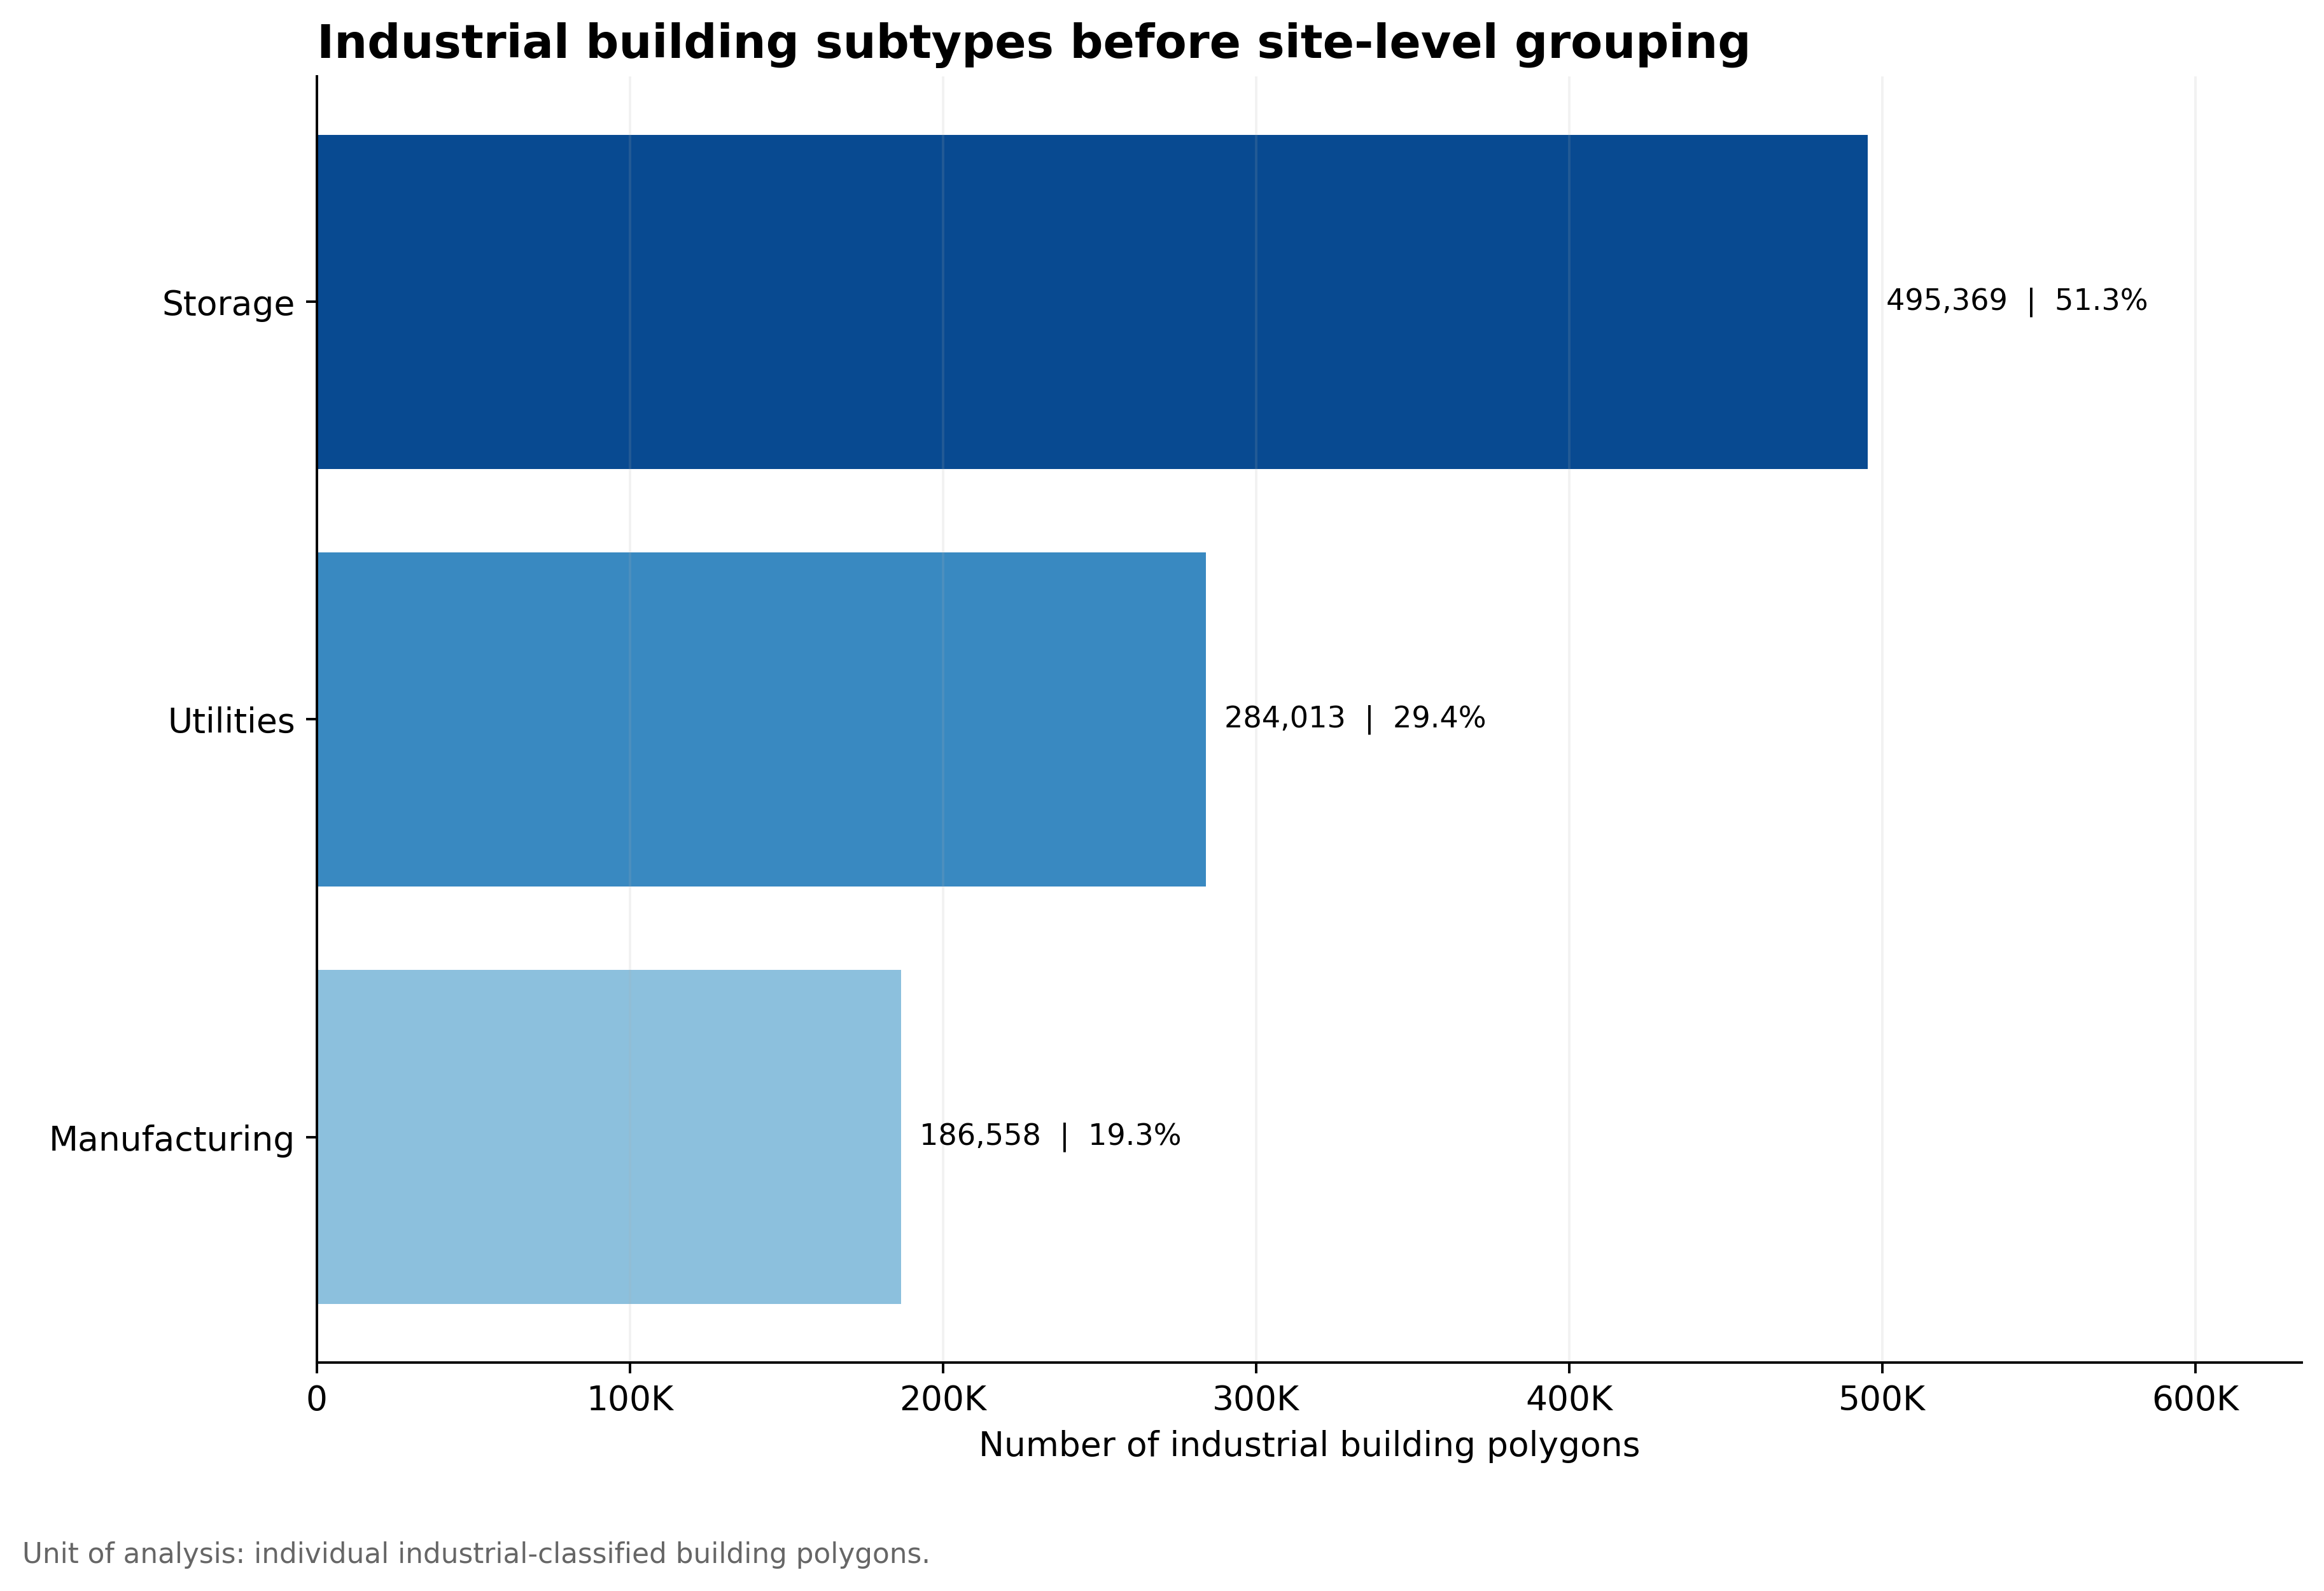

In [38]:
# ============================================================
# 1. INDUSTRIAL BUILDINGS BEFORE GROUPING
# ============================================================

section("1. INDUSTRIAL BUILDINGS BEFORE GROUPING")

industrial_before_grouping = gdf_bldg[
    gdf_bldg["final_l1"] == "industrial"]

print(f"Total buildings in Germany                         : {len(gdf_bldg):,}")
print(f"Industrial buildings before grouping               : {len(industrial_before_grouping):,}")
print(
    f"Share of all buildings classified as industrial    : "
    f"{len(industrial_before_grouping) / len(gdf_bldg) * 100:.2f}%")

industrial_before_distribution = print_distribution(
    industrial_before_grouping["final_l2"],
    "Industrial subtype distribution before grouping")

before_counts = top_categories_with_other(industrial_before_grouping["final_l2"], top_n=12,).sort_values()

before_shares = (before_counts / before_counts.sum() * 100)

fig, ax = plt.subplots(figsize=(11.5, 7.5))

bars = ax.barh([clean_label(value) for value in before_counts.index], before_counts.values,
    color=plt.colormaps["Blues"]( np.linspace(0.42, 0.9, len(before_counts))),)

for bar, count, share in zip(bars, before_counts.values, before_shares.values,):
    ax.text(bar.get_width() + before_counts.max() * 0.012, bar.get_y() + bar.get_height() / 2,
        f"{count:,.0f}  |  {share:.1f}%", va="center", fontsize=9.5,)

ax.set_title("Industrial building subtypes before site-level grouping", loc="left",)
ax.set_xlabel("Number of industrial building polygons")
ax.xaxis.set_major_formatter(compact_formatter)
ax.set_xlim(0, before_counts.max() * 1.28)
ax.grid(axis="x", alpha=0.16)

fig.text(0.01, -0.01, "Unit of analysis: individual industrial-classified building polygons.",
    fontsize=9, color="#666666",)





2. BUILDINGS INSIDE INDUSTRIAL LAND-USE ZONES
All buildings inside industrial land-use zones      : 660,189
Number of industrial land-use zones                 : 50,480
Average number of buildings per industrial zone     : 13.08



Industrial-classified buildings inside zones        : 450,863
Other building classes inside industrial zones      : 209,326
Industrial share of buildings inside zones          : 68.29%
Non-industrial share of buildings inside zones      : 31.71%

L1 distribution of all buildings inside industrial land-use zones
----------------------------------------------------------------------------------------------------
                  count share_pct
final_l1                         
industrial      450,863    68.29%
commercial       98,306    14.89%
filter           83,290    12.62%
residential      18,489     2.80%
civic             3,450     0.52%
agricultural      2,440     0.37%
other             1,634     0.25%
transportation      824     0.12%
semi_commercial     632     0.10%
military            261     0.04%

Total: 660,189

Industrial subtype distribution of industrial buildings inside zones
-------------------------------------------------------------------------------------------

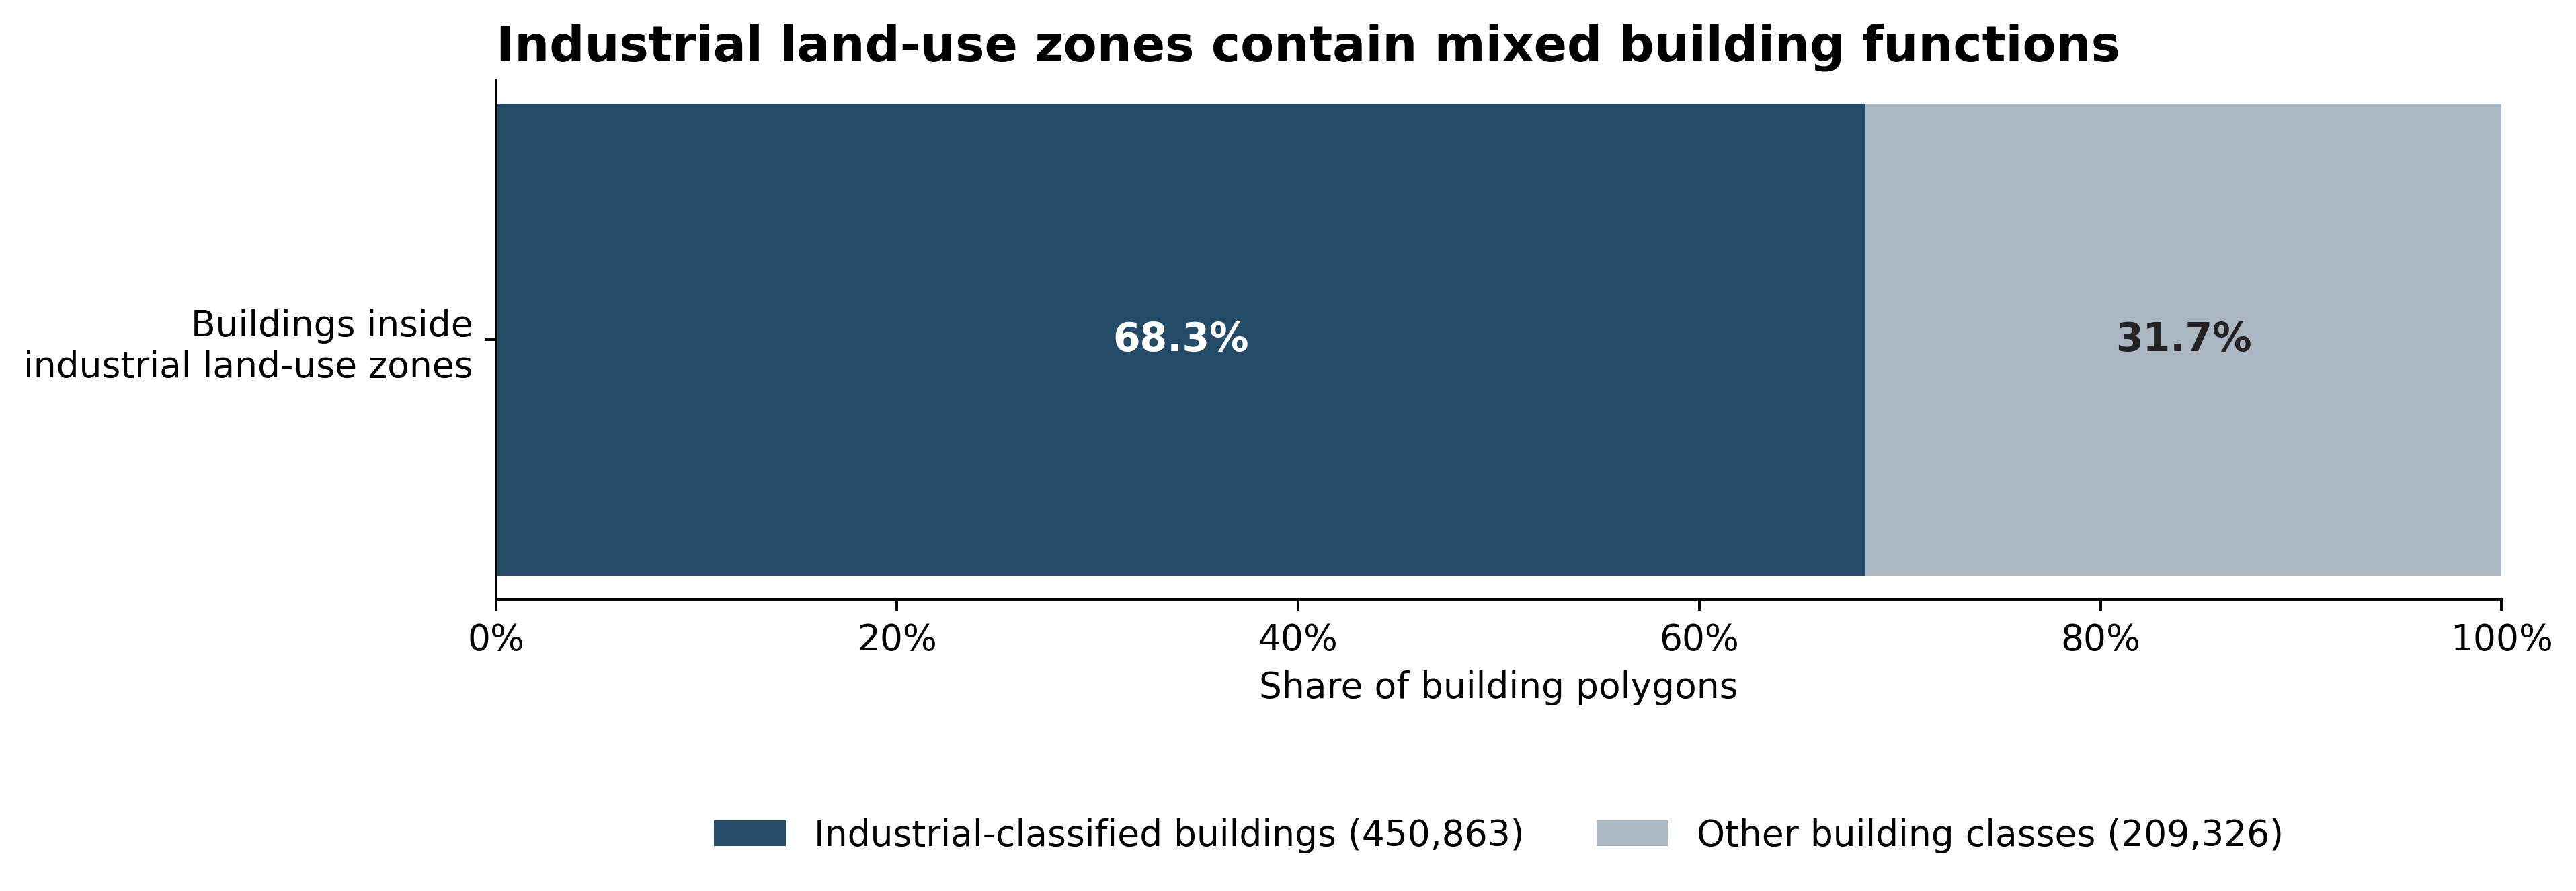

In [39]:
# ============================================================
# 2. BUILDINGS ASSOCIATED WITH INDUSTRIAL LAND-USE ZONES
# ============================================================

section("2. BUILDINGS INSIDE INDUSTRIAL LAND-USE ZONES")

# `grouped` was already created as all buildings whose parent_id starts with IND_
print(f"All buildings inside industrial land-use zones      : {len(grouped):,}")
print(f"Number of industrial land-use zones                 : {len(parent_subtypes):,}")
print(f"Average number of buildings per industrial zone     : "
    f"{len(grouped) / len(parent_subtypes):,.2f}")

industrial_grouped_buildings = grouped[grouped["final_l1"] == "industrial"]

nonindustrial_grouped_buildings = grouped[grouped["final_l1"] != "industrial"]

print(f"\nIndustrial-classified buildings inside zones        : {len(industrial_grouped_buildings):,}")
print(f"Other building classes inside industrial zones      : {len(nonindustrial_grouped_buildings):,}")

print(f"Industrial share of buildings inside zones          : "
    f"{len(industrial_grouped_buildings) / len(grouped) * 100:.2f}%")

print(f"Non-industrial share of buildings inside zones      : "
    f"{len(nonindustrial_grouped_buildings) / len(grouped) * 100:.2f}%")


zone_building_l1_distribution = print_distribution(
    grouped["final_l1"], "L1 distribution of all buildings inside industrial land-use zones")

zone_industrial_l2_distribution = print_distribution(
    industrial_grouped_buildings["final_l2"], "Industrial subtype distribution of industrial buildings inside zones")

# ------------------------------------------------------------
# CHART 2: INDUSTRIAL VS OTHER BUILDINGS INSIDE ZONES
#
# Useful because it justifies retaining child classifications:
# industrial zones are not made up only of industrial buildings.
# ------------------------------------------------------------

zone_composition_counts = pd.Series({
    "Industrial-classified buildings": len(industrial_grouped_buildings),
    "Other building classes": len(nonindustrial_grouped_buildings),
})

zone_composition_shares = (
    zone_composition_counts
    / zone_composition_counts.sum()
    * 100
)

fig, ax = plt.subplots(figsize=(11, 3.8))

left = 0
segment_colors = [COLORS["dark_blue"], COLORS["grey"]]

for (label, count), share, color in zip(
    zone_composition_counts.items(),
    zone_composition_shares.values,
    segment_colors,
):
    ax.barh(
        ["Buildings inside\nindustrial land-use zones"],
        share,
        left=left,
        color=color,
        height=0.48,
        label=f"{label} ({count:,.0f})",
    )

    ax.text(
        left + share / 2,
        0,
        f"{share:.1f}%",
        ha="center",
        va="center",
        color="white" if color == COLORS["dark_blue"] else "#222222",
        fontweight="bold",
        fontsize=12,
    )

    left += share

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xlabel("Share of building polygons")
ax.set_title(
    "Industrial land-use zones contain mixed building functions",
    loc="left",
)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.36),
    ncol=2,
)
fig.subplots_adjust(bottom=0.30)



3. INDUSTRIAL BUILDINGS OUTSIDE INDUSTRIAL LAND-USE ZONES
Standalone industrial buildings                    : 515,077
  With no land-use polygon                          : 180,994
  Inside a non-industrial land-use polygon          : 334,083
Share with no land-use polygon                      : 35.14%
Share inside another land-use type                  : 64.86%

Industrial subtype distribution of standalone industrial buildings
----------------------------------------------------------------------------------------------------
                count share_pct
final_l2                       
storage       259,721    50.42%
utilities     218,994    42.52%
manufacturing  36,362     7.06%

Total: 515,077

Land-use classes containing standalone industrial buildings
----------------------------------------------------------------------------------------------------
                  count share_pct
landuse_l1                       
commercial      164,912    49.36%
residential     130,478  

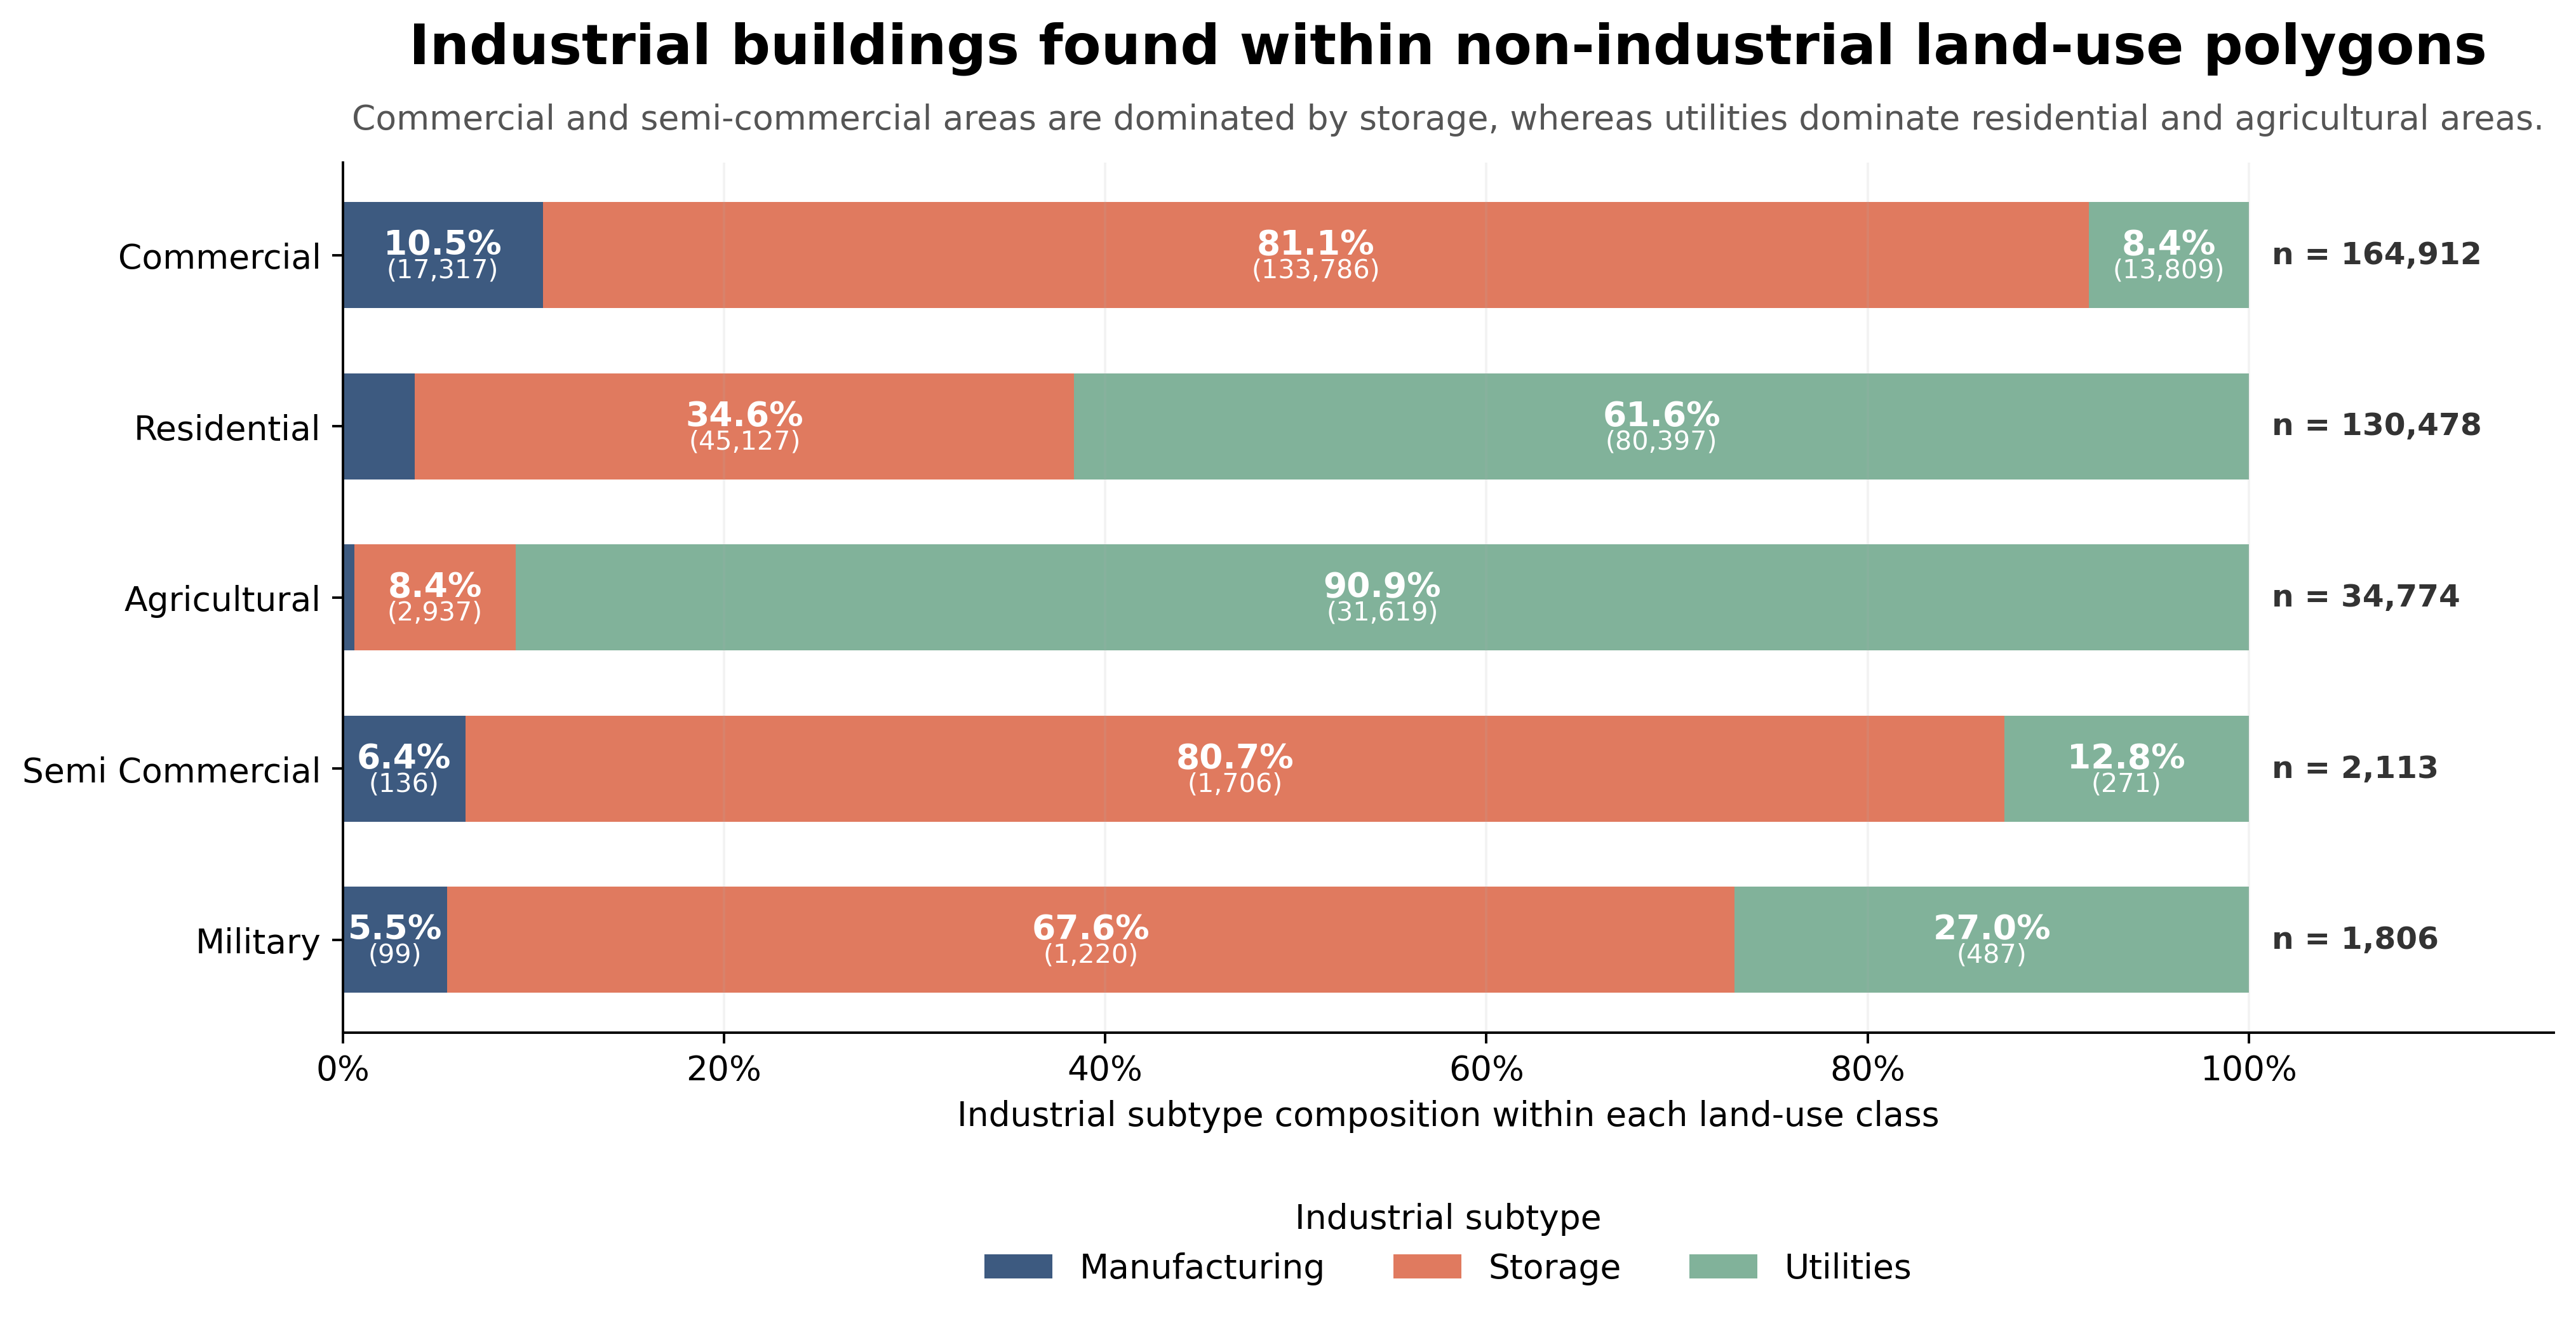

In [40]:
# ============================================================
# 3. INDUSTRIAL BUILDINGS OUTSIDE INDUSTRIAL LAND-USE ZONES
# ============================================================

section("3. INDUSTRIAL BUILDINGS OUTSIDE INDUSTRIAL LAND-USE ZONES")

# `standalone_gdf` was created directly from `standalone_industrial`
print(f"Standalone industrial buildings                    : {len(standalone_gdf):,}")

# Separate buildings with no land-use polygon from those inside a non-industrial land-use polygon.
standalone_no_landuse = standalone_gdf[standalone_gdf["landuse_osm_id"].isna()]
standalone_other_landuse = standalone_gdf[standalone_gdf["landuse_osm_id"].notna()]

print(f"  With no land-use polygon                          : {len(standalone_no_landuse):,}")
print(f"  Inside a non-industrial land-use polygon          : {len(standalone_other_landuse):,}")
print(f"Share with no land-use polygon                      : "
    f"{len(standalone_no_landuse) / len(standalone_gdf) * 100:.2f}%")
print(f"Share inside another land-use type                  : "
    f"{len(standalone_other_landuse) / len(standalone_gdf) * 100:.2f}%")

standalone_building_distribution = print_distribution(
    standalone_gdf["final_l2"], "Industrial subtype distribution of standalone industrial buildings")

if len(standalone_other_landuse) > 0:
    standalone_landuse_distribution = print_distribution(
    standalone_other_landuse["landuse_l1"], "Land-use classes containing standalone industrial buildings")

    # Industrial subtype by non-industrial land-use class
    subtype_by_landuse_counts = pd.crosstab(
        standalone_other_landuse["landuse_l1"].astype("object").fillna("unresolved_landuse"),
        standalone_other_landuse["final_l2"].astype("object").fillna("unresolved_subtype"))

    subtype_by_landuse_counts["total"] = (subtype_by_landuse_counts.sum(axis=1))
    subtype_by_landuse_counts = (subtype_by_landuse_counts.sort_values("total", ascending=False))

    subtype_columns = [column for column in subtype_by_landuse_counts.columns if column != "total"]
    
    subtype_by_landuse_counts = subtype_by_landuse_counts[["total"] + subtype_columns]

    print("\nIndustrial subtype counts within each non-industrial land-use class")
    print("-" * 100)

    print(subtype_by_landuse_counts.to_string(formatters={
            column: lambda x: f"{int(x):,}"
            for column in subtype_by_landuse_counts.columns}))

    # Percentages normalized within each land-use class
    subtype_by_landuse_pct = (subtype_by_landuse_counts.drop(columns="total")
        .div(subtype_by_landuse_counts["total"],axis=0)* 100)

    print("\nIndustrial subtype composition within each non-industrial land-use class (%)")
    print("-" * 100)

    print(subtype_by_landuse_pct.to_string(formatters={column: lambda x: f"{x:.2f}%"
            for column in subtype_by_landuse_pct.columns}))

# ============================================================
# CHART: INDUSTRIAL SUBTYPE COMPOSITION WITHIN
# NON-INDUSTRIAL LAND-USE CLASSES
# ============================================================

# Use the percentage and count tables already created:
# subtype_by_landuse_pct
# subtype_by_landuse_counts

plot_pct = subtype_by_landuse_pct.copy()

# Order land-use classes by total number of industrial buildings
plot_pct = plot_pct.loc[subtype_by_landuse_counts["total"].sort_values(ascending=True).index]
plot_totals = subtype_by_landuse_counts.loc[plot_pct.index,"total"]

# Ensure a consistent subtype order
subtype_order = [subtype for subtype in ["manufacturing", "storage", "utilities"]
    if subtype in plot_pct.columns]

plot_pct = plot_pct[subtype_order]

fig, ax = plt.subplots(figsize=(12, 7.2))
left = np.zeros(len(plot_pct))
subtype_colors = {
    "manufacturing": "#3D5A80",
    "storage": "#E07A5F",
    "utilities": "#81B29A",
}
for subtype in subtype_order:
    values = plot_pct[subtype].to_numpy()
    counts = subtype_by_landuse_counts.loc[plot_pct.index, subtype].to_numpy()
    bars = ax.barh([clean_label(value) for value in plot_pct.index], values, left=left,
        label=clean_label(subtype), color=subtype_colors[subtype], height=0.62,)

    # Add percentage + count inside segment
    for bar, value, count, left_value in zip(bars, values, counts, left,):
        if value >= 5:   # only label if segment wide enough
            x_center = left_value + value / 2
            y_center = bar.get_y() + bar.get_height() / 2
            # Main percentage
            ax.text( x_center, y_center + 0.06,
                f"{value:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white",)
            # Smaller count below percentage
            ax.text(x_center, y_center - 0.09, f"({count:,.0f})", ha="center",
                va="center", fontsize=8.5, color="white",)

    left += values

# Add total count after each full bar
for y_position, total in enumerate(plot_totals):
    ax.text(101.2, y_position, f"n = {total:,.0f}", va="center",
    ha="left", fontsize=10, fontweight="bold", color="#333333",)

ax.set_xlim(0, 116)
ax.set_xlabel("Industrial subtype composition within each land-use class")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100,decimals=0,))
ax.set_title("Industrial buildings found within non-industrial land-use polygons",
    loc="center", pad=32, fontsize=18, fontweight="bold",)
ax.text(0.5, 1.03, ("Commercial and semi-commercial areas are dominated by storage, "
        "whereas utilities dominate residential and agricultural areas."),
        transform=ax.transAxes, fontsize=11, color="#555555", ha="center", va="bottom",)
ax.legend(title="Industrial subtype", loc="upper center", bbox_to_anchor=(0.5, -0.16),
    ncol=3, frameon=False,)
ax.grid(axis="x", alpha=0.15,)

plt.tight_layout(rect=[0, 0.03, 1, 0.91])


In [41]:
standalone_other_landuse[
    (standalone_other_landuse["final_l2"] == "storage")
    & (standalone_other_landuse["landuse_l1"] == "residential")
].sample(2)

,id,final_l1,final_l2,l1_confidence,l2_confidence,label_source,geometry,raw_label,landuse_l1,landuse_l2,...,area,is_abandoned,manmade_osm_id,man_made,manmade_category,parent_id,ind_mapped_subtype,resolved_subtype,resolved_source,resolved_evidence
17477077,1195208027,industrial,storage,0.762113,0.650722,ml_predicted,"POLYGON ((10.87005 48.35971, 10.87004 48.35969...",None,residential,None,...,78.227684,False,<NA>,NaN,NaN,BLDG_1195208027,NaN,storage,standalone_final_l2,storage
6268996,270156633,industrial,storage,0.979289,0.961696,ml_predicted,"POLYGON ((13.37756 52.55971, 13.37754 52.55968...",None,residential,None,...,98.507360,False,<NA>,NaN,NaN,BLDG_270156633,NaN,storage,standalone_final_l2,storage


In [42]:
# ============================================================
# INSPECT INDUSTRIAL SUBTYPES IN NON-INDUSTRIAL LAND USE
# ============================================================

# Prepare inspection dataset
inspection_cols = ["id", "final_l1", "final_l2", "l1_confidence", "l2_confidence", 
                   "label_source", "rule_source", "raw_label", "ind_mapped_subtype",
                   "man_made", "manmade_category", "landuse_l1", "landuse_l2", 
                   "landuse_used", "landuse_osm_id", "area", "geometry"]
inspection_cols = [c for c in inspection_cols if c in standalone_other_landuse.columns]
inspection = standalone_other_landuse[inspection_cols].copy()

print(f"Records for inspection: {len(inspection):,}")

# ============================================================
# 2. CLASSIFICATION SOURCE AND CONFIDENCE BY COMBINATION
# ============================================================

confidence_summary = inspection.groupby(["landuse_l1", "final_l2"], observed=True).agg(
    building_count=("id", "size"),
    median_area_sqm=("area", "median"),
    mean_area_sqm=("area", "mean"),
    median_l1_confidence=("l1_confidence", "median"),
    median_l2_confidence=("l2_confidence", "median"),
    p10_l2_confidence=("l2_confidence", lambda v: v.quantile(0.10)),
    p90_l2_confidence=("l2_confidence", lambda v: v.quantile(0.90)),
).sort_values("building_count", ascending=False)

print("\nClassification Confidence & Area Summary")
print("-" * 110)
print(confidence_summary.to_string(formatters={
    "building_count": lambda x: f"{int(x):,}",
    "median_area_sqm": lambda x: f"{x:,.1f}",
    "mean_area_sqm": lambda x: f"{x:,.1f}",
    "median_l1_confidence": lambda x: f"{x:.3f}",
    "median_l2_confidence": lambda x: f"{x:.3f}",
    "p10_l2_confidence": lambda x: f"{x:.3f}",
    "p90_l2_confidence": lambda x: f"{x:.3f}",
}))

# Label & rule source distribution
label_source_table = pd.crosstab(
    [inspection["landuse_l1"], inspection["final_l2"]],
    inspection["label_source"].astype("object").fillna("missing"))
print("\nLabel Source Counts\n", "-" * 110)
print(label_source_table.to_string())

label_source_pct = pd.crosstab(
    [inspection["landuse_l1"], inspection["final_l2"]],
    inspection["label_source"].astype("object").fillna("missing"),
    normalize="index") * 100
print("\nLabel Source Percentages\n", "-" * 110)
print(label_source_pct.to_string(
    formatters={col: lambda x: f"{x:.1f}%" for col in label_source_pct.columns}))

# ============================================================
# 3. TOP RAW EVIDENCE BY COMBINATION
# ============================================================

def top_values_by_combination(df, col, top_n=10):
    """Most frequent values per landuse_l1 × final_l2 combination."""
    if col not in df.columns: return None
    working = df[["landuse_l1", "final_l2", col]].copy()
    working[col] = working[col].astype("object").fillna("missing")
    result = working.groupby(["landuse_l1", "final_l2", col], observed=True).size().rename("count").reset_index()
    result["rank"] = result.groupby(["landuse_l1", "final_l2"], observed=True)["count"].rank(method="first", ascending=False)
    return result[result["rank"] <= top_n].drop(columns="rank").sort_values(
        ["landuse_l1", "final_l2", "count"], ascending=[True, True, False])

evidence_columns = ["raw_label", "ind_mapped_subtype", "man_made", "manmade_category", "landuse_l2", "landuse_used", "label_source", "rule_source"]
evidence_results = {}

for col in evidence_columns:
    if col not in inspection.columns: continue
    result = top_values_by_combination(inspection, col, top_n=10)
    evidence_results[col] = result
    print(f"\nTop {col} Values\n" + "=" * 110)
    print(result.to_string(index=False, formatters={"count": lambda x: f"{int(x):,}"}))

# Focus on key combinations
target_combinations = [
    ("commercial", "storage"), ("commercial", "manufacturing"),
    ("residential", "utilities"), ("residential", "storage"),
    ("agricultural", "utilities"), ("semi_commercial", "storage"), ("military", "storage"),
]

for landuse_class, subtype in target_combinations:
    subset = inspection[(inspection["landuse_l1"] == landuse_class) & (inspection["final_l2"] == subtype)]
    print(f"\n{'=' * 110}\n{landuse_class.upper()} × {subtype.upper()}\n{'=' * 110}")
    print(f"Buildings: {len(subset):,}\n")
    for col in ["raw_label", "man_made", "manmade_category", "landuse_l2", "landuse_used", "label_source", "rule_source"]:
        if col not in subset.columns: continue
        print(f"Top {col}:")
        print(subset[col].astype("object").fillna("missing").value_counts().head(15).to_string())

# ============================================================
# 4. AREA DISTRIBUTION
# ============================================================

area_summary = inspection.groupby(["landuse_l1", "final_l2"], observed=True)["area"].agg(
    count="count", minimum="min",
    p10=lambda v: v.quantile(0.10), p25=lambda v: v.quantile(0.25),
    median="median", p75=lambda v: v.quantile(0.75),
    p90=lambda v: v.quantile(0.90), p99=lambda v: v.quantile(0.99),
    maximum="max").sort_values("count", ascending=False)

print(area_summary.to_string(formatters={col: lambda x: f"{x:,.1f}" for col in area_summary.columns}))

# ============================================================
# 5. STRATIFIED MANUAL-INSPECTION SAMPLE
# ============================================================

inspection_sample = inspection.groupby(
    ["landuse_l1", "final_l2"], group_keys=False, observed=True
).apply(lambda g: g.sample(n=min(20, len(g)), random_state=42), include_groups=False).reset_index(drop=True)

sample_cols = ["id", "landuse_l1", "landuse_l2", "landuse_used", "final_l2", "l2_confidence",
               "label_source", "rule_source", "raw_label", "ind_mapped_subtype", "man_made", "manmade_category", "area", "geometry"]
sample_cols = [c for c in sample_cols if c in inspection_sample.columns]
inspection_sample = inspection_sample[sample_cols]

print(inspection_sample.drop(columns="geometry", errors="ignore").head(100).to_string(index=False))

inspection_sample_gdf = gpd.GeoDataFrame(inspection_sample, geometry="geometry", crs=standalone_other_landuse.crs)

# Optional map (keep small)
map_sample = inspection_sample_gdf.copy()
if len(map_sample) > 300:
    map_sample = map_sample.sample(300, random_state=42)

tooltip_columns = [c for c in ["id", "landuse_l1", "landuse_l2", "final_l2", "l2_confidence",
                                "label_source", "rule_source", "raw_label", "man_made", "manmade_category", "area"]
                   if c in map_sample.columns]

Records for inspection: 334,083

Classification Confidence & Area Summary
--------------------------------------------------------------------------------------------------------------
                              building_count median_area_sqm mean_area_sqm median_l1_confidence median_l2_confidence p10_l2_confidence p90_l2_confidence
landuse_l1      final_l2                                                                                                                                
commercial      storage              133,786           431.4       1,033.8                0.714                0.892             0.640             0.976
residential     utilities             80,397            41.7          46.9                0.744                0.977             0.744             0.999
                storage               45,127           178.4         301.5                0.641                0.902             0.629             0.981
agricultural    utilities             31,619      


### What the results actually indicate

#### 1. Agricultural land use → utilities: strongly defensible

Utilities account for **90.9%** of industrial-classified buildings in agricultural polygons.

This pattern has strong supporting evidence:

* 50.1% are directly tagged in Stage 1.
* Median subtype confidence among predicted records is approximately **1.00**.
* 83% are located in `farmyard` polygons.
* Common tags include:

  * `storage_tank`: 7,064
  * `digester`: 4,567
  * `transformer_tower`: 1,912
  * `substation`: 962
  * `pumping_station`: 125
  * `water_tower`, `gasometer`, and wastewater infrastructure

These are plausible components of agricultural operations: biogas plants, irrigation and water systems, tanks, pumping facilities, and local electricity infrastructure.

However, you should inspect the **3,143 silos** currently included under utilities. A silo is normally a storage structure, so some of these may require remapping from `utilities` to `storage`.

**Defensible reasoning:**

> Utility-related industrial buildings dominate agricultural land-use areas because farms and farmyards contain supporting energy, water, storage-tank, pumping, and biogas infrastructure. The prevalence of directly tagged digesters, storage tanks, substations, and transformer structures supports this interpretation.


#### 2. Residential land use → utilities: plausible and reasonably supported

Utilities account for **59.8%** of industrial buildings within residential polygons.

The physical characteristics support this:

* Median area: only **41.2 m²**
* 90th percentile: **69.7 m²**
* Median prediction confidence: **0.971**
* 34.2% are directly tagged
* Common direct tags include:

  * `substation`: 9,982
  * `minor_distribution`: 6,139
  * `transformer_tower`: 5,626
  * `storage_tank`: 1,631
  * `water_tower`, `transformer`, `pumping_station`

These are small neighborhood-serving facilities that are logically embedded within residential areas rather than placed in separate industrial zones.

The main limitation is that **64.3% are ML predictions with missing raw labels**. Therefore, the pattern is plausible but should still be checked visually.

**Defensible reasoning:**

> Utilities occurring within residential land-use polygons primarily represent small, distributed infrastructure such as substations, transformer buildings, local distribution facilities, pumping stations, and water infrastructure serving surrounding residential neighbourhoods. Their small median footprint and the presence of explicit utility tags support this interpretation.

#### 3. Commercial land use → storage: plausible, but mainly model-driven

Storage accounts for **78.8%** of industrial buildings in commercial polygons.

The building dimensions are consistent with warehouses:

* Median area: **421 m²**
* Mean area: **1,020 m²**
* 90th percentile: **1,918 m²**
* Explicit tags include:

  * `warehouse`: 7,229
  * `industrial`: 24,647
  * some logistics and depot tags

Commercial and storage uses commonly coexist in business parks, wholesale areas, retail distribution centres and logistics areas. OSM contributors may also use `landuse=commercial` for areas containing warehouses rather than applying `landuse=industrial`.

But this result needs careful wording because:

* **75.6% are ML-only predictions**
* 98,753 of the 130,648 records have no raw industrial label
* Only 5.5% are directly tagged as a subtype

Therefore, the result cannot yet prove that all 130,648 records are genuine warehouses.

**Defensible reasoning:**

> The dominance of storage buildings in commercial land-use polygons likely reflects the inclusion of warehouses, wholesale facilities, distribution centres, and logistics buildings within broadly mapped commercial areas. Their comparatively large building footprints are consistent with storage functions. Nevertheless, because most of these classifications were produced by the machine-learning model rather than explicit OSM tags, this pattern requires targeted visual validation.

Use **“likely reflects”**, not **“is caused by.”**


#### 4. Residential land use → storage: possible, but less certain

Storage represents **35.8%** of the industrial buildings in residential polygons.

Possible explanations include:

* small warehouses or depots on the edge of residential areas;
* older industrial or workshop buildings embedded in settlements;
* broadly drawn or outdated residential polygons;
* mixed residential–commercial locations;
* spatial intersection with a land-use polygon whose dominant use is residential.

The median area of **180 m²** is larger than a typical small utility structure but smaller than the median commercial warehouse. That is plausible for local workshops, storage sheds and small warehouses.

However:

* 61.4% are ML-only predictions;
* another 26.2% were assigned through predicted subtype processing;
* only 12.4% are directly tagged;
* 27,663 have no raw label.

This pattern is therefore considerably less secure than agricultural utilities.


#### 5. Commercial land use → manufacturing: plausible but uncertain

Manufacturing buildings in commercial polygons have:

* median area: **1,074 m²**
* mean area: **2,023 m²**
* common tags: `industrial`, `works`, `manufacture`, `factory`
* median prediction confidence: **0.691**

Their large footprint is consistent with manufacturing or workshop buildings. Commercial and industrial activities also coexist in Gewerbegebiete, which may be mapped as commercial even when light manufacturing occurs there.

But 57.8% are ML-only predictions and the median confidence is lower than for storage or utilities. Treat this as plausible, not conclusively validated.


#### 6. Semi-commercial and military results

The numbers are much smaller:

* Semi-commercial storage: 1,701
* Military storage: 1,283

Storage inside military zones is plausible because military sites contain depots, hangars and supply warehouses. Nevertheless, 75.8% of military-storage records are ML-only predictions.

These categories can be mentioned, but they should not drive your main conclusion.

### Important limitation in the confidence results

Your confidence summary excludes records with missing confidence values. Directly tagged Stage 1 records often have `NaN` confidence because they were not predicted by the model.

Therefore:

> The reported median confidence values describe the ML-classified subset, not every building in each land-use/subtype combination.


### Overall interpretation

The result is explained by a combination of four mechanisms:

1. **Land use and building function are different concepts.**
   A polygon records the dominant use of an area, while individual buildings can perform supporting functions.

2. **Utilities are distributed close to the demand they serve.**
   Substations, transformers, pumping stations and water infrastructure naturally occur in residential and agricultural areas.

3. **Commercial polygons can contain warehouses and light industry.**
   Business parks and wholesale areas frequently combine offices, retail, storage and logistics.

4. **OSM land-use polygons can be broad, incomplete or outdated.**
   Some apparent inconsistencies may result from coarse boundaries rather than incorrect building classifications.

A fifth mechanism is possible:

5. **Some results may be model errors.**
   This is particularly relevant for commercial storage and residential storage because most records lack direct subtype tags.

###  interpretation

> Of the 511,648 industrial buildings located outside industrial land-use zones, 330,626, or 64.6%, intersected a different mapped land-use class. This does not necessarily represent a contradiction because land-use polygons describe the dominant use of an area, whereas individual buildings can serve supporting or mixed functions. Utility buildings dominated agricultural and residential land-use polygons. In agricultural areas, this pattern was supported by explicit tags for storage tanks, digesters, substations, transformer structures and pumping facilities, indicating the presence of biogas, water and energy infrastructure associated with farm operations. In residential areas, utility buildings had a median footprint of only 41.2 m² and were frequently tagged as substations, transformer towers or minor distribution facilities, consistent with small infrastructure serving surrounding neighbourhoods.

> Storage buildings accounted for 78.8% of the industrial buildings located in commercial land-use polygons. Their median footprint of 421 m² and the occurrence of warehouse and industrial tags suggest that this category includes warehouses, distribution facilities and logistics buildings located within broadly mapped commercial or business areas. However, 75.6% of these classifications were produced directly by the machine-learning model and lacked explicit raw subtype tags. The magnitude of this pattern should therefore be interpreted cautiously and verified through stratified visual inspection.




In [43]:
# ============================================================
# 4. INDUSTRIAL LAND-USE ZONE GROUPING RESULTS
# ============================================================

section("4. INDUSTRIAL LAND-USE ZONE GROUPING RESULTS")

# `parent_subtypes` contains exactly one record per industrial land-use zone.
multi_building_zones = parent_subtypes[parent_subtypes["n_buildings"] > 1]
single_building_zones = parent_subtypes[parent_subtypes["n_buildings"] == 1]

print(f"Industrial land-use zone parents                   : {len(parent_subtypes):,}")
print(f"  Multi-building industrial zones                  : {len(multi_building_zones):,}")
print(f"  Single-building industrial zones                 : {len(single_building_zones):,}")
print(f"Share of zones containing multiple buildings       : {len(multi_building_zones) / len(parent_subtypes) * 100:.2f}%")
print(f"Mean buildings per zone                            : {parent_subtypes['n_buildings'].mean():,.2f}")
print(f"Median buildings per zone                          : {parent_subtypes['n_buildings'].median():,.0f}")
print(f"Mean buildings per multi-building zone             : {multi_building_zones['n_buildings'].mean():,.2f}")
print(f"Maximum buildings in one industrial zone           : {parent_subtypes['n_buildings'].max():,.0f}")

zone_size_summary = parent_subtypes["n_buildings"].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

print("\nIndustrial-zone size summary")
print("-" * 100)
print(zone_size_summary.to_string())

largest_zones = (parent_subtypes[
        ["parent_id", "landuse_osm_id", "subtype", "subtype_source", "n_buildings", "n_industrial_buildings", 
         "total_area"]].sort_values("n_buildings", ascending=False).head(15))

print("\nLargest industrial zones by number of buildings")
print("-" * 100)
print(largest_zones.to_string( index=False, formatters={
            "n_buildings": lambda x: f"{int(x):,}",
            "n_industrial_buildings": lambda x: f"{int(x):,}",
            "total_area": lambda x: f"{x:,.0f}"}))




4. INDUSTRIAL LAND-USE ZONE GROUPING RESULTS
Industrial land-use zone parents                   : 50,480
  Multi-building industrial zones                  : 41,718
  Single-building industrial zones                 : 8,762
Share of zones containing multiple buildings       : 82.64%
Mean buildings per zone                            : 13.08
Median buildings per zone                          : 5
Mean buildings per multi-building zone             : 15.62
Maximum buildings in one industrial zone           : 2,357

Industrial-zone size summary
----------------------------------------------------------------------------------------------------
count    50480.000000
mean        13.078229
std         31.216745
min          1.000000
25%          2.000000
50%          5.000000
75%         12.000000
90%         29.000000
95%         50.000000
99%        130.000000
max       2357.000000

Largest industrial zones by number of buildings
-------------------------------------------------------------

Look innto second largest, doesnt look like an industrial site

In [44]:
gdf_bldg[(gdf_bldg['landuse_osm_id']==147204151.0)&(gdf_bldg['raw_label'].notna())].final_l2.value_counts()

final_l2
retail        14
storage        8
school         5
office         3
food_drink     3
MFH            3
utilities      2
greenhouse     2
Name: count, dtype: int64


5. REDUCTION IN POTENTIAL LOAD-ASSIGNMENT UNITS
Industrial land-use zones
----------------------------------------------------------------------
All building polygons inside industrial zones      : 660,189
  Industrial-classified buildings                  : 450,863
  Other/support building classes                   : 209,326
Industrial-zone site parents after grouping        : 50,480
Reduction in linked records                        : 609,709
Percentage reduction                               : 92.35%

Complete industrial parent dataset
----------------------------------------------------------------------
Zone-linked building polygons                      : 660,189
Standalone industrial buildings                    : 515,077
Total linked building records before grouping      : 1,175,266
Final zone and standalone parent records           : 565,557
Reduction in linked records                        : 609,709
Percentage reduction                               : 51.88%

Interpretation:

(0.0, 1316297.9200000002)

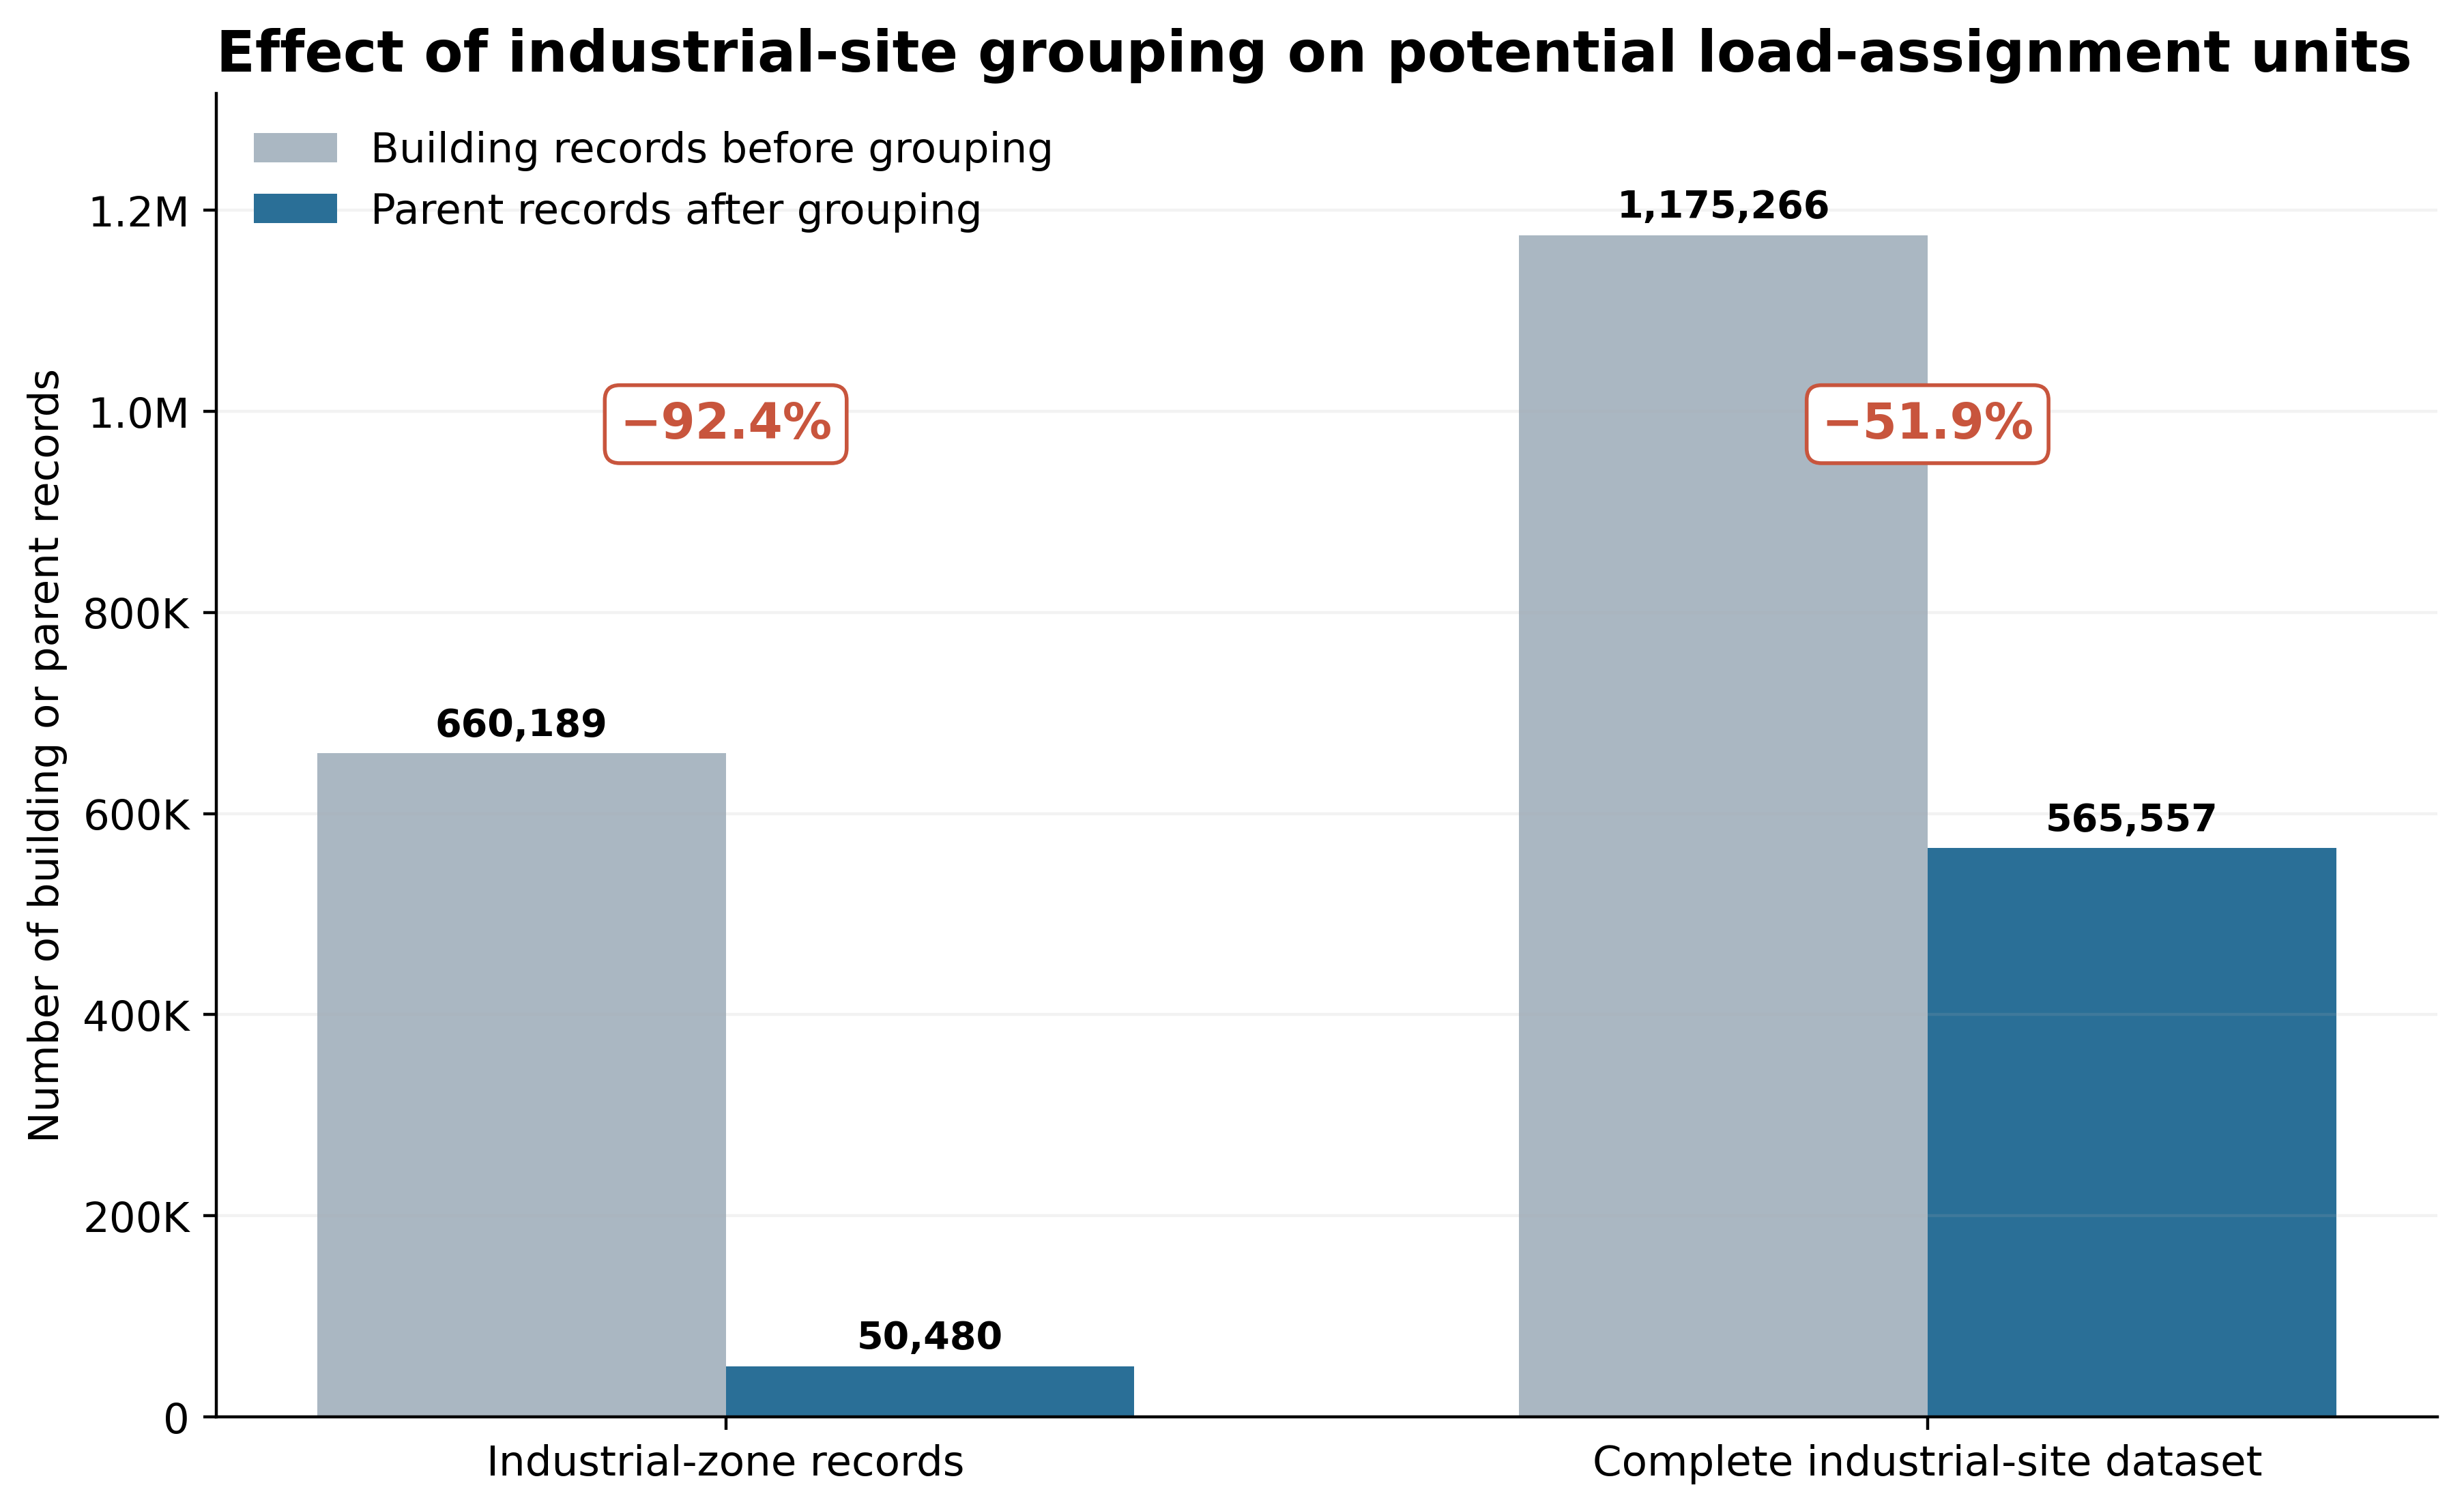

In [45]:
# ============================================================
# 5. REDUCTION IN POTENTIAL LOAD-ASSIGNMENT UNITS
# ============================================================

section("5. REDUCTION IN POTENTIAL LOAD-ASSIGNMENT UNITS")

zone_buildings_before = len(grouped)
zone_industrial_buildings = len(industrial_grouped_buildings)
zone_other_buildings = len(nonindustrial_grouped_buildings)
zone_parents_after = len(parent_subtypes)

standalone_before = len(standalone_gdf)
all_linked_before = zone_buildings_before + standalone_before
all_final_parents = len(final_parents)

zone_reduction = zone_buildings_before - zone_parents_after
zone_reduction_pct = zone_reduction / zone_buildings_before * 100

overall_reduction = all_linked_before - all_final_parents
overall_reduction_pct = overall_reduction / all_linked_before * 100

print("Industrial land-use zones")
print("-" * 70)
print(f"All building polygons inside industrial zones      : {zone_buildings_before:,}")
print(f"  Industrial-classified buildings                  : {zone_industrial_buildings:,}")
print(f"  Other/support building classes                   : {zone_other_buildings:,}")
print(f"Industrial-zone site parents after grouping        : {zone_parents_after:,}")
print(f"Reduction in linked records                        : {zone_reduction:,}")
print(f"Percentage reduction                               : {zone_reduction_pct:.2f}%")

print("\nComplete industrial parent dataset")
print("-" * 70)
print(f"Zone-linked building polygons                      : {zone_buildings_before:,}")
print(f"Standalone industrial buildings                    : {standalone_before:,}")
print(f"Total linked building records before grouping      : {all_linked_before:,}")
print(f"Final zone and standalone parent records           : {all_final_parents:,}")
print(f"Reduction in linked records                        : {overall_reduction:,}")
print(f"Percentage reduction                               : {overall_reduction_pct:.2f}%")

print(
    "\nInterpretation: the zone-level calculation includes all buildings "
    "inside industrial land-use polygons. Non-industrial buildings are "
    "retained as child records but do not form separate site-level "
    "load-assignment units."
)

# ============================================================
# CHART: GROUPING IMPACT
# ============================================================

grouping_impact = pd.DataFrame({
    "Scope": ["Industrial-zone records", "Complete industrial-site dataset"],
    "Before grouping": [zone_buildings_before, all_linked_before],
    "After grouping": [zone_parents_after, all_final_parents],
    "Reduction": [zone_reduction_pct, overall_reduction_pct]})

x = np.arange(len(grouping_impact))
width = 0.34
fig, ax = plt.subplots(figsize=(10.5, 6.3), dpi=400)

before = ax.bar(x - width / 2, grouping_impact["Before grouping"], width, color=COLORS["grey"],
    label="Building records before grouping")

after = ax.bar(x + width / 2, grouping_impact["After grouping"], width, color=COLORS["blue"],
    label="Parent records after grouping")

for bars in (before, after):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + grouping_impact["Before grouping"].max() * 0.015,
            f"{bar.get_height():,.0f}", ha="center", fontweight="bold", fontsize=10)

for position, reduction in zip(x, grouping_impact["Reduction"]):
    ax.text(position, grouping_impact["Before grouping"].max() * 0.84, f"−{reduction:.1f}%",
        ha="center", va="center", fontsize=13, fontweight="bold", color=COLORS["red"],
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": COLORS["red"]})

ax.set_xticks(x, grouping_impact["Scope"])
ax.set_ylabel("Number of building or parent records")
ax.yaxis.set_major_formatter(compact_formatter)
ax.set_title("Effect of industrial-site grouping on potential load-assignment units", loc="left")
ax.legend()
ax.grid(axis="y", alpha=0.16)
ax.set_ylim(0, grouping_impact["Before grouping"].max() * 1.12)



In [46]:


# ============================================================
# 6. FINAL DISTRIBUTION OF INDUSTRIAL-ZONE PARENTS
# ============================================================

section("6. FINAL SUBTYPE DISTRIBUTION OF INDUSTRIAL LAND-USE ZONES")

zone_parent_distribution = print_distribution(
    parent_subtypes["subtype"],
    "Industrial land-use zone parent subtype distribution"
)




6. FINAL SUBTYPE DISTRIBUTION OF INDUSTRIAL LAND-USE ZONES

Industrial land-use zone parent subtype distribution
----------------------------------------------------------------------------------------------------
                           count share_pct
subtype                                   
manufacturing             25,542    50.60%
storage                    8,808    17.45%
utilities                  2,647     5.24%
water_utilities            2,432     4.82%
energy_generation          1,666     3.30%
mining_quarry              1,646     3.26%
commercial                 1,577     3.12%
grid_infrastructure        1,257     2.49%
low_demand_infrastructure  1,067     2.11%
logistics                    752     1.49%
warehouse                    571     1.13%
waste_management             345     0.68%
silo                         318     0.63%
food_processing              282     0.56%
construction_materials       270     0.53%
wood_processing              211     0.42%
engineering

In [47]:

# ============================================================
# 7. FINAL DISTRIBUTION OF STANDALONE PARENTS
# ============================================================

section("7. FINAL SUBTYPE DISTRIBUTION OF STANDALONE INDUSTRIAL PARENTS")

standalone_parent_distribution = print_distribution(
    standalone_parents["subtype"],
    "Standalone industrial parent subtype distribution"
)


# ============================================================
# 8. TOTAL FINAL PARENT DISTRIBUTION
# ============================================================

section("8. TOTAL FINAL PARENT DISTRIBUTION")

total_parent_distribution = print_distribution(
    final_parents["subtype"],
    "Subtype distribution across all final parent records"
)

print(
    "\nInterpretation warning: the total distribution is valid as the "
    "distribution of final parent/load-assignment records. It should not "
    "be interpreted directly as the distribution of industrial companies "
    "or establishments because every standalone building is retained as "
    "one parent."
)


7. FINAL SUBTYPE DISTRIBUTION OF STANDALONE INDUSTRIAL PARENTS



Standalone industrial parent subtype distribution
----------------------------------------------------------------------------------------------------
                          count share_pct
subtype                                  
storage                 232,733    45.18%
utilities               143,378    27.84%
manufacturing            40,999     7.96%
grid_infrastructure      37,697     7.32%
water_utilities          24,737     4.80%
warehouse                20,298     3.94%
biogas                    7,071     1.37%
silo                      5,518     1.07%
logistics                 1,173     0.23%
energy_generation         1,033     0.20%
food_processing             196     0.04%
engineering                  53     0.01%
wood_processing              37     0.01%
waste_management             31     0.01%
heating_supply               25     0.00%
hightech_manufacturing       19     0.00%
construction_materials       19     0.00%
mining_quarry                16     0.00%
chemical

In [48]:
# ============================================================
# 9. SIDE-BY-SIDE DISTRIBUTION COMPARISON
# ============================================================

section("9. ZONE VS STANDALONE VS TOTAL SUBTYPE DISTRIBUTION")

def count_subtypes(df):
    return df["subtype"].astype("object").fillna("unresolved").value_counts()

zone_counts = count_subtypes(parent_subtypes)
standalone_counts = count_subtypes(standalone_parents)
total_counts = count_subtypes(final_parents)

all_subtypes = zone_counts.index.union(standalone_counts.index).union(total_counts.index)

distribution_comparison = pd.DataFrame(
    {
        "zone_parents": zone_counts.reindex(all_subtypes, fill_value=0),
        "standalone_parents": standalone_counts.reindex(all_subtypes, fill_value=0),
        "all_parents": total_counts.reindex(all_subtypes, fill_value=0),
    },
    index=all_subtypes,
)

distribution_comparison["zone_share_pct"] = (
    distribution_comparison["zone_parents"] / len(parent_subtypes) * 100
)
distribution_comparison["standalone_share_pct"] = (
    distribution_comparison["standalone_parents"] / len(standalone_parents) * 100
)
distribution_comparison["all_parent_share_pct"] = (
    distribution_comparison["all_parents"] / len(final_parents) * 100
)

distribution_comparison["share_from_zones_pct"] = (
    distribution_comparison["zone_parents"]
    .div(distribution_comparison["all_parents"].replace(0, pd.NA))
    .fillna(0)
    * 100
)
distribution_comparison["share_from_standalone_pct"] = (
    distribution_comparison["standalone_parents"]
    .div(distribution_comparison["all_parents"].replace(0, pd.NA))
    .fillna(0)
    * 100
)

distribution_comparison = distribution_comparison.sort_values("all_parents", ascending=False)

fmt_int = lambda x: f"{int(x):,}"
fmt_pct = lambda x: f"{x:.2f}%"

print(
    distribution_comparison.to_string(
        formatters={
            "zone_parents": fmt_int,
            "zone_share_pct": fmt_pct,
            "standalone_parents": fmt_int,
            "standalone_share_pct": fmt_pct,
            "all_parents": fmt_int,
            "all_parent_share_pct": fmt_pct,
            "share_from_zones_pct": fmt_pct,
            "share_from_standalone_pct": fmt_pct,
        }
    )
)


9. ZONE VS STANDALONE VS TOTAL SUBTYPE DISTRIBUTION
                          zone_parents standalone_parents all_parents zone_share_pct standalone_share_pct all_parent_share_pct share_from_zones_pct share_from_standalone_pct
subtype                                                                                                                                                                      
storage                          8,808            232,733     241,541         17.45%               45.18%               42.71%                3.65%                    96.35%
utilities                        2,647            143,378     146,025          5.24%               27.84%               25.82%                1.81%                    98.19%
manufacturing                   25,542             40,999      66,541         50.60%                7.96%               11.77%               38.39%                    61.61%
grid_infrastructure              1,257             37,697      38,954        

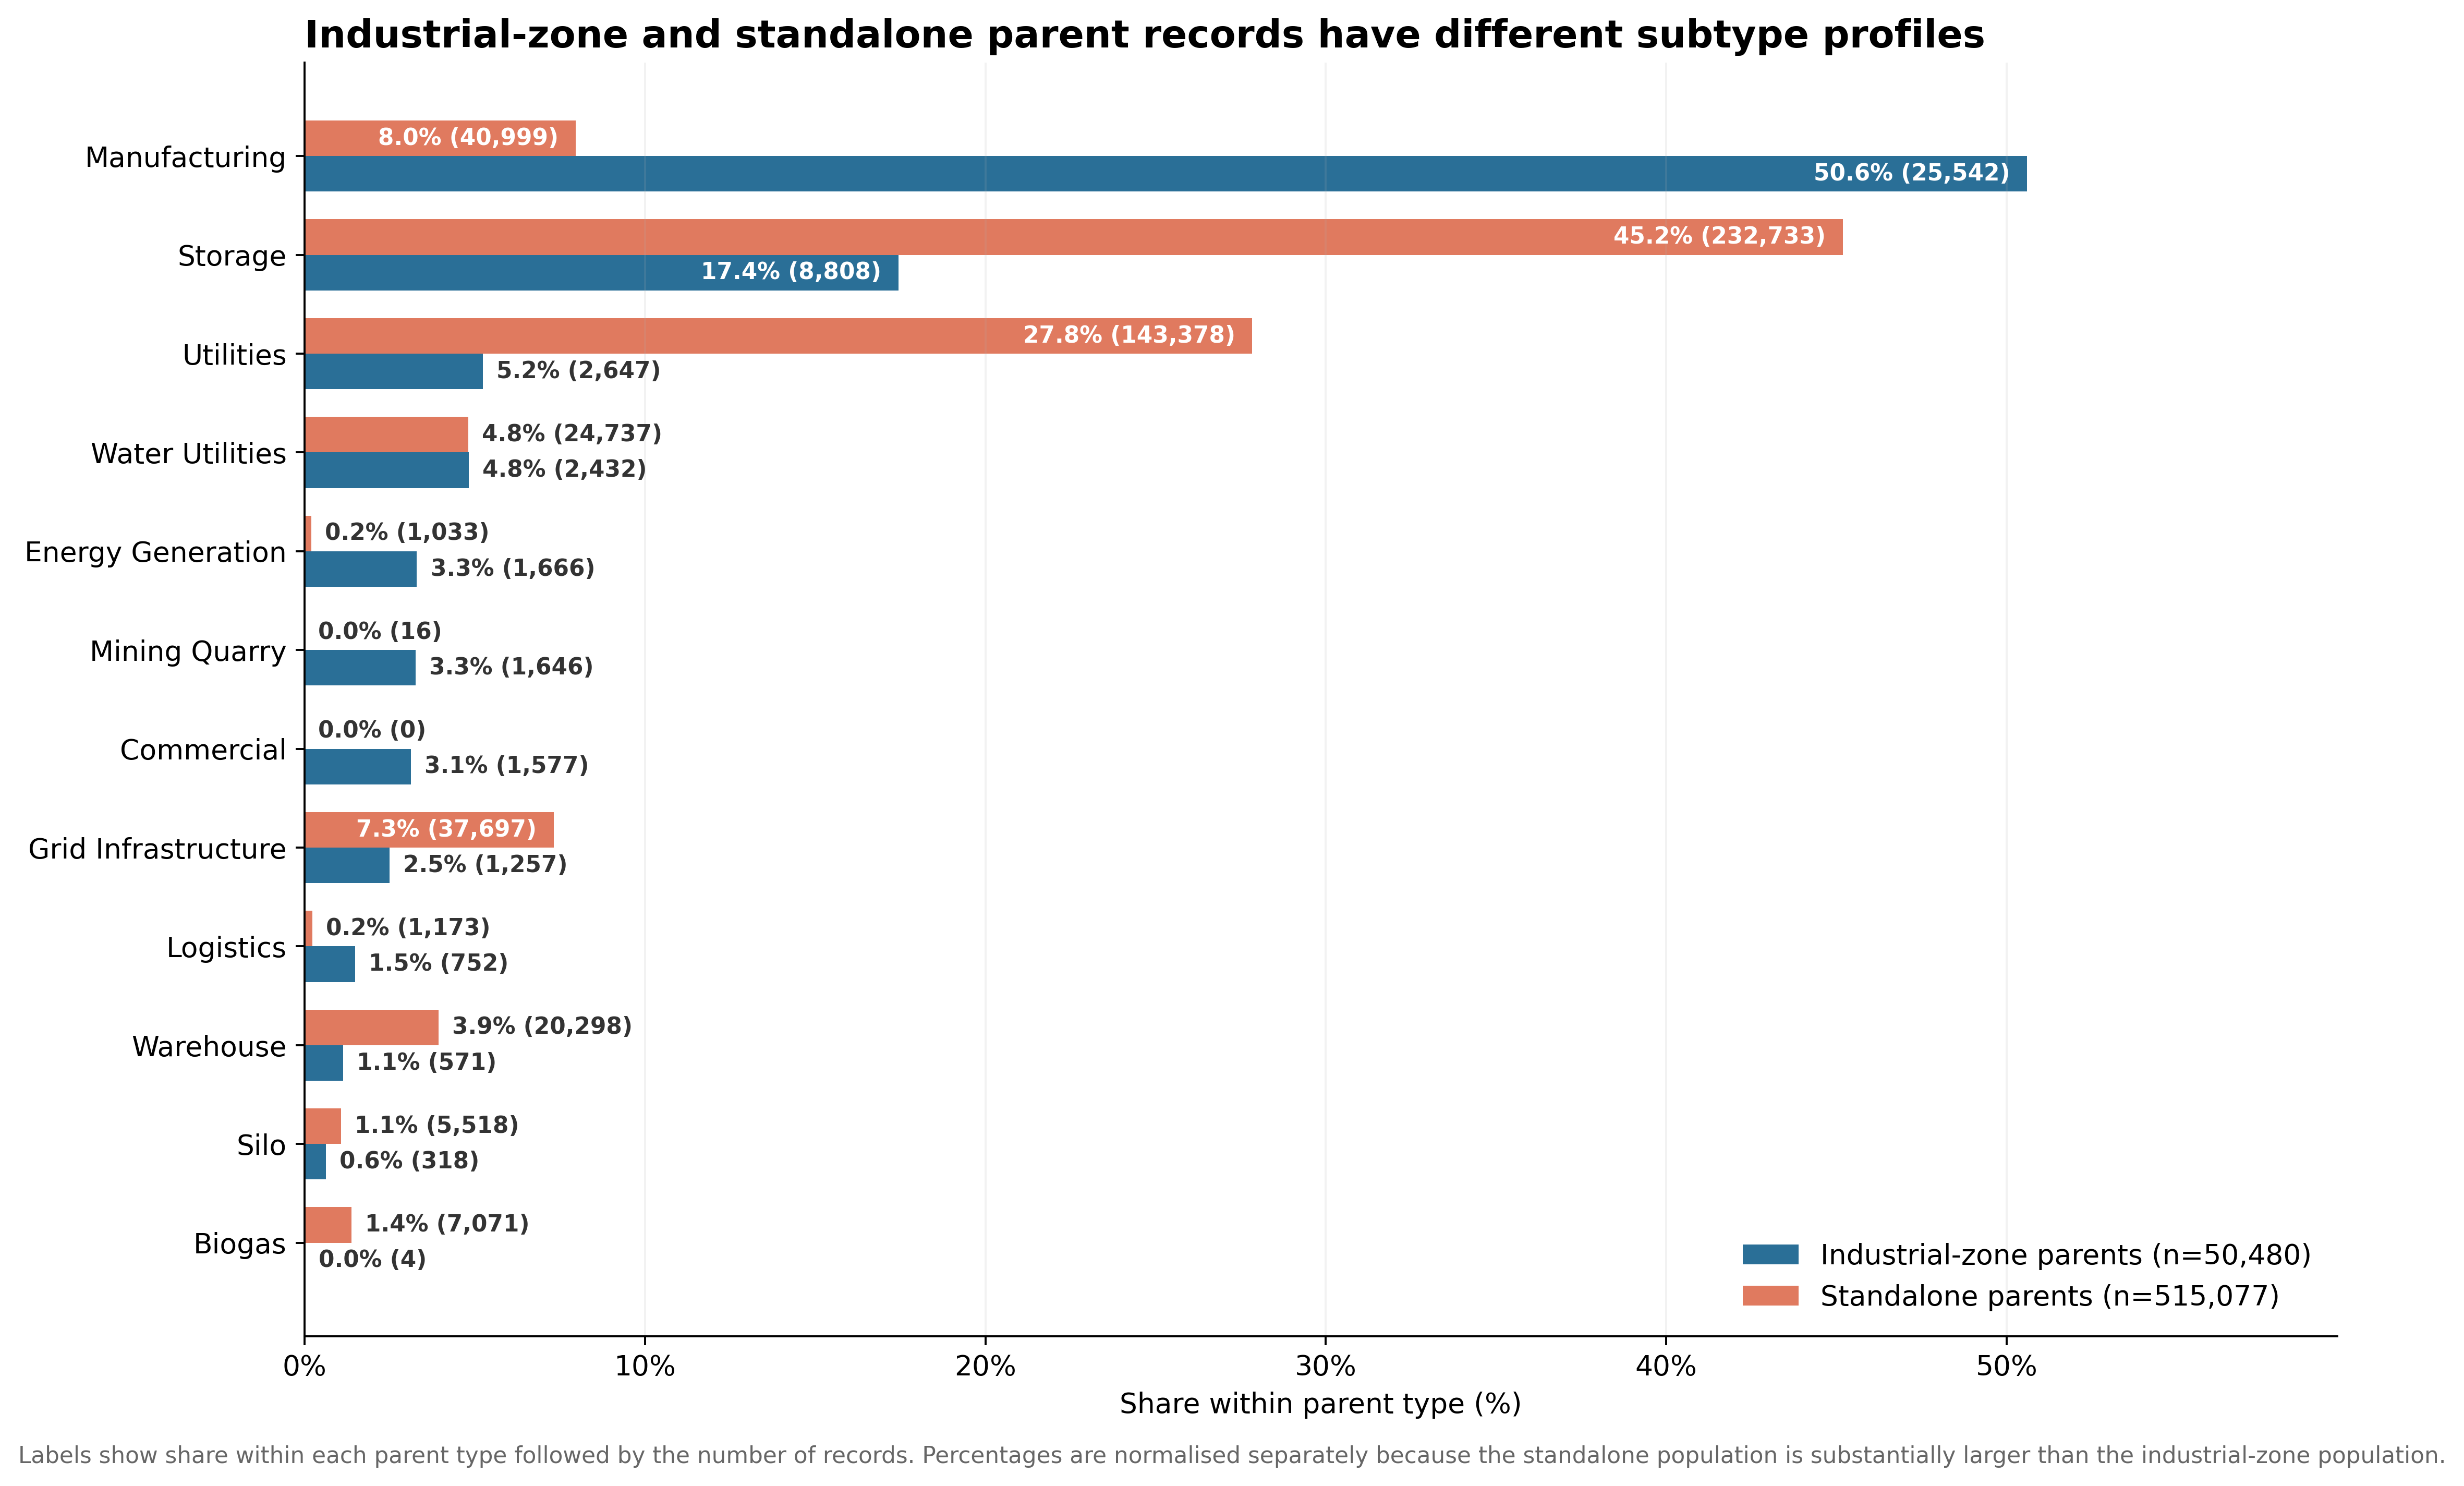

In [49]:
# ------------------------------------------------------------
# CHART 4: ZONE VS STANDALONE SUBTYPE SHARES
# ------------------------------------------------------------

top_subtypes = distribution_comparison["all_parents"].nlargest(12).index

chart_data = (
    distribution_comparison.loc[
        top_subtypes,
        ["zone_parents", "zone_share_pct",
         "standalone_parents", "standalone_share_pct"]
    ]
    .sort_values("zone_share_pct")
)

y = np.arange(len(chart_data))
h = 0.36

fig, ax = plt.subplots(figsize=(13, 8))

zone_bars = ax.barh(
    y - h/2,
    chart_data["zone_share_pct"],
    height=h,
    color=COLORS["blue"],
    label=f"Industrial-zone parents (n={len(parent_subtypes):,})"
)

standalone_bars = ax.barh(
    y + h/2,
    chart_data["standalone_share_pct"],
    height=h,
    color=COLORS["orange"],
    label=f"Standalone parents (n={len(standalone_parents):,})"
)

def add_labels(bars, shares, counts):
    for bar, share, count in zip(bars, shares, counts):
        x = bar.get_width()
        inside = x >= 7

        ax.text(
            x - 0.5 if inside else x + 0.4,
            bar.get_y() + bar.get_height()/2,
            f"{share:.1f}% ({count:,.0f})",
            ha="right" if inside else "left",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="white" if inside else "#333333"
        )

add_labels(
    zone_bars,
    chart_data["zone_share_pct"],
    chart_data["zone_parents"]
)

add_labels(
    standalone_bars,
    chart_data["standalone_share_pct"],
    chart_data["standalone_parents"]
)

ax.set_yticks(y, [clean_label(x) for x in chart_data.index])
ax.set_xlabel("Share within parent type (%)")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_title(
    "Industrial-zone and standalone parent records have different subtype profiles",
    loc="left"
)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.16)

max_share = chart_data[
    ["zone_share_pct", "standalone_share_pct"]
].to_numpy().max()

ax.set_xlim(0, max_share * 1.18)

fig.text(
    0.01, -0.01,
    (
        "Labels show share within each parent type followed by the number of records. "
        "Percentages are normalised separately because the standalone population is "
        "substantially larger than the industrial-zone population."
    ),
    fontsize=9,
    color="#666666"
)

plt.tight_layout()

In [50]:
# ============================================================
# 10. AREA-WEIGHTED FINAL DISTRIBUTIONS
# ============================================================

section("10. AREA-WEIGHTED SUBTYPE DISTRIBUTIONS")

def area_distribution(df, name):
    result = (
        df.assign(
            subtype_clean=df["subtype"].astype("object").fillna("unresolved")
        )
        .groupby("subtype_clean")["total_area"]
        .agg(
            parent_count="count",
            total_area_sqm="sum",
            mean_parent_area_sqm="mean",
            median_parent_area_sqm="median",
        )
        .sort_values("total_area_sqm", ascending=False)
    )

    result["area_share_pct"] = result["total_area_sqm"].div(
        result["total_area_sqm"].sum()
    ) * 100

    print(f"\n{name}\n{'-' * 100}")
    print(
        result.to_string(
            formatters={
                "parent_count": fmt_int,
                "total_area_sqm": lambda x: f"{x:,.0f}",
                "mean_parent_area_sqm": lambda x: f"{x:,.1f}",
                "median_parent_area_sqm": lambda x: f"{x:,.1f}",
                "area_share_pct": fmt_pct,
            }
        )
    )

    return result


zone_area_distribution = area_distribution(
    parent_subtypes,
    "Area-weighted distribution of industrial land-use zone parents",
)

standalone_area_distribution = area_distribution(
    standalone_parents,
    "Area-weighted distribution of standalone industrial parents",
)

total_area_distribution = area_distribution(
    final_parents,
    "Area-weighted distribution of all final parent records",
)



10. AREA-WEIGHTED SUBTYPE DISTRIBUTIONS

Area-weighted distribution of industrial land-use zone parents
----------------------------------------------------------------------------------------------------
                          parent_count total_area_sqm mean_parent_area_sqm median_parent_area_sqm area_share_pct
subtype_clean                                                                                                   
manufacturing                   25,542    477,641,315             18,700.2                7,131.3         74.43%
storage                          8,808     51,665,650              5,865.8                1,943.6          8.05%
water_utilities                  2,432     26,298,107             10,813.4                  683.0          4.10%
logistics                          752     10,208,943             13,575.7                1,721.8          1.59%
silo                               318      9,534,031             29,981.2               11,070.7          1.49%
war


Area-weighted distribution of standalone industrial parents
----------------------------------------------------------------------------------------------------
                        parent_count total_area_sqm mean_parent_area_sqm median_parent_area_sqm area_share_pct
subtype_clean                                                                                                 
storage                      232,733    178,668,622                767.7                  334.6         54.76%
manufacturing                 40,999     87,895,302              2,143.8                  971.1         26.94%
warehouse                     20,298     34,346,569              1,692.1                  412.2         10.53%
utilities                    143,378     11,994,011                 83.7                   46.8          3.68%
water_utilities               24,737      6,413,907                259.3                  158.6          1.97%
biogas                         7,071      3,115,150          

In [51]:

# ============================================================
# 11. SUBTYPE RESOLUTION SOURCES
# ============================================================

section("11. INDUSTRIAL-ZONE SUBTYPE RESOLUTION SOURCES")

zone_source_distribution = print_distribution(
    parent_subtypes["subtype_source"],
    "Subtype source distribution for industrial-zone parents",
)

zone_tag_count = (
    parent_subtypes["subtype_source"]
    .astype(str)
    .str.startswith("zone_tag")
    .sum()
)
landuse_override_count = (
    parent_subtypes["subtype_source"] == "landuse_override"
).sum()
raw_evidence_count = parent_subtypes["subtype_source"].isin(
    ["ind_map_vote", "manmade_vote"]
).sum()
ml_vote_count = (
    parent_subtypes["subtype_source"] == "final_l2_vote"
).sum()
fallback_count = parent_subtypes["subtype_source"].isin(
    ["filter_fallback", "final_l1_fallback"]
).sum()

print("\nResolution tier summary")
print("-" * 100)
for label, count in [
    ("Tier 1 – zone-level OSM tags", zone_tag_count),
    ("Tier 2 – land-use override", landuse_override_count),
    ("Tier 3 – raw/man-made evidence", raw_evidence_count),
    ("Tier 4 – building final_l2 vote", ml_vote_count),
    ("Tier 5 – fallback", fallback_count),
]:
    print(f"{label:36}: {count:,} ({count / len(parent_subtypes) * 100:.2f}%)")



11. INDUSTRIAL-ZONE SUBTYPE RESOLUTION SOURCES

Subtype source distribution for industrial-zone parents
----------------------------------------------------------------------------------------------------
                     count share_pct
subtype_source                      
final_l2_vote       32,462    64.31%
zone_tag_industrial  3,108     6.16%
ind_map_vote         2,901     5.75%
zone_tag_man_made    2,399     4.75%
manmade_vote         2,210     4.38%
final_l1_fallback    2,013     3.99%
zone_tag_power       1,873     3.71%
landuse_override     1,215     2.41%
filter_fallback      1,067     2.11%
zone_tag_pipeline      533     1.06%
zone_tag_resource      397     0.79%
zone_tag_product       225     0.45%
zone_tag_utility        77     0.15%

Total: 50,480

Resolution tier summary
----------------------------------------------------------------------------------------------------
Tier 1 – zone-level OSM tags        : 8,612 (17.06%)
Tier 2 – land-use override          : 1,215 (

Text(0.01, -0.01, 'This chart is most suitable for the methodology, validation, or appendix section rather than the main headline-results slide.')

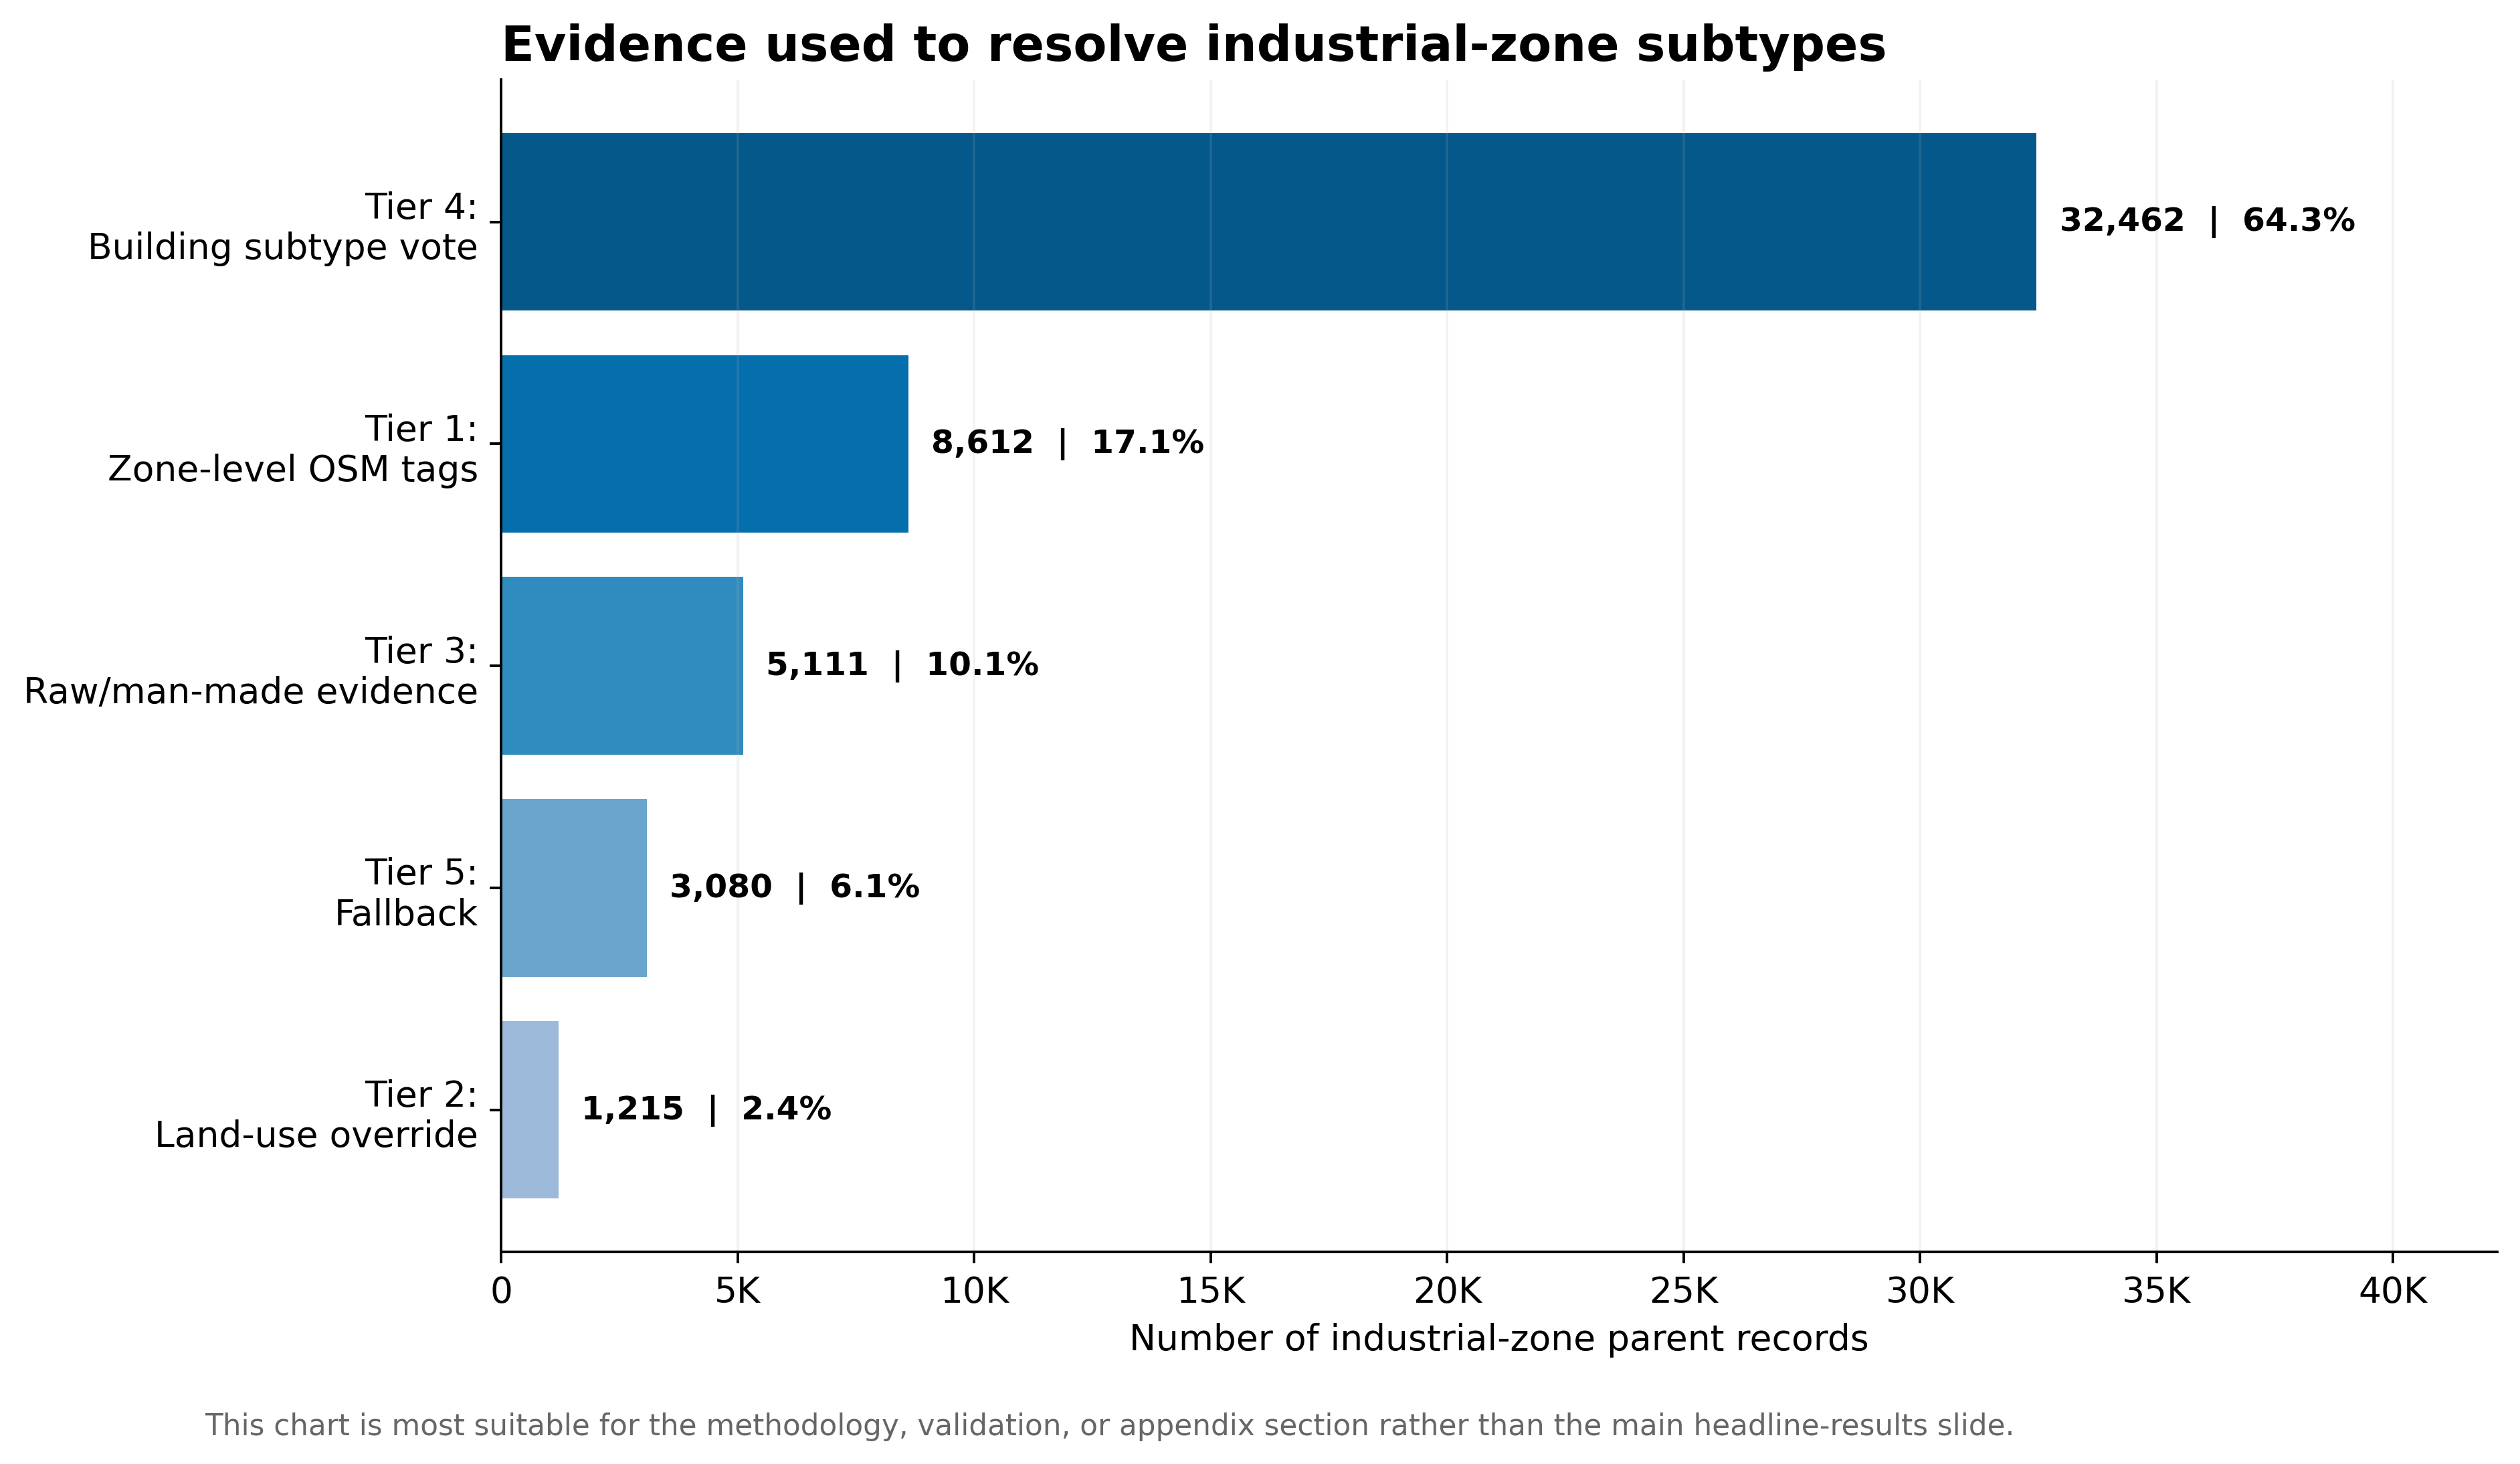

In [52]:
# ------------------------------------------------------------
# CHART 6: RESOLUTION EVIDENCE
#
# Useful as a methodology/validation or appendix result.
# ------------------------------------------------------------

resolution_counts = pd.Series({
    "Tier 1: Zone-level OSM tags": zone_tag_count,
    "Tier 2: Land-use override": landuse_override_count,
    "Tier 3: Raw/man-made evidence": raw_evidence_count,
    "Tier 4: Building subtype vote": ml_vote_count,
    "Tier 5: Fallback": fallback_count,
})

resolution_counts = resolution_counts[
    resolution_counts > 0
].sort_values()

resolution_shares = (
    resolution_counts
    / resolution_counts.sum()
    * 100
)

fig, ax = plt.subplots(figsize=(11, 6.5))

bars = ax.barh(
    [label.replace(": ", ":\n") for label in resolution_counts.index],
    resolution_counts.values,
    color=plt.colormaps["PuBu"](
        np.linspace(0.40, 0.88, len(resolution_counts))
    ),
)

for bar, count, share in zip(
    bars,
    resolution_counts.values,
    resolution_shares.values,
):
    ax.text(
        bar.get_width() + resolution_counts.max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,.0f}  |  {share:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Number of industrial-zone parent records")
ax.xaxis.set_major_formatter(compact_formatter)
ax.set_title(
    "Evidence used to resolve industrial-zone subtypes",
    loc="left",
)
ax.set_xlim(0, resolution_counts.max() * 1.30)
ax.grid(axis="x", alpha=0.16)

fig.text(
    0.01,
    -0.01,
    (
        "This chart is most suitable for the methodology, validation, "
        "or appendix section rather than the main headline-results slide."
    ),
    fontsize=9,
    color="#666666",
)

In [53]:

# 12. DATABASE-INTEGRITY RESULTS ALREADY CALCULATED
# ============================================================

section("12. DATABASE AND GROUPING INTEGRITY")

print(f"Buildings with a parent ID                          : {gdf_bldg['parent_id'].notna().sum():,}")
print(f"Buildings without a parent ID                       : {gdf_bldg['parent_id'].isna().sum():,}")
print(f"Final parent records                                : {len(final_parents):,}")
print(f"Unique final parent IDs                             : {final_parents['parent_id'].nunique():,}")
print(f"Duplicate parent IDs                                : {final_parents['parent_id'].duplicated().sum():,}")
print(f"Orphaned parent references                          : {len(orphans):,}")
print(f"Maximum child-parent area discrepancy               : {merged_check.max():,.6f} m²")
print(f"Mean child-parent area discrepancy                  : {merged_check.mean():,.6f} m²")
print(f"Parents with area discrepancy above 1 m²            : {(merged_check > 1).sum():,}")


12. DATABASE AND GROUPING INTEGRITY
Buildings with a parent ID                          : 1,175,266
Buildings without a parent ID                       : 37,627,106
Final parent records                                : 565,557
Unique final parent IDs                             : 565,557
Duplicate parent IDs                                : 0
Orphaned parent references                          : 0
Maximum child-parent area discrepancy               : 0.000000 m²
Mean child-parent area discrepancy                  : 0.000000 m²
Parents with area discrepancy above 1 m²            : 0


In [54]:
# ============================================================
# 13. FINAL SUMMARY TABLE
# ============================================================

section("13. FINAL SUMMARY TABLE")

summary = pd.DataFrame(
    {
        "Result": [
            "Industrial buildings before grouping",
            "Buildings inside industrial land-use zones",
            "Industrial buildings inside industrial zones",
            "Non-industrial buildings inside industrial zones",
            "Industrial land-use zone parents",
            "Multi-building industrial-zone parents",
            "Single-building industrial-zone parents",
            "Standalone industrial buildings",
            "Standalone industrial buildings with no land-use polygon",
            "Standalone industrial buildings in another land-use polygon",
            "Total final parent records",
            "Zone-level reduction in load-assignment units",
            "Overall reduction in linked load-assignment units",
            "Orphaned parent references",
            "Maximum area discrepancy",
        ],
        "Value": [
            f"{len(industrial_before_grouping):,}",
            f"{len(grouped):,}",
            f"{len(industrial_grouped_buildings):,}",
            f"{len(nonindustrial_grouped_buildings):,}",
            f"{len(parent_subtypes):,}",
            f"{len(multi_building_zones):,}",
            f"{len(single_building_zones):,}",
            f"{len(standalone_gdf):,}",
            f"{len(standalone_no_landuse):,}",
            f"{len(standalone_other_landuse):,}",
            f"{len(final_parents):,}",
            f"{zone_reduction_pct:.2f}%",
            f"{overall_reduction_pct:.2f}%",
            f"{len(orphans):,}",
            f"{merged_check.max():,.6f} m²",
        ],
    }
)

print(summary.to_string(index=False))



13. FINAL SUMMARY TABLE
                                                     Result       Value
                       Industrial buildings before grouping     965,940
                 Buildings inside industrial land-use zones     660,189
               Industrial buildings inside industrial zones     450,863
           Non-industrial buildings inside industrial zones     209,326
                           Industrial land-use zone parents      50,480
                     Multi-building industrial-zone parents      41,718
                    Single-building industrial-zone parents       8,762
                            Standalone industrial buildings     515,077
   Standalone industrial buildings with no land-use polygon     180,994
Standalone industrial buildings in another land-use polygon     334,083
                                 Total final parent records     565,557
              Zone-level reduction in load-assignment units      92.35%
          Overall reduction in linked l

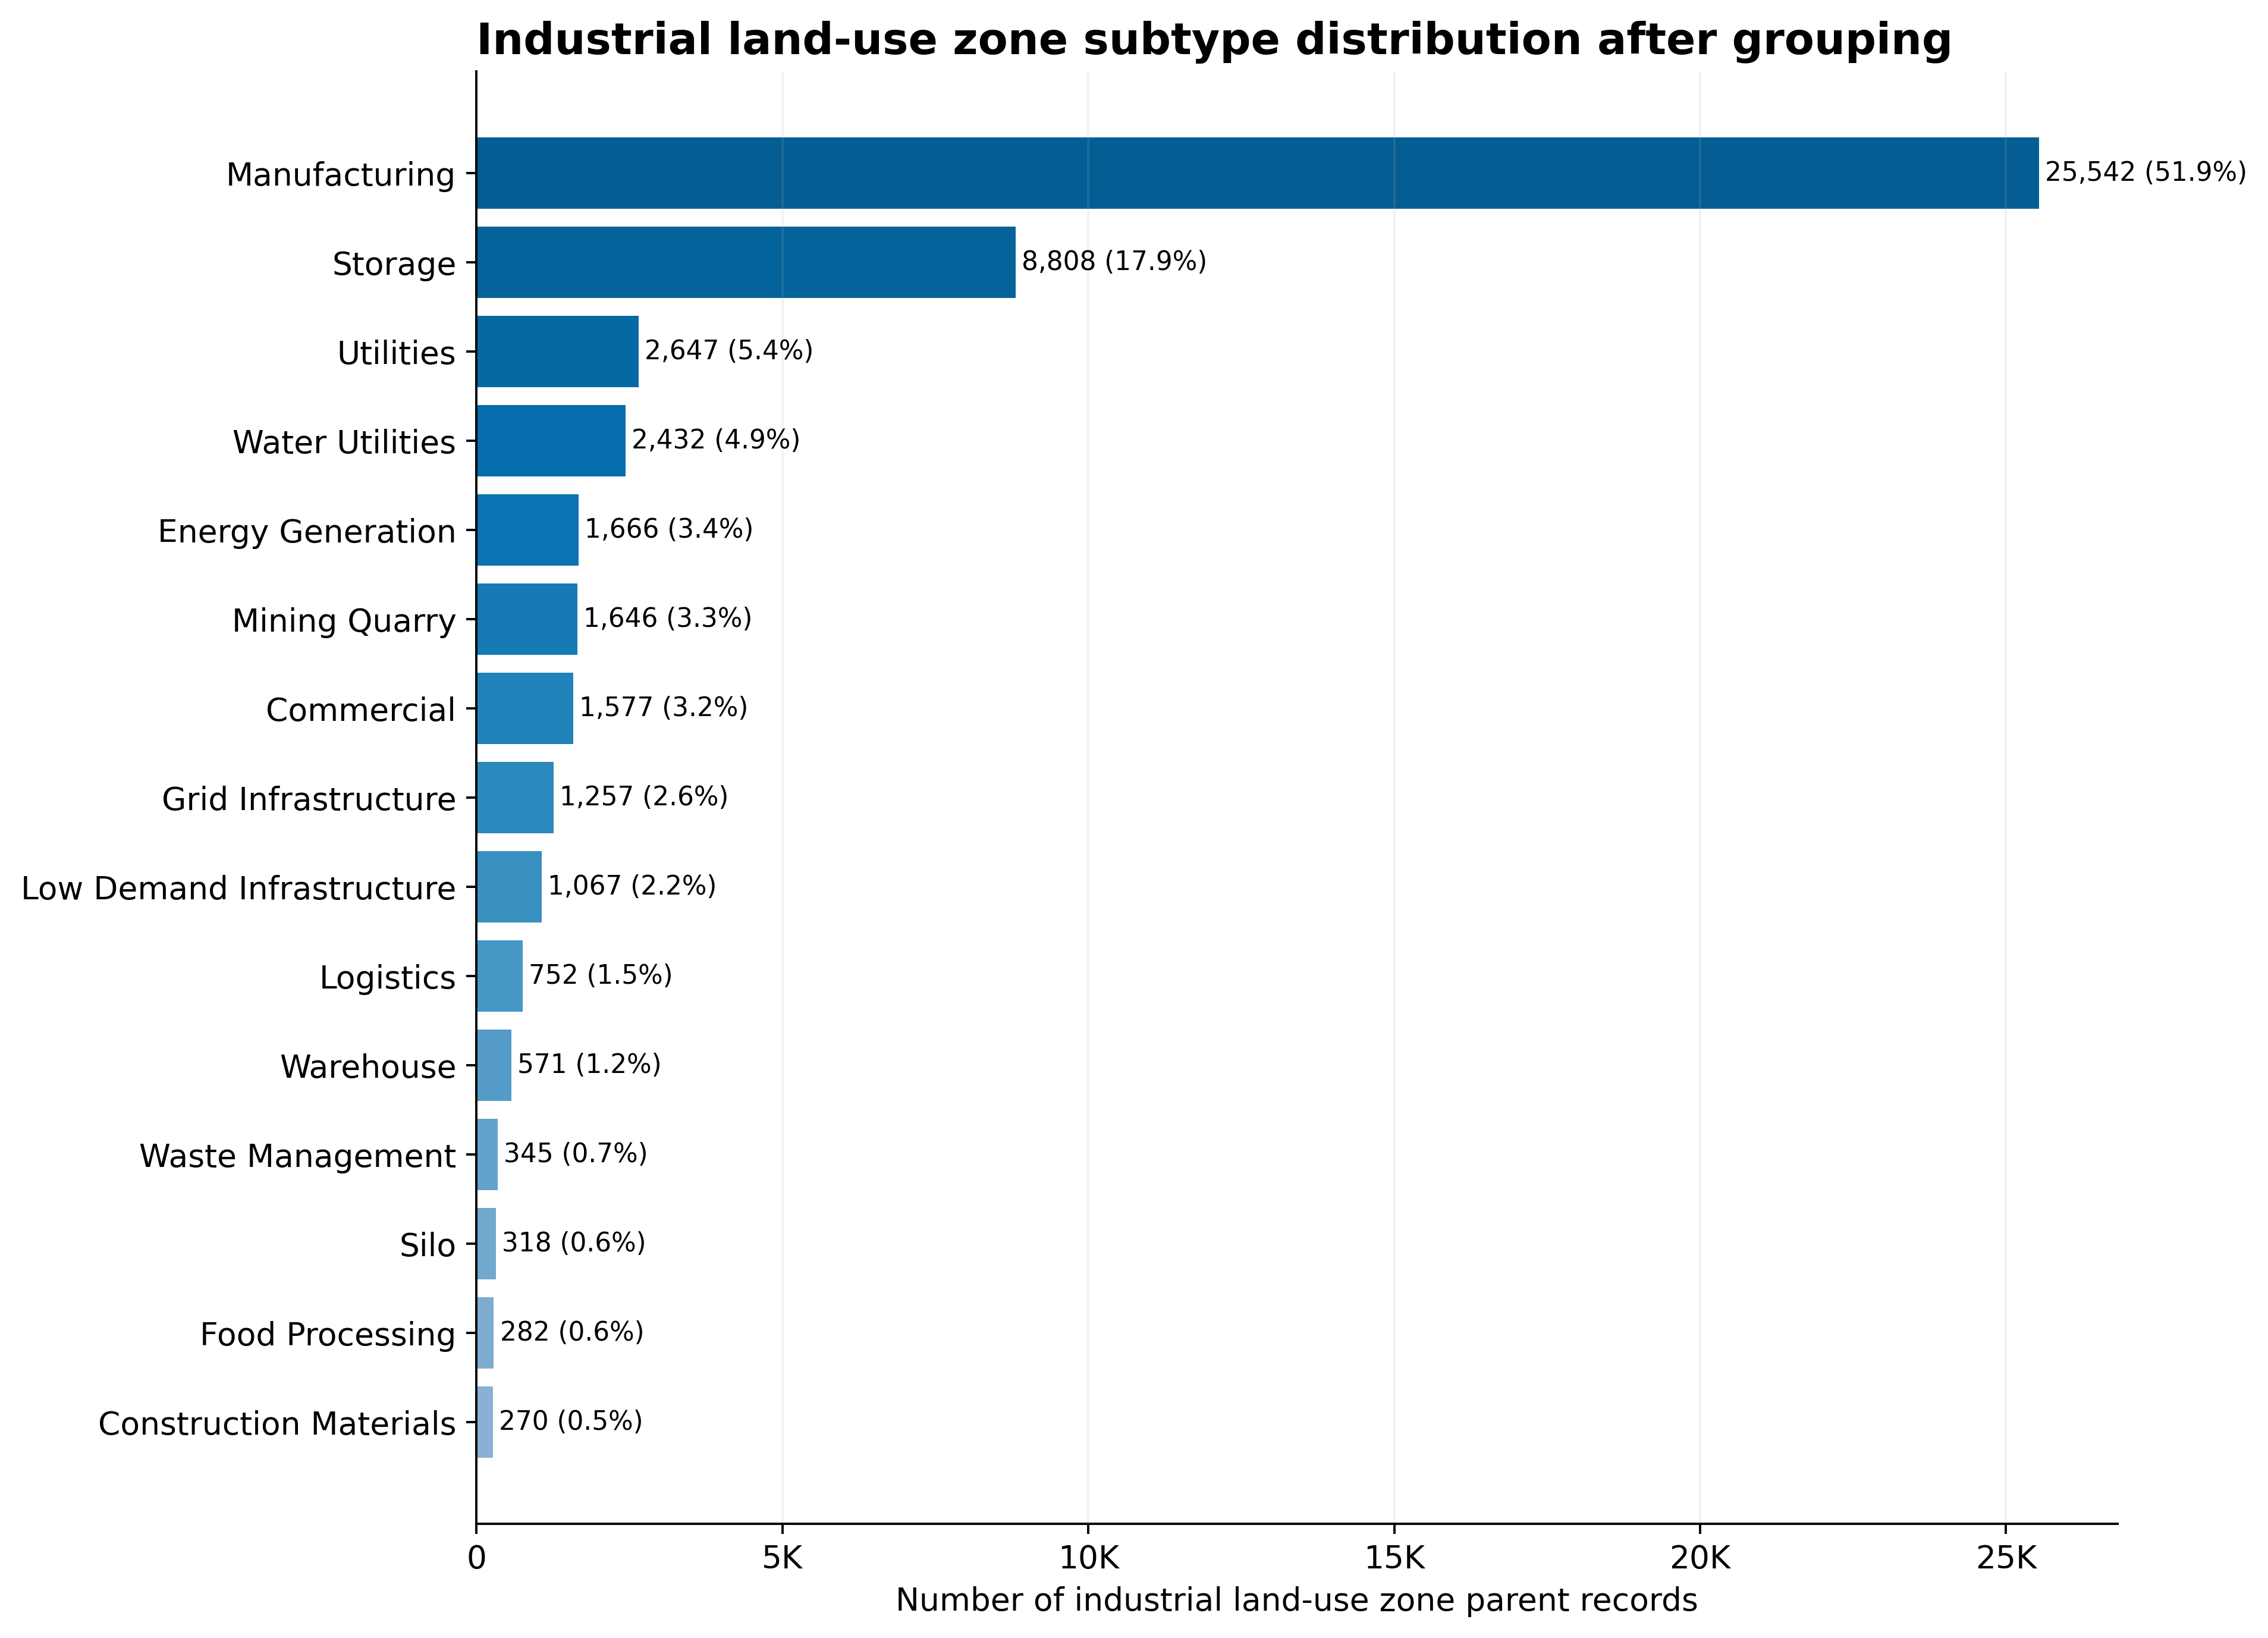

In [55]:
subtype_counts = zone_parent_distribution["count"]

top_subtypes = subtype_counts.head(15).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    [clean_label(s) for s in top_subtypes.index],
    top_subtypes.values,
    color=plt.colormaps["PuBu"](np.linspace(0.45, 0.85, len(top_subtypes))),
)

total = top_subtypes.sum()
for bar, count in zip(bars, top_subtypes.values):
    pct = count / total * 100
    ax.text(
        bar.get_width() + total * 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({pct:.1f}%)",
        va="center",
        fontsize=9,
    )

ax.set_title("Industrial land-use zone subtype distribution after grouping", loc="left")
ax.set_xlabel("Number of industrial land-use zone parent records")
ax.xaxis.set_major_formatter(compact_formatter)
ax.grid(axis="x", alpha=0.16)
fig.tight_layout()

plt.show()


Standalone industrial parent subtype distribution


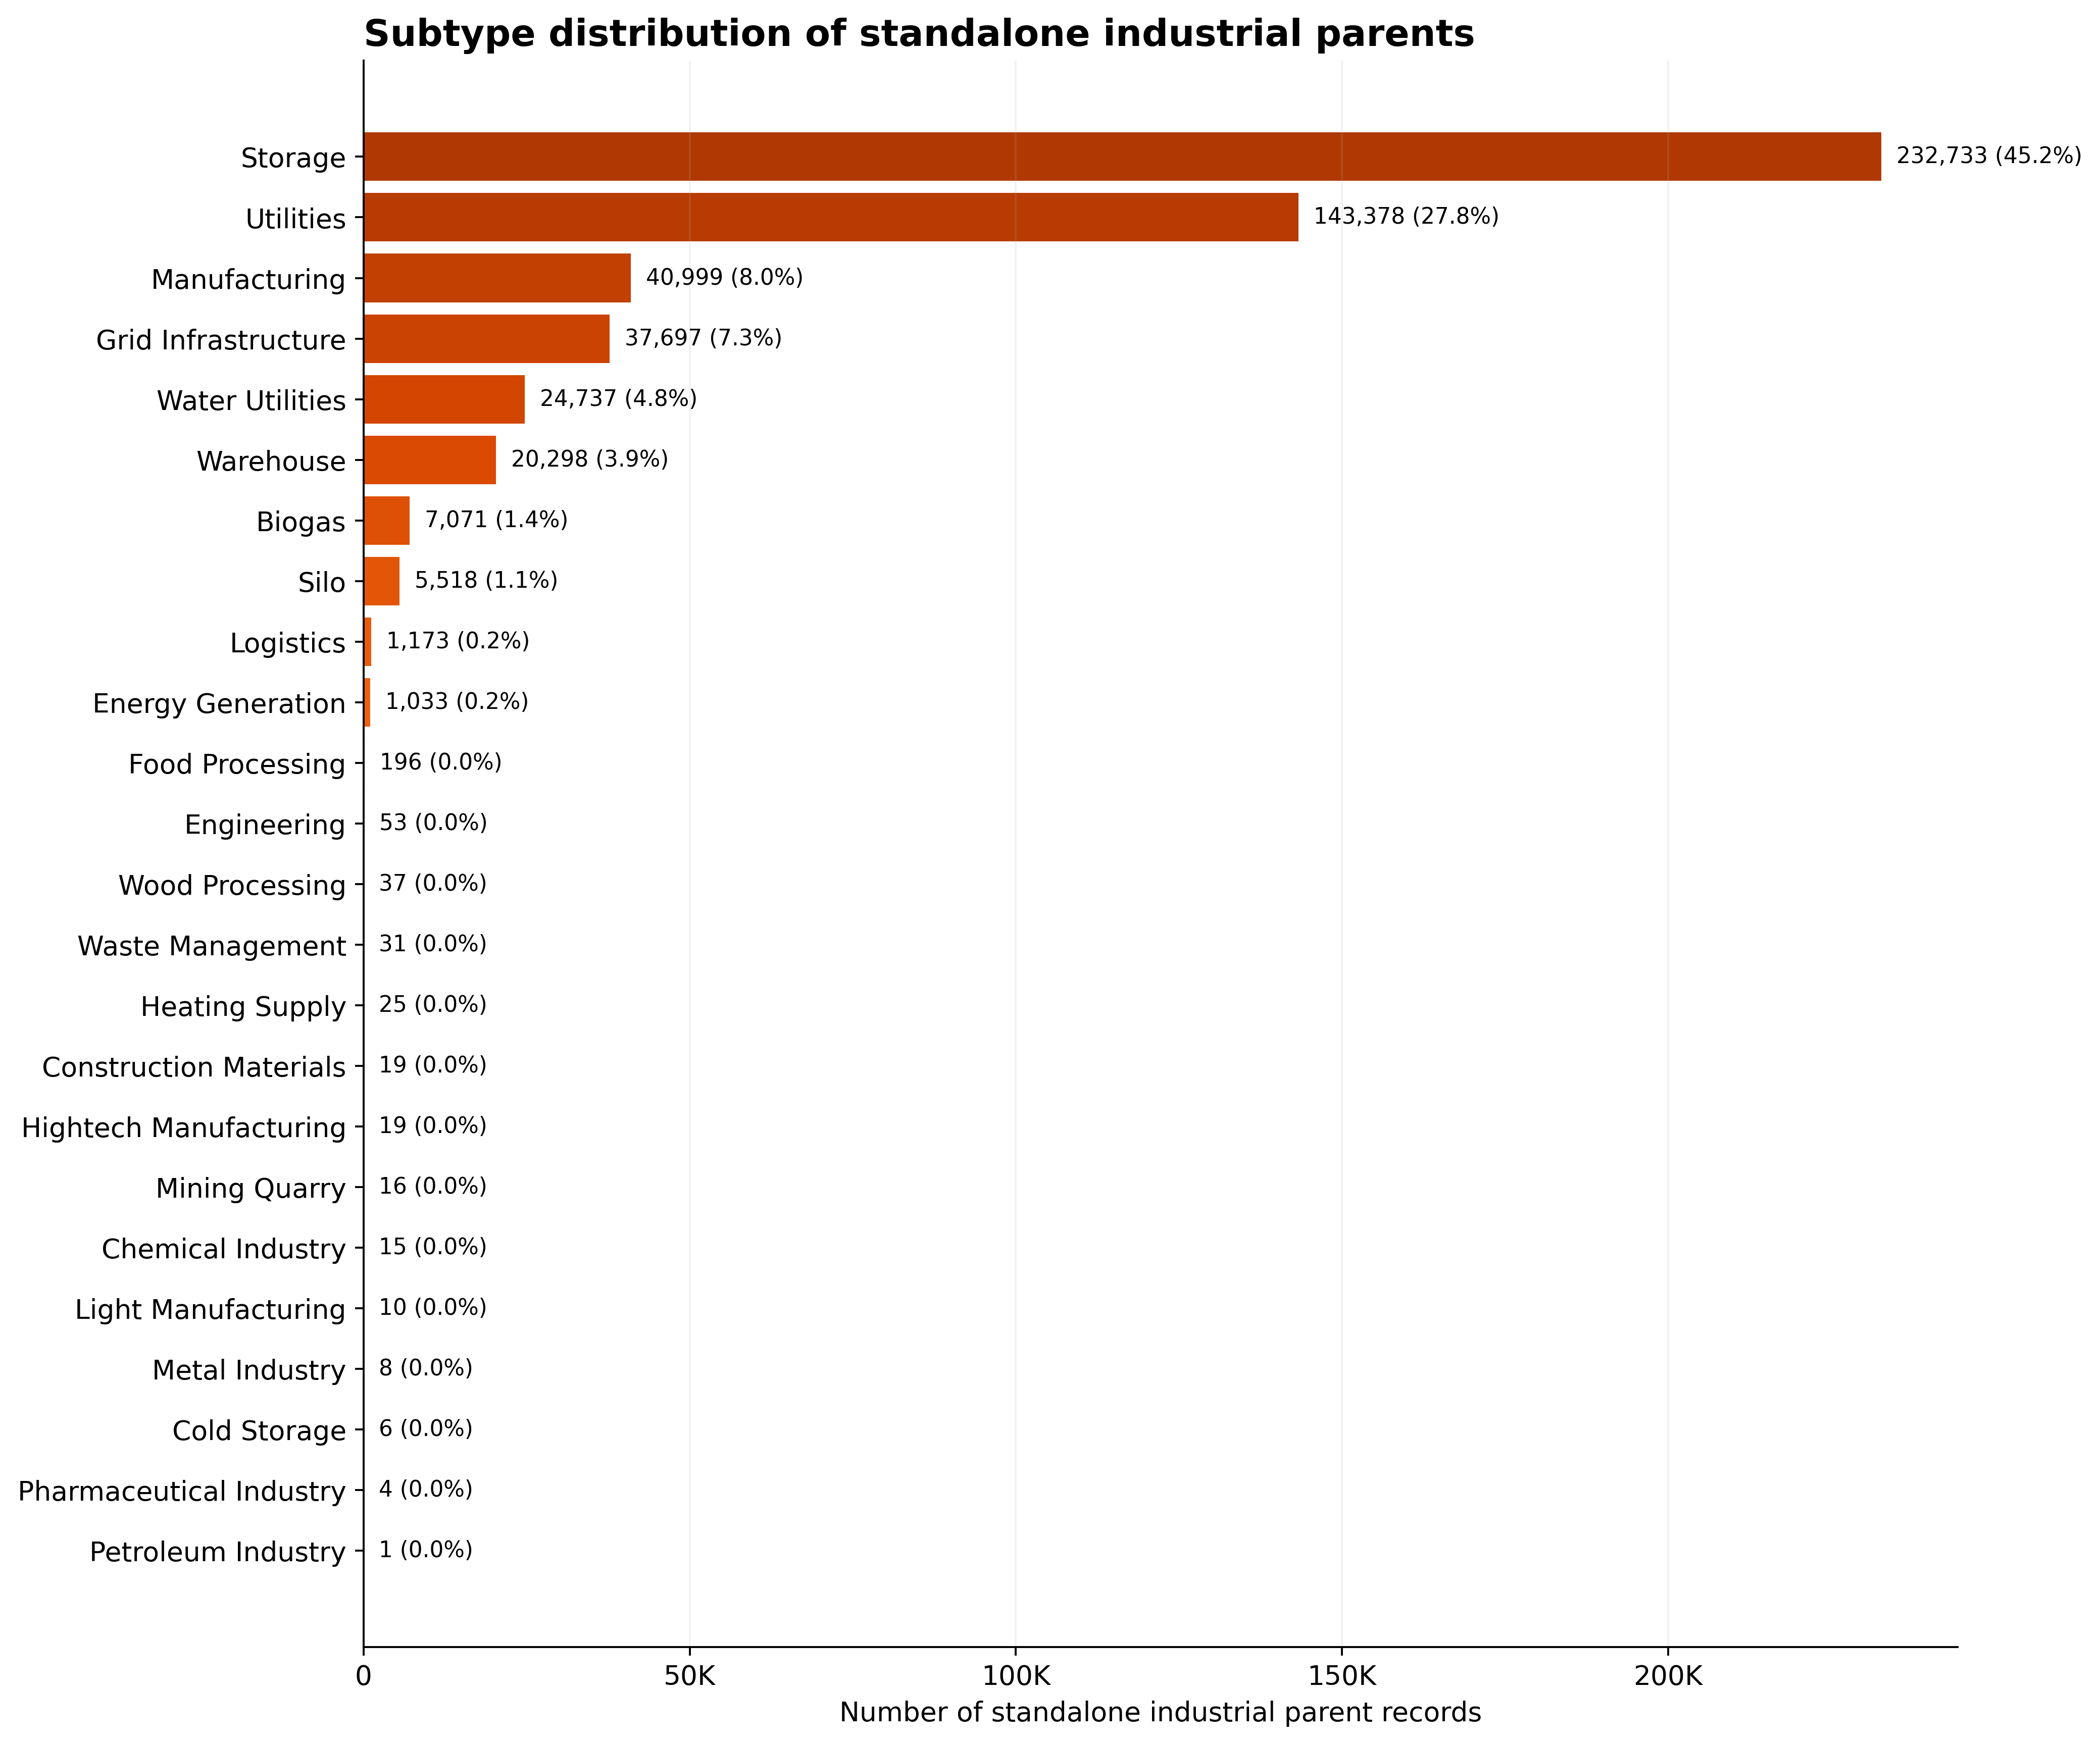

In [56]:
section("Standalone industrial parent subtype distribution")

standalone_counts = standalone_parent_distribution["count"].sort_values()
standalone_shares = standalone_parent_distribution["share_pct"].reindex(standalone_counts.index)

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    [clean_label(s) for s in standalone_counts.index],
    standalone_counts.values,
    color=plt.colormaps["Oranges"](np.linspace(0.35, 0.85, len(standalone_counts))),
)

for bar, count, share in zip(bars, standalone_counts.values, standalone_shares.values):
    ax.text(
        bar.get_width() + standalone_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({share:.1f}%)",
        va="center",
        fontsize=9,
    )

ax.set_title("Subtype distribution of standalone industrial parents", loc="left")
ax.set_xlabel("Number of standalone industrial parent records")
ax.xaxis.set_major_formatter(compact_formatter)
ax.grid(axis="x", alpha=0.16)
plt.tight_layout()
plt.show()

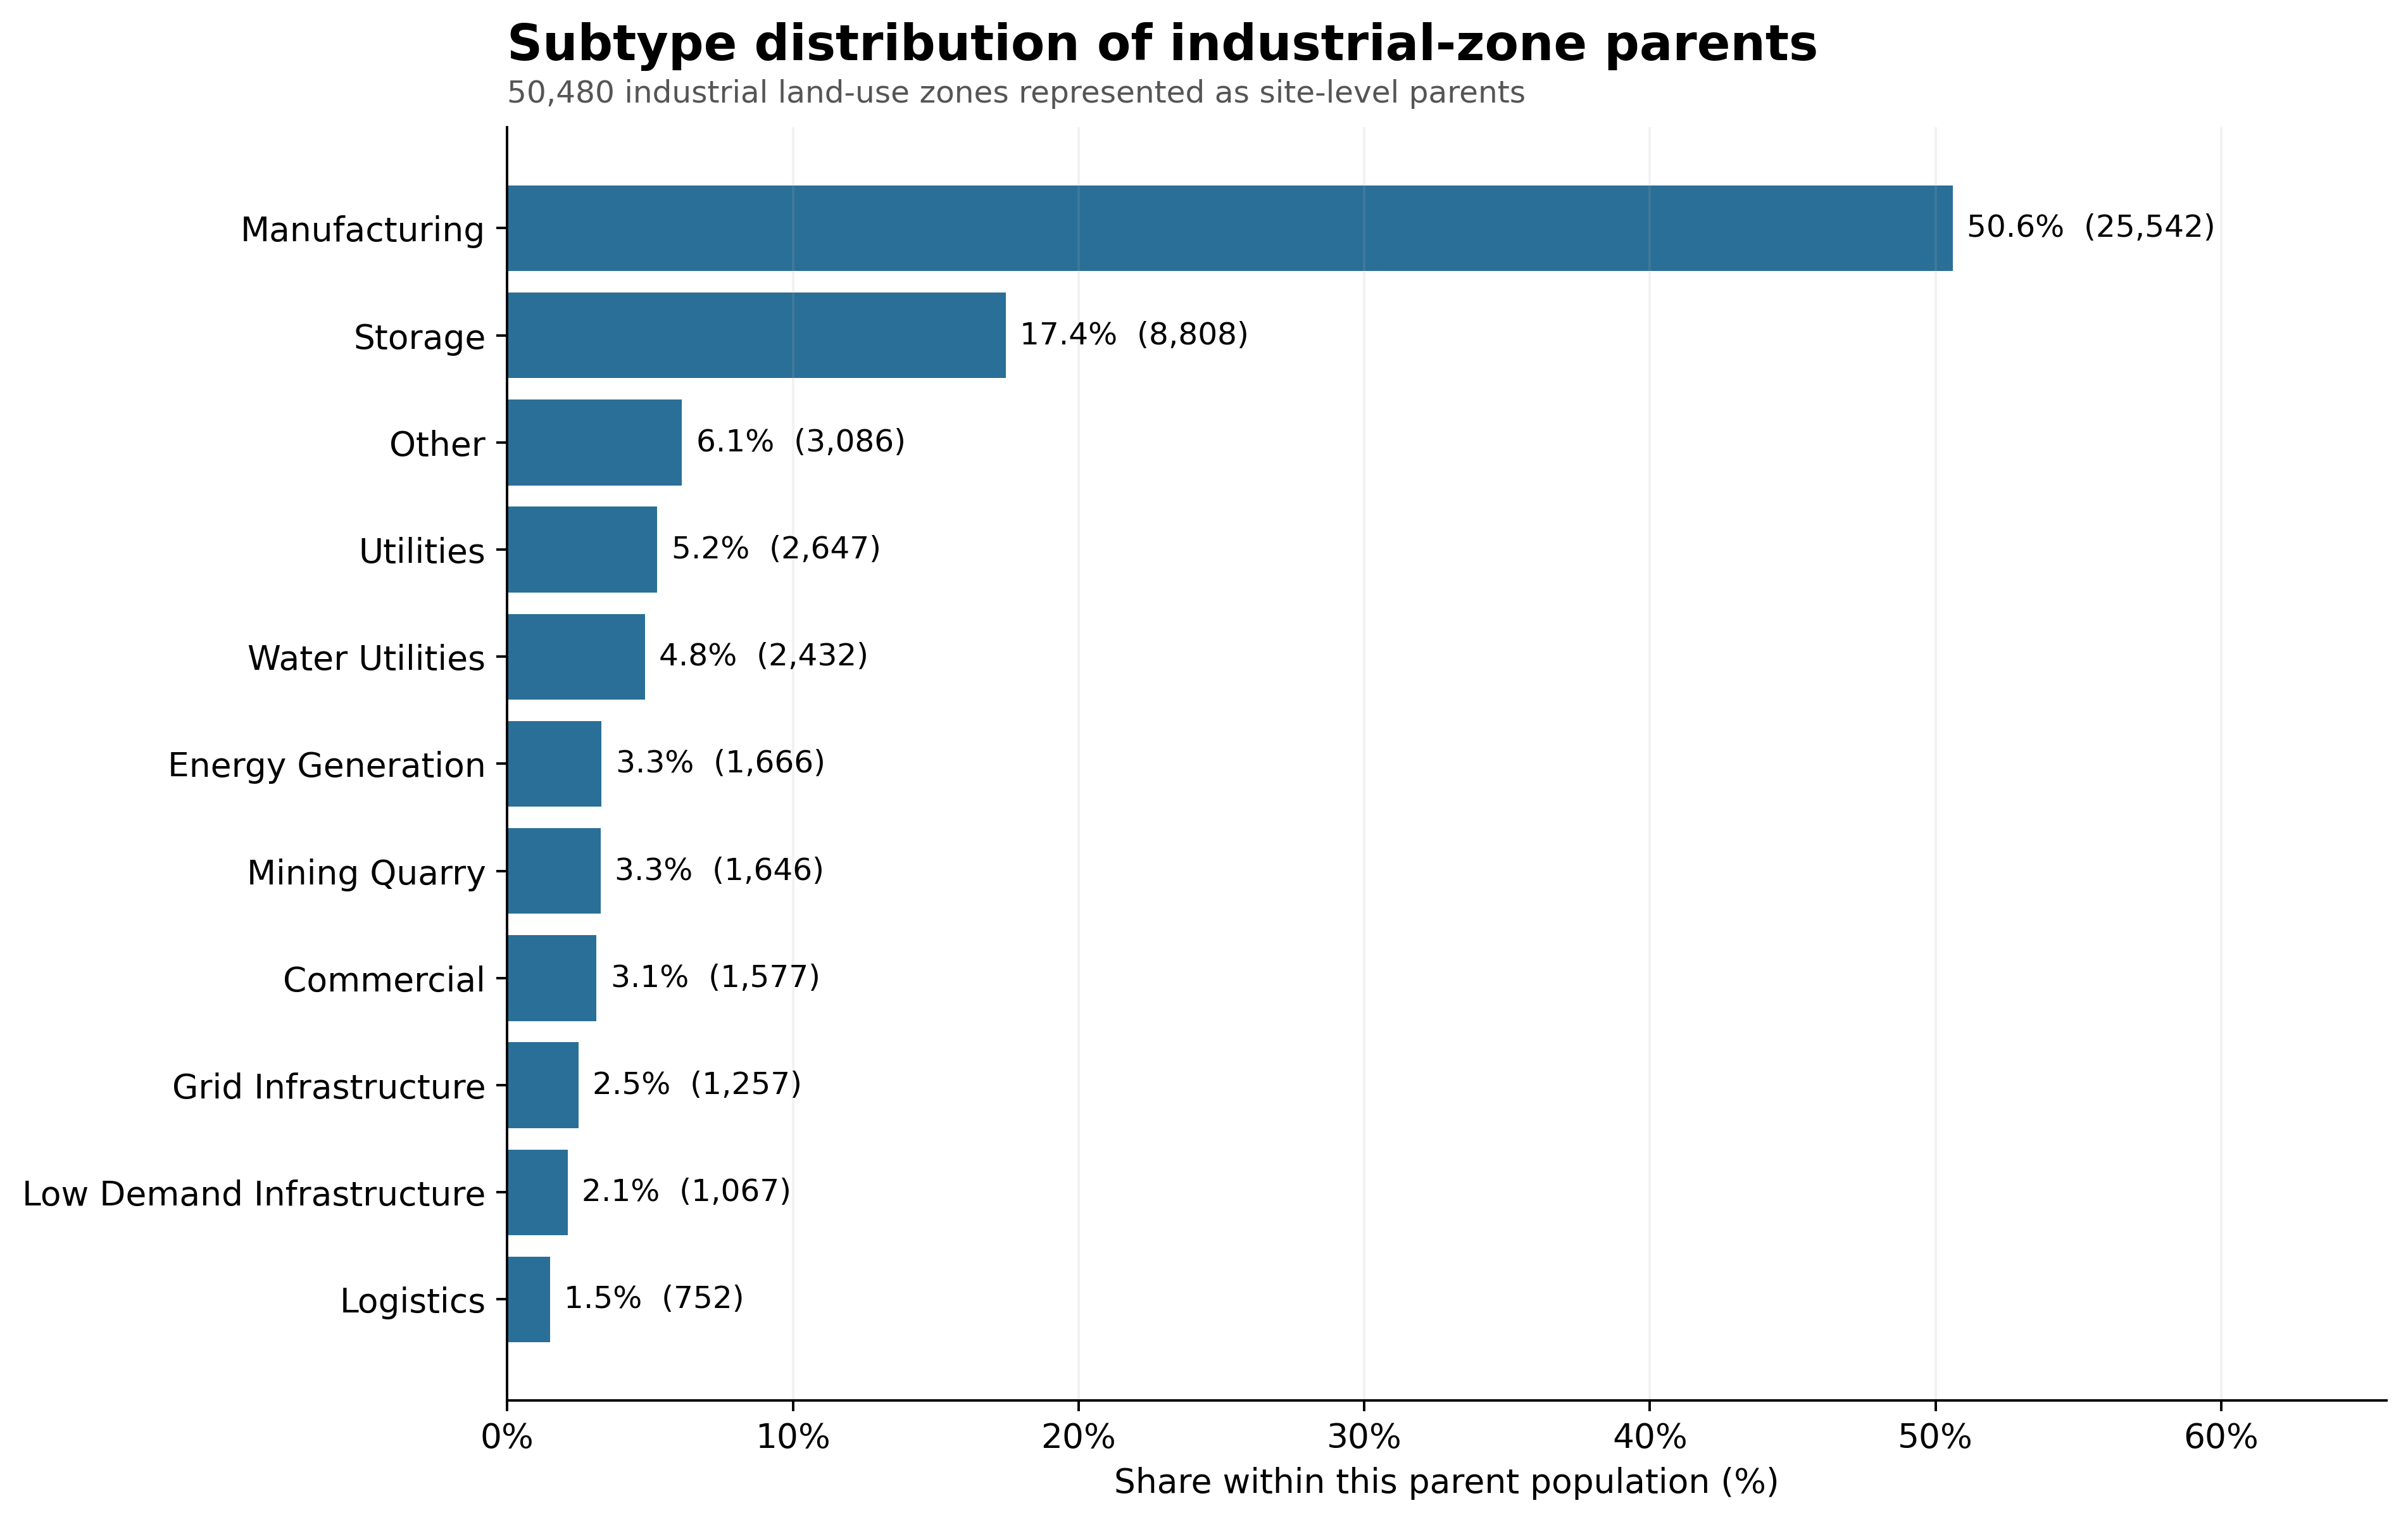

Saved chart: industrial_grouping_figures/06_zone_parent_distribution.png
Saved chart: industrial_grouping_figures/06_zone_parent_distribution.svg


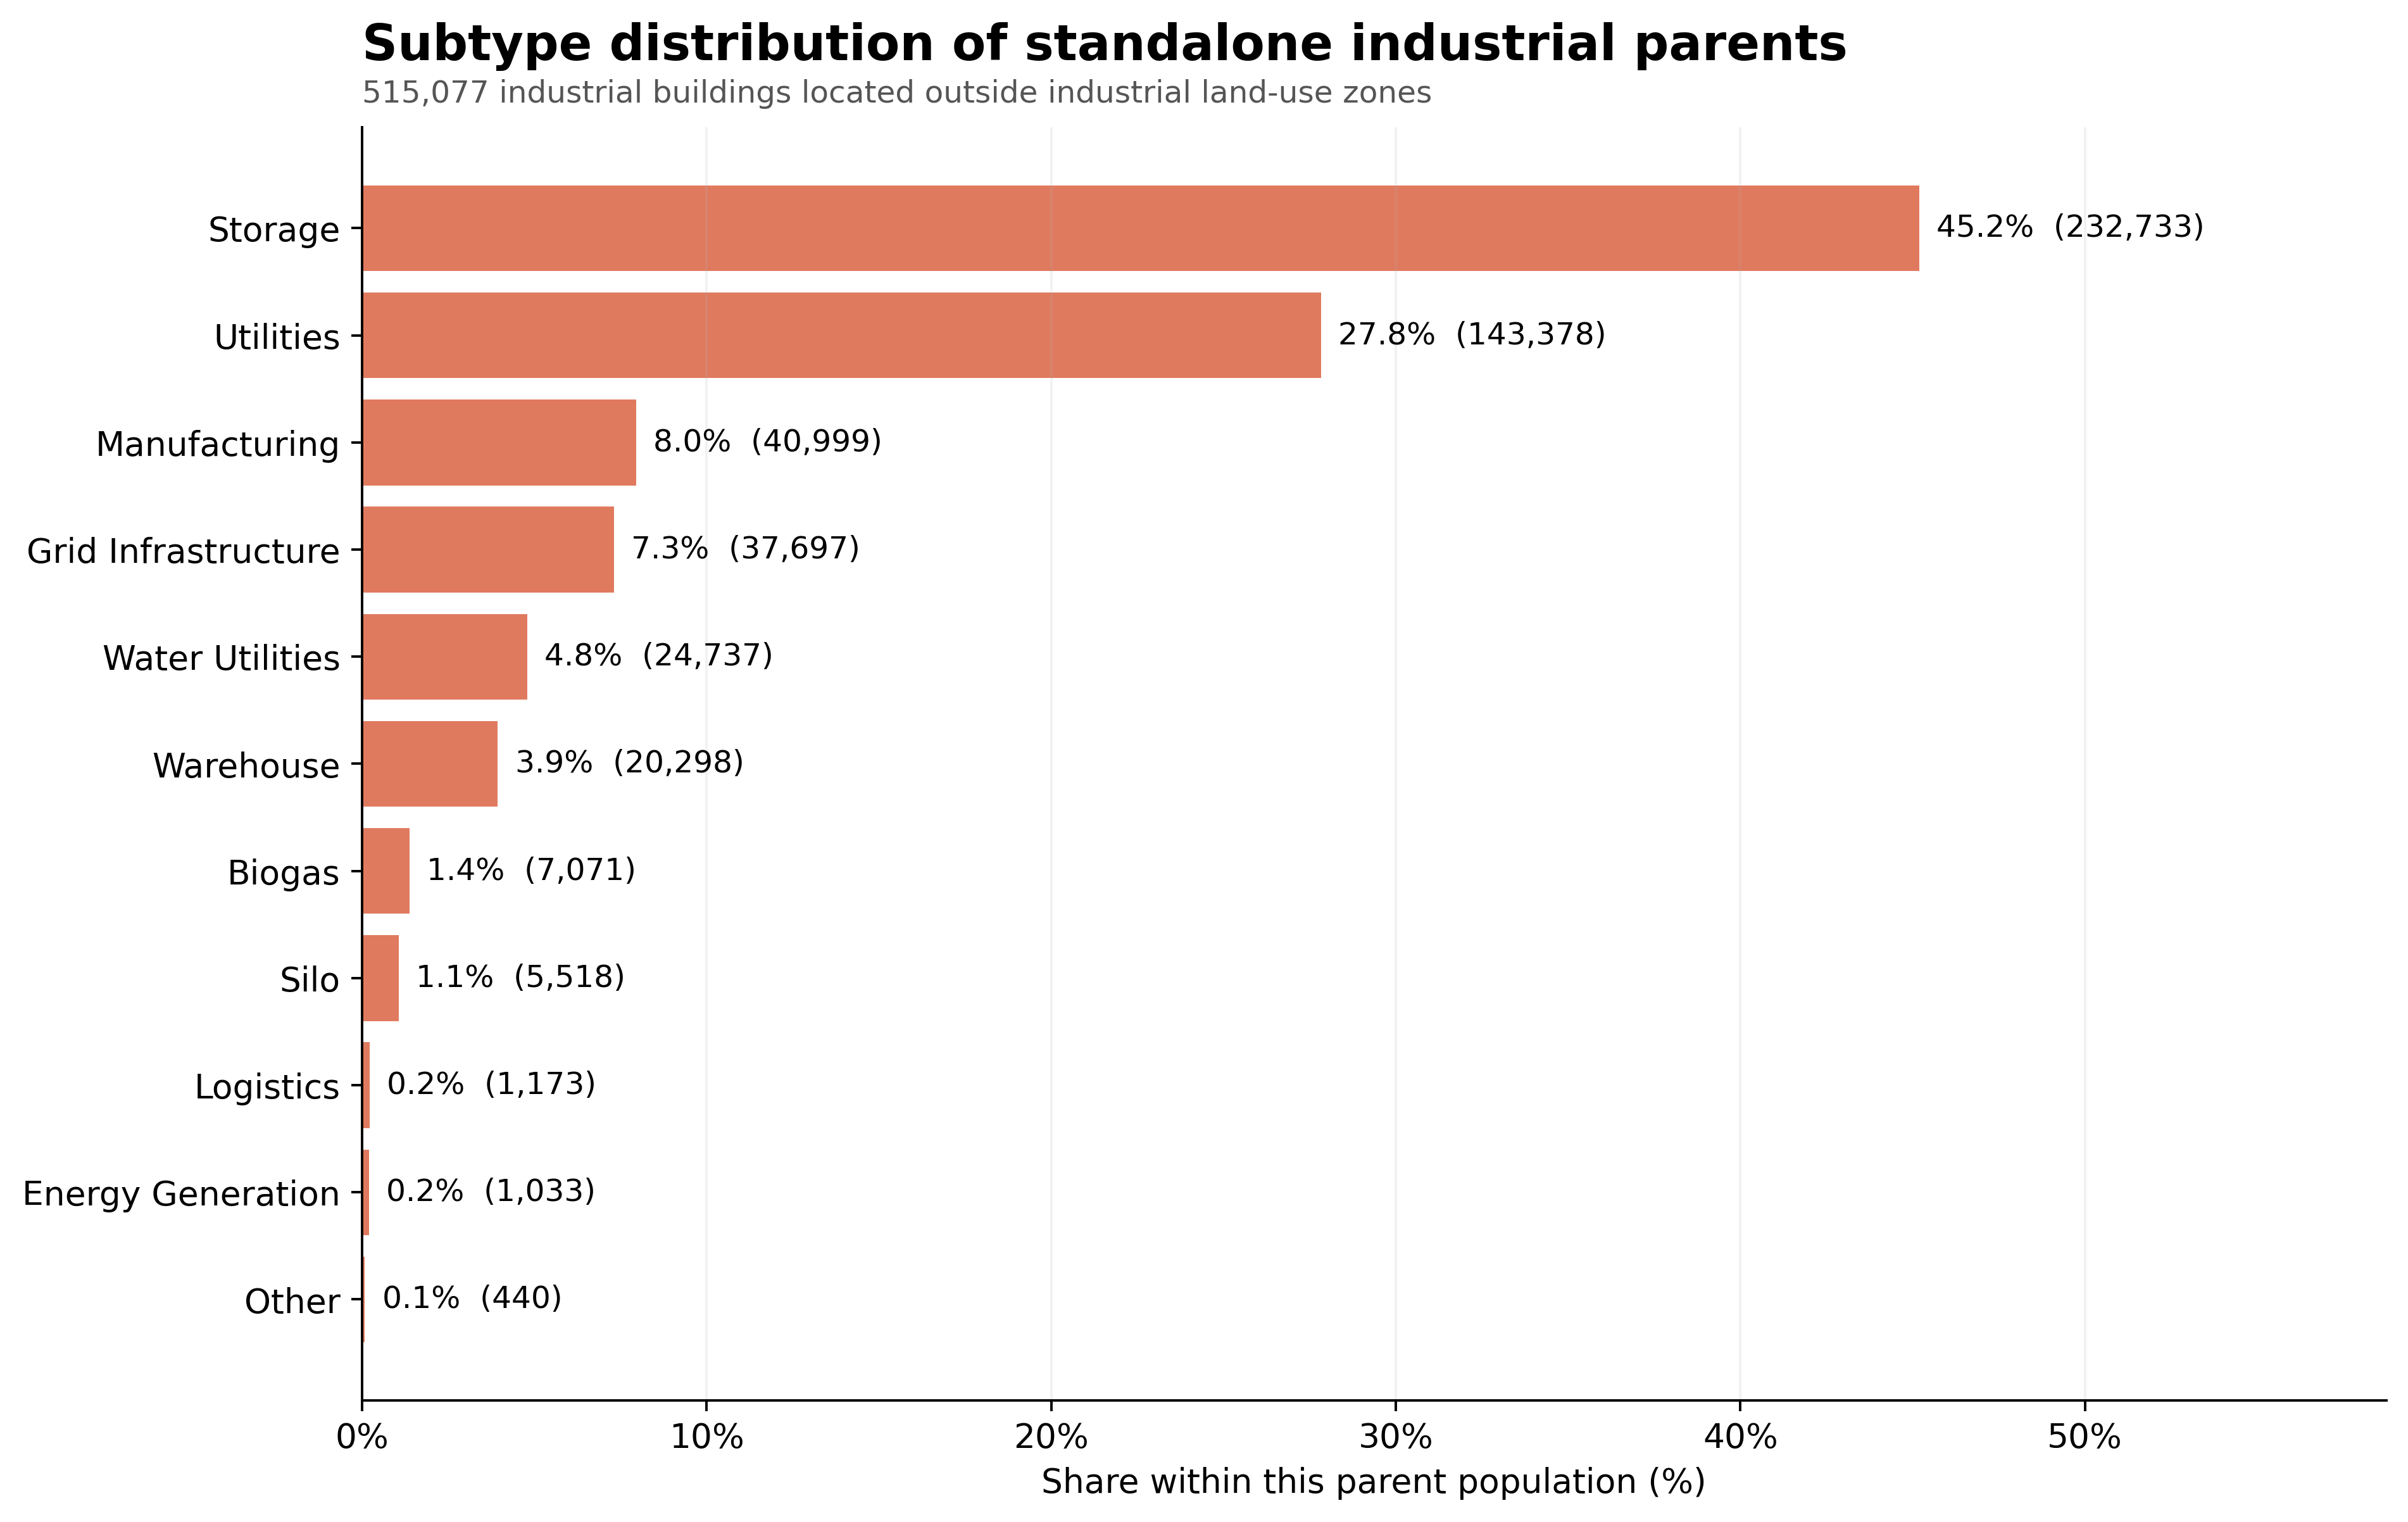

Saved chart: industrial_grouping_figures/07_standalone_parent_distribution.png
Saved chart: industrial_grouping_figures/07_standalone_parent_distribution.svg


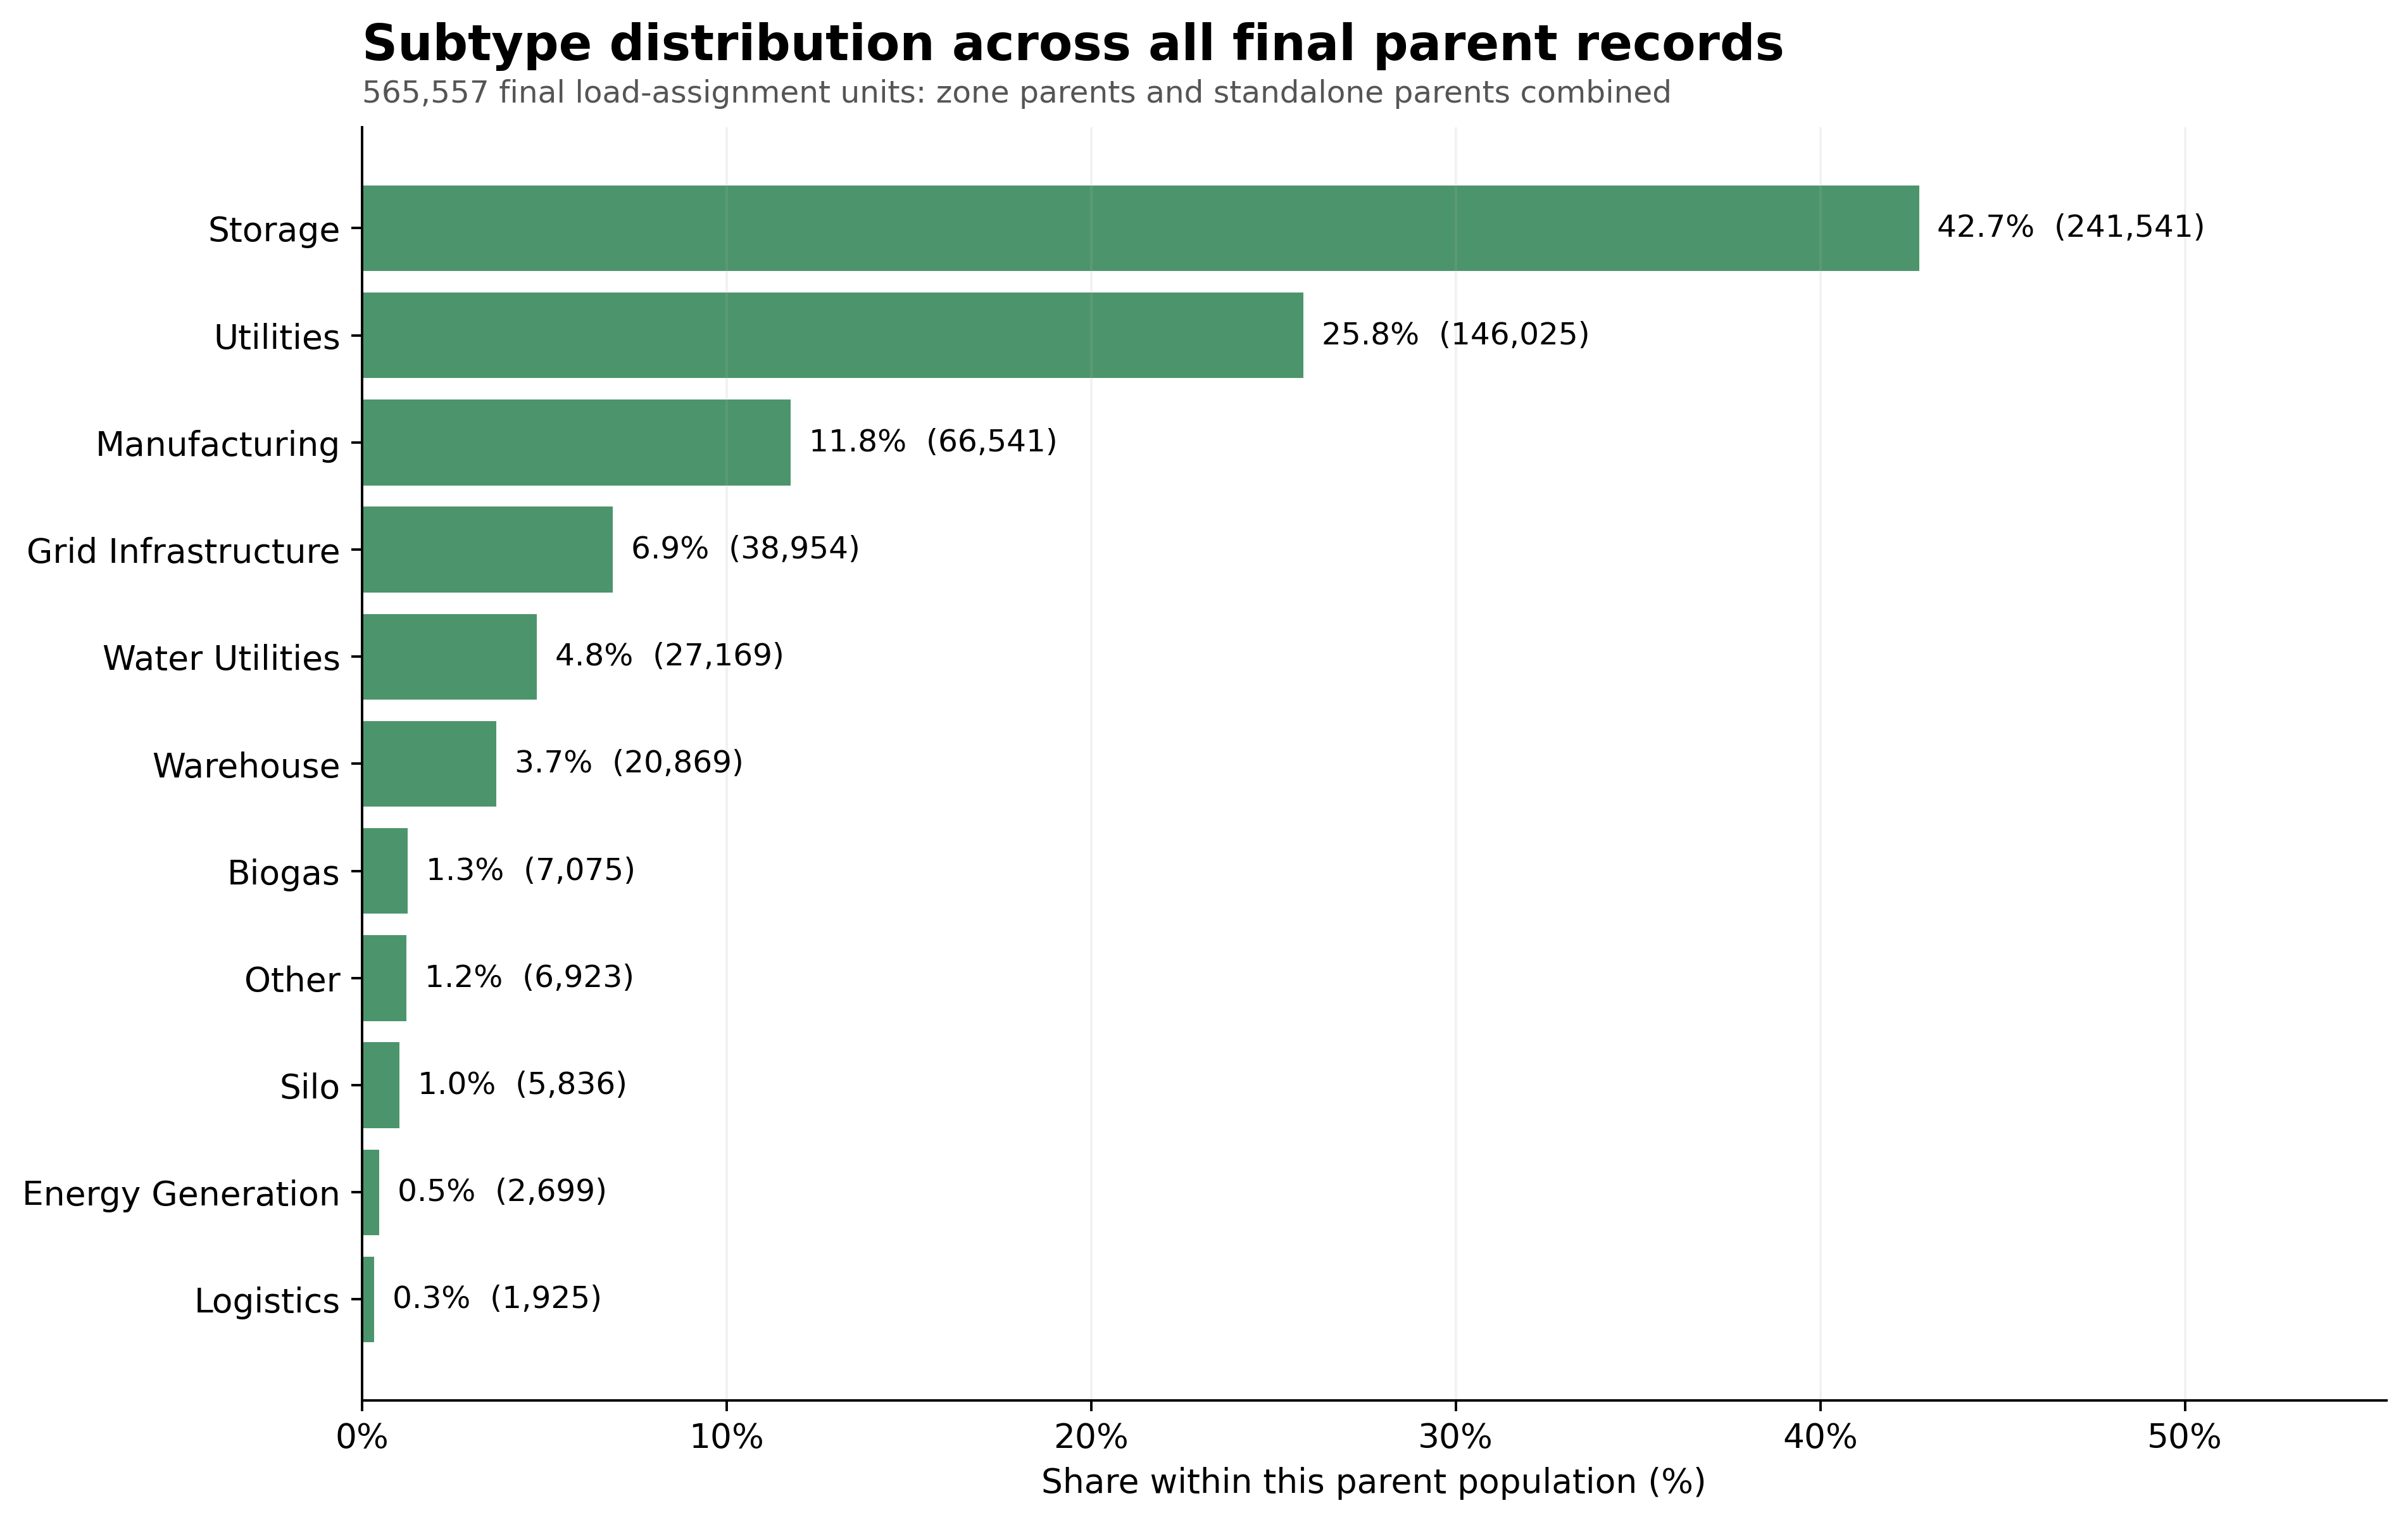

Saved chart: industrial_grouping_figures/08_total_parent_distribution.png
Saved chart: industrial_grouping_figures/08_total_parent_distribution.svg


In [57]:
from matplotlib.ticker import PercentFormatter

def prepare_parent_distribution(df, top_n=10):
    counts = df["subtype"].astype("object").fillna("unresolved").value_counts()
    if len(counts) > top_n:
        top = counts.head(top_n)
        counts = pd.concat([top, pd.Series({"Other": counts.iloc[top_n:].sum()})])
    result = counts.rename_axis("Subtype").reset_index(name="Parents")
    result["Share"] = result["Parents"] / result["Parents"].sum() * 100
    return result.sort_values("Share")

def plot_parent_distribution(df, title, subtitle, filename, color, top_n=10):
    data = prepare_parent_distribution(df, top_n)
    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.barh(
        [clean_label(x) for x in data["Subtype"]],
        data["Share"],
        color=color
    )

    for bar, count, share in zip(bars, data["Parents"], data["Share"]):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{share:.1f}%  ({count:,})",
            va="center",
            fontsize=10
        )

    ax.set_xlabel("Share within this parent population (%)")
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.set_title(title, loc="left", fontsize=16, fontweight="bold", pad=22)
    ax.text(
        0, 1.02, subtitle,
        transform=ax.transAxes,
        fontsize=10,
        color="#555555"
    )
    ax.grid(axis="x", alpha=0.16)
    ax.set_xlim(0, max(data["Share"]) * 1.30)
    plt.tight_layout()
    save_chart(fig, filename)

# 1. Industrial land-use zone parents
plot_parent_distribution(
    parent_subtypes,
    "Subtype distribution of industrial-zone parents",
    f"{len(parent_subtypes):,} industrial land-use zones represented as site-level parents",
    "06_zone_parent_distribution",
    COLORS["blue"]
)

# 2. Standalone industrial parents
plot_parent_distribution(
    standalone_parents,
    "Subtype distribution of standalone industrial parents",
    f"{len(standalone_parents):,} industrial buildings located outside industrial land-use zones",
    "07_standalone_parent_distribution",
    COLORS["orange"]
)

# 3. Complete final parent dataset
plot_parent_distribution(
    final_parents,
    "Subtype distribution across all final parent records",
    f"{len(final_parents):,} final load-assignment units: zone parents and standalone parents combined",
    "08_total_parent_distribution",
    COLORS["green"]
)